# TRỰC QUAN CÂN THIẾT 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from scipy.stats import kruskal

import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sns.set(style="whitegrid")


In [31]:
df_done = pd.read_csv('cluster_done.csv')
df = pd.read_csv("data_EDA.csv")

In [32]:
# # Load dữ liệu
# df_scaled = pd.read_csv('pipeline_P6_scaled.csv')

# X = df_scaled.select_dtypes(include=[np.number])
# labels = df_done['cluster_kmeans']

# # Chạy t-SNE 2D
# tsne_2d = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
# X_tsne_2d = tsne_2d.fit_transform(X)

# # Trực quan hóa 2D
# plt.figure(figsize=(10, 7))
# sns.scatterplot(
#     x=X_tsne_2d[:, 0], 
#     y=X_tsne_2d[:, 1], 
#     hue=labels, 
#     palette='viridis', 
#     s=25,             # Kích thước chấm tròn
#     alpha=0.6,        # Độ trong suốt
#     marker='o',       # Ép kiểu duy nhất là chấm tròn
#     edgecolor=None    # Loại bỏ viền trắng để nhìn mượt hơn
# )

# plt.title('t-SNE 2D')
# plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.show()

In [33]:

# # 1. Tải dữ liệu
# df_scaled = pd.read_csv('pipeline_P6_scaled.csv')

# # 2. Chuẩn bị dữ liệu (loại bỏ handleName)
# X = df_scaled.select_dtypes(include=[np.number])
# labels = df_done['cluster_kmeans'] # Hoặc 'cluster_kmeans_8' tùy chọn của bạn

# # 3. Thực thi t-SNE 3D
# # Perplexity: độ lân cận (thường từ 30-50)
# tsne_3d = TSNE(
#     n_components=3, 
#     perplexity=30, 
#     random_state=42, 
#     init='pca', 
#     learning_rate='auto'
# )
# X_tsne_3d = tsne_3d.fit_transform(X)

# # 4. Trực quan hóa
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# # Vẽ các điểm dữ liệu với màu sắc theo cụm
# scatter = ax.scatter(
#     X_tsne_3d[:, 0], 
#     X_tsne_3d[:, 1], 
#     X_tsne_3d[:, 2], 
#     c=labels, 
#     cmap='viridis', 
#     s=25, 
#     alpha=0.7
# )

# # Cấu hình tiêu đề và nhãn trục
# ax.set_title('Trực quan hóa t-SNE 3D', fontsize=15)
# ax.set_xlabel('t-SNE Dimension 1')
# ax.set_ylabel('t-SNE Dimension 2')
# ax.set_zlabel('t-SNE Dimension 3')

# # Thêm chú thích
# legend = ax.legend(*scatter.legend_elements(), title="Cụm (Cluster)", loc="upper right")
# ax.add_artist(legend)

# plt.tight_layout()
# plt.show()

In [34]:

cluster_col = 'cluster_kmeans'

# Lấy danh sách feature numeric, loại trừ cột cluster và định danh
cluster_cols_all = [c for c in df.columns if c.startswith('cluster_')]
feature_cols = [
    c for c in df.columns
    if c not in ['handleName', 'cluster_name'] + cluster_cols_all
    and pd.api.types.is_numeric_dtype(df[c])
]

# Tính H-statistic và p-value cho từng feature
results = []
groups = [
    df.loc[df[cluster_col] == c, :].copy()
    for c in sorted(df[cluster_col].dropna().unique())
]

for col in feature_cols:
    # Lấy giá trị từng cụm, bỏ NaN
    samples = [g[col].dropna().values for g in groups]
    # Chỉ tính khi tất cả cụm đều có ít nhất 2 mẫu
    if all(len(s) >= 2 for s in samples):
        h_stat, p_val = kruskal(*samples)
        results.append({
            'feature': col,
            'H_statistic': h_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

kw_df = (
    pd.DataFrame(results)
    .sort_values('H_statistic', ascending=False)
    .reset_index(drop=True)
)

# Hiển thị top 15
print(f"Tổng số feature được kiểm định: {len(kw_df)}")
print(f"Feature có ý nghĩa thống kê (p < 0.05): {kw_df['significant'].sum()}")
display(kw_df.head(15).round(2))

Tổng số feature được kiểm định: 59
Feature có ý nghĩa thống kê (p < 0.05): 55


,feature,H_statistic,p_value,significant
0,commercialScore,4260.49,0.0,True
1,country_MM,1498.27,0.0,True
2,country_TH,760.76,0.0,True
3,collaborationScore,739.81,0.0,True
4,device_XIAOMI,695.87,0.0,True
5,country_VN,680.08,0.0,True
6,device_Other,648.17,0.0,True
7,Beauty,454.56,0.0,True
8,startingRate100k,395.10,0.0,True
9,device_VIVO,374.87,0.0,True


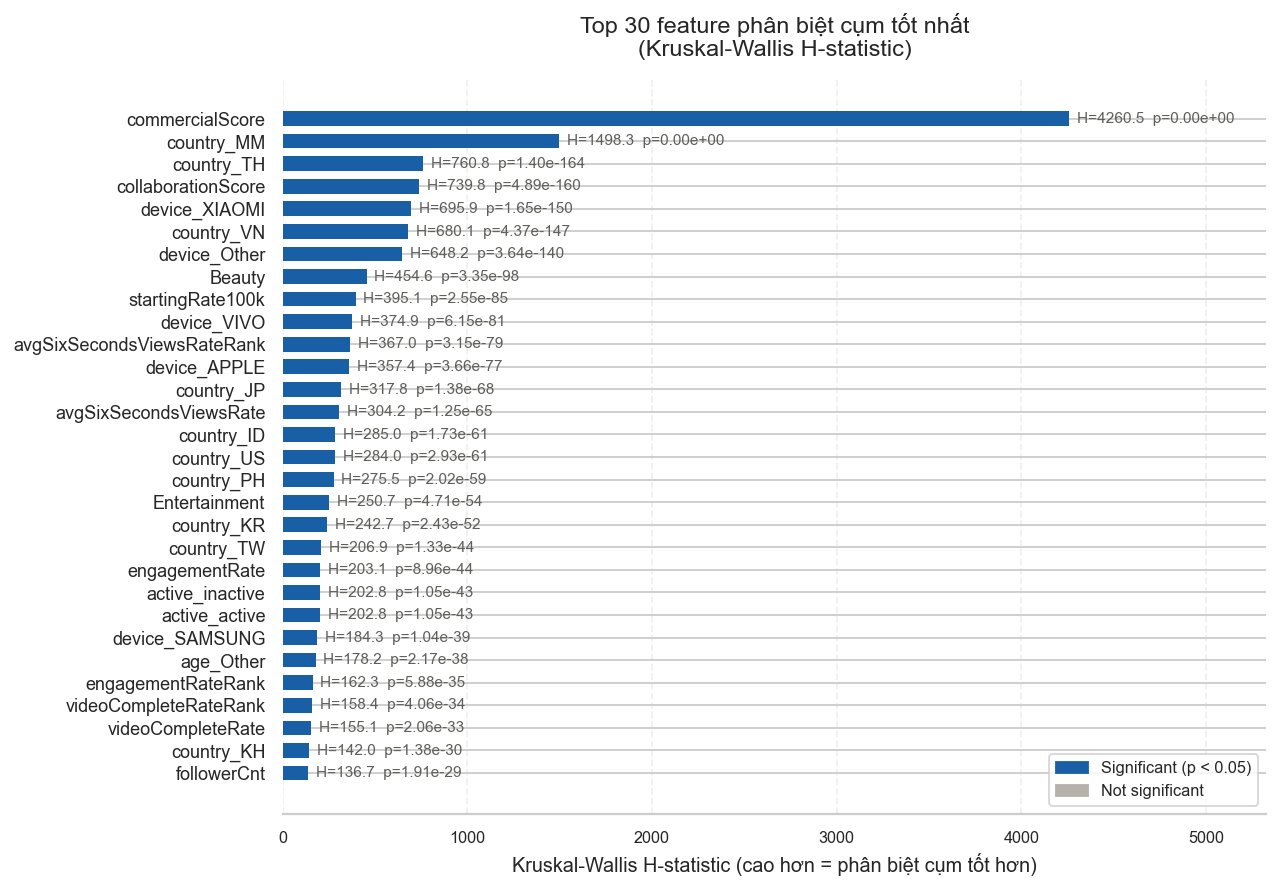

In [ ]:

top_n = 30
top_df = kw_df.head(top_n).sort_values('H_statistic', ascending=True)

# Màu: nổi bật cho significant, mờ cho không đủ ý nghĩa
colors = [
    '#185FA5' if sig else '#B4B2A9'
    for sig in top_df['significant']
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_df['feature'],
    top_df['H_statistic'],
    color=colors,
    height=0.65,
    edgecolor='none'
)

# Ghi H-statistic và p-value lên từng bar
for bar, (_, row) in zip(bars, top_df.iterrows()):
    x_end = bar.get_width()
    p_str = f"p={row['p_value']:.2e}" if row['p_value'] < 0.001 else f"p={row['p_value']:.4f}"
    ax.text(
        x_end + max(top_df['H_statistic']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"H={x_end:.1f}  {p_str}",
        va='center', ha='left', fontsize=8.5,
        color='#5F5E5A'
    )

# Styling
ax.set_xlabel('Kruskal-Wallis H-statistic (cao hơn = phân biệt cụm tốt hơn)', fontsize=11)
ax.set_title('Top 30 feature phân biệt cụm tốt nhất\n(Kruskal-Wallis H-statistic)',
             fontsize=13, fontweight='medium', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Điều chỉnh xlim để nhãn không bị cắt
ax.set_xlim(0, max(top_df['H_statistic']) * 1.25)

# Legend
sig_patch   = mpatches.Patch(color='#185FA5', label='Significant (p < 0.05)')
insig_patch = mpatches.Patch(color='#B4B2A9', label='Not significant')
ax.legend(handles=[sig_patch, insig_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

In [36]:

cluster_cols = [c for c in df.columns if c.startswith("cluster_")]

for c in cluster_cols:
    print(df[c].value_counts(dropna=False).sort_index())

cluster_kmeans
0     788
1    3966
2     322
3      13
Name: count, dtype: int64


In [37]:
# cluster_col = "cluster_spectral" # tách 3 quy mô trên 5 cụm, có sự khác biệt giữa 3 quy mô
cluster_col = "cluster_kmeans" # Xu hướng của quy mô liên tục, nhưng có phân tách 
# cluster_col = "cluster_hierarchical" # 5 cụm nhưng quy mô hơi liên tục, có sự khác biệt 
# cluster_col = "cluster_dbscan" # 2 quy mô, phân tách cực đậm, rõ giữa 2  cụm , cụm -1 cũng rất hay.
# cluster_col = 'cluster_dbscan_7' # 
# cluster_col = 'cluster_kmeans_8'

In [38]:
cluster_cols = [c for c in df.columns if c.startswith("cluster_")]

feature_cols = [
    c for c in df.columns
    if c not in ["handleName"] + cluster_cols
    and pd.api.types.is_numeric_dtype(df[c])
]

print("Số biến dùng để trực quan:", len(feature_cols))
print(feature_cols)

Số biến dùng để trực quan: 59
['followerCnt', 'startingRate100k', 'recommendRate100k', 'followersGrowthRateRank', 'avgSixSecondsViewsRateRank', 'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank', 'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews', 'engagementRateBenchMark', 'followersGrowthRate', 'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate', 'medianViews', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'active_active', 'active_inactive', 'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54', 'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female', 'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW', 'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports', 'total_views_recent', 'total_hearts_recent', 'total_comments_recent', 'median_view_rec

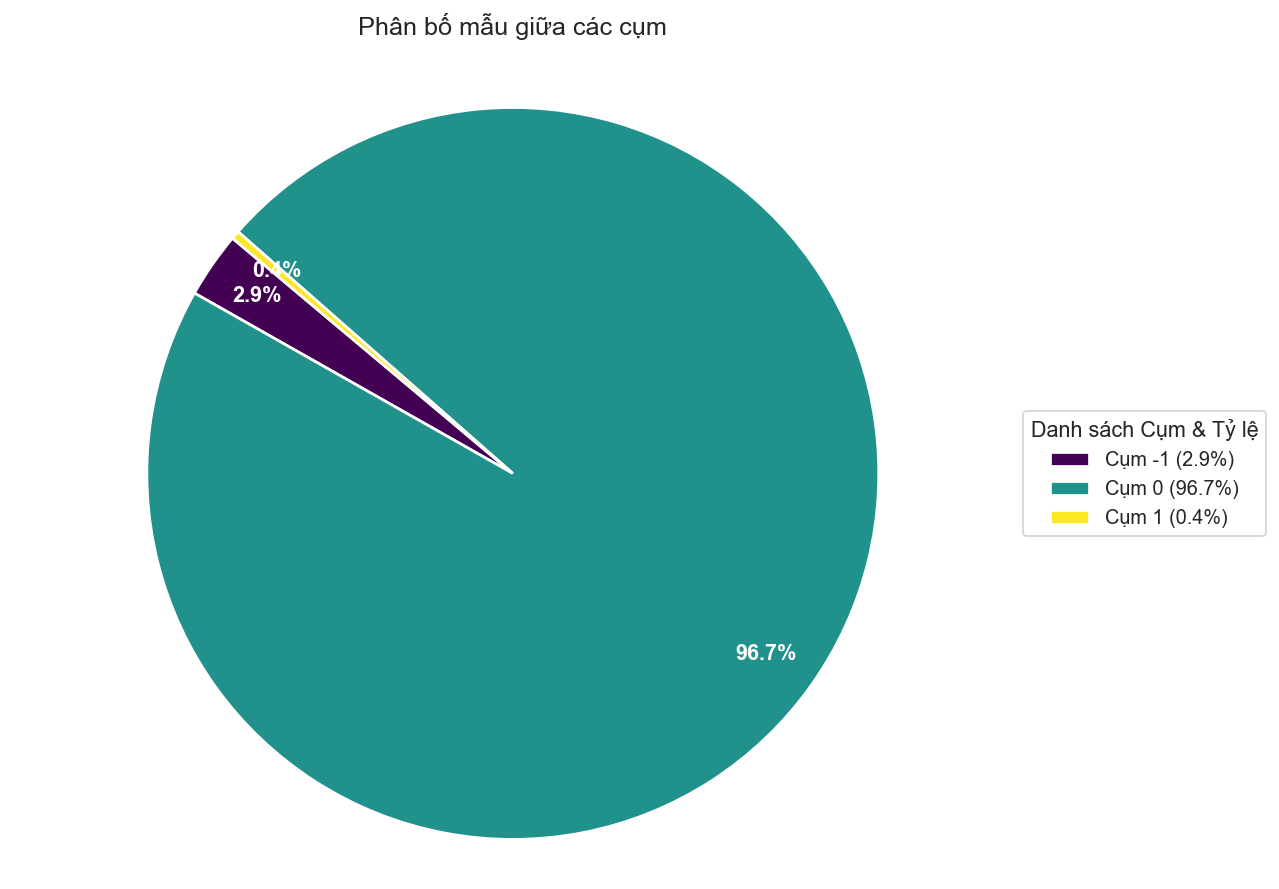

In [39]:


# 1. Chuẩn bị dữ liệu
cluster_col = 'cluster_dbscan'
counts = df_done[cluster_col].value_counts().sort_index()
total = counts.sum()
percents = (counts / total * 100)

# 2. Thiết lập màu sắc hệ 'viridis'
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

# 3. Vẽ biểu đồ tròn
plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    counts, 
    autopct='%1.1f%%',      # Hiển thị % trực tiếp trên hình
    startangle=140, 
    colors=colors,
    pctdistance=0.85,       # Đẩy chữ % ra gần rìa để dễ nhìn
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Viền trắng giữa các miếng
)

# Tùy chỉnh chữ số phần trăm trên biểu đồ
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

# 4. Tạo Legend (Màu - Cụm - Tỷ lệ)
legend_labels = [f"Cụm {int(i)} ({p:.1f}%)" for i, p in zip(counts.index, percents)]

plt.legend(
    wedges, 
    legend_labels,
    title="Danh sách Cụm & Tỷ lệ",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Đặt legend ra ngoài biểu đồ bên phải
    fontsize=11
)

plt.title(f"Phân bố mẫu giữa các cụm", fontsize=14, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

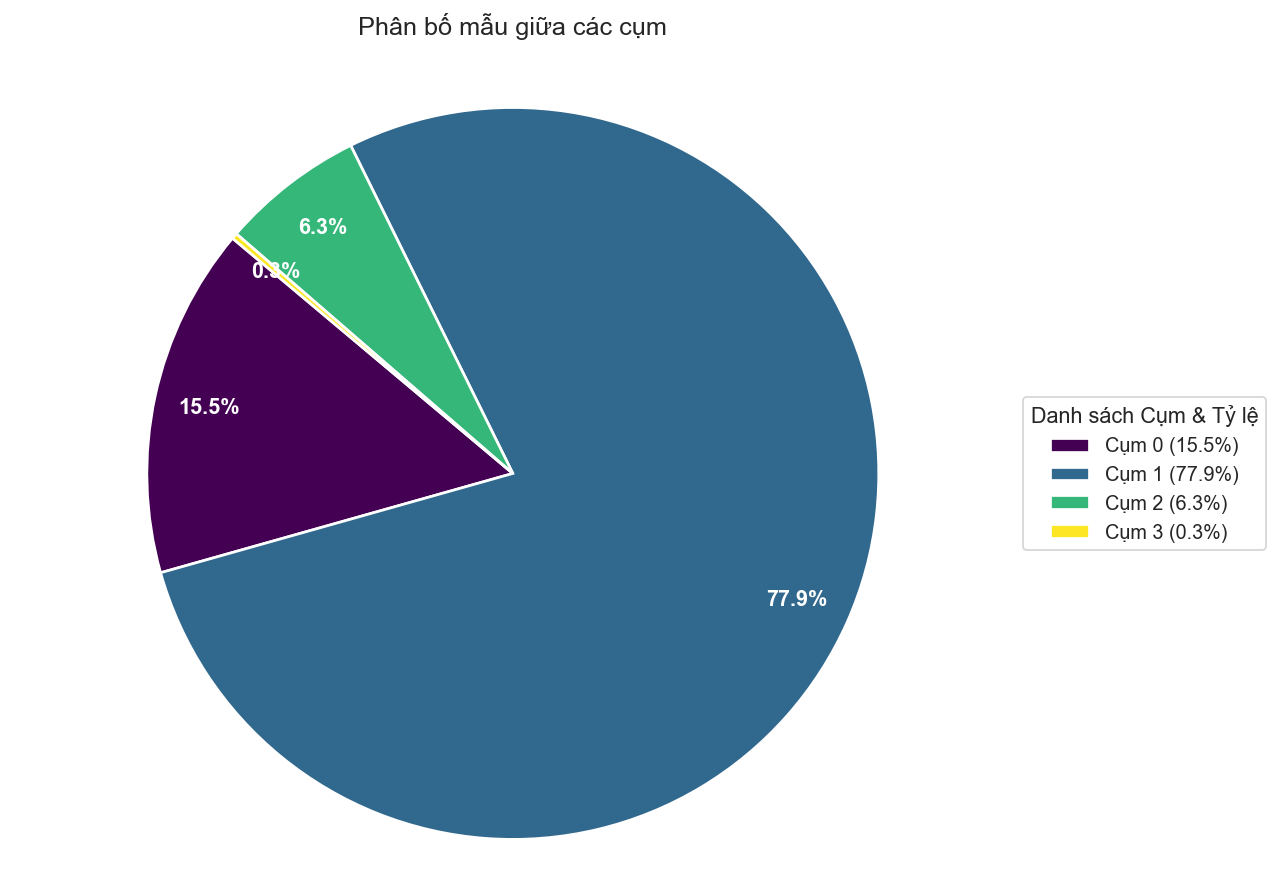

In [40]:


# 1. Chuẩn bị dữ liệu
cluster_col = 'cluster_kmeans'
counts = df_done[cluster_col].value_counts().sort_index()
total = counts.sum()
percents = (counts / total * 100)

# 2. Thiết lập màu sắc hệ 'viridis'
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

# 3. Vẽ biểu đồ tròn
plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    counts, 
    autopct='%1.1f%%',      # Hiển thị % trực tiếp trên hình
    startangle=140, 
    colors=colors,
    pctdistance=0.85,       # Đẩy chữ % ra gần rìa để dễ nhìn
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Viền trắng giữa các miếng
)

# Tùy chỉnh chữ số phần trăm trên biểu đồ
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

# 4. Tạo Legend (Màu - Cụm - Tỷ lệ)
legend_labels = [f"Cụm {int(i)} ({p:.1f}%)" for i, p in zip(counts.index, percents)]

plt.legend(
    wedges, 
    legend_labels,
    title="Danh sách Cụm & Tỷ lệ",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Đặt legend ra ngoài biểu đồ bên phải
    fontsize=11
)

plt.title(f"Phân bố mẫu giữa các cụm", fontsize=14, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

In [41]:


# =========================
# 1. Chọn dữ liệu đầu vào
# =========================
# df_profile là dataframe đã có cột Cluster
# ví dụ: df_profile['Cluster']

cluster_col = 'cluster_kmeans'

key_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    'median_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

# chỉ giữ những cột thật sự có trong df
key_cols = [col for col in key_cols if col in df.columns]

# kiểm tra
print("Số biến dùng để summary:", len(key_cols))
print("Các biến dùng:", key_cols)


# =========================
# 2. Bảng quy mô cụm
# =========================
cluster_size = (
    df[cluster_col]
    .value_counts(dropna=False)
    .sort_index()
    .rename('n_creator')
    .reset_index()
    .rename(columns={'index': cluster_col})
)

cluster_size['pct'] = cluster_size['n_creator'] / cluster_size['n_creator'].sum()

print("\n=== Cluster size ===")
print(cluster_size)


# =========================
# 3. Mean theo cluster
# =========================
cluster_mean = (
    df.groupby(cluster_col)[key_cols]
    .mean()
    .round(4)
)

print("\n=== Cluster mean ===")
display(cluster_mean)


# =========================
# 4. Median theo cluster
# =========================
cluster_median = (
    df.groupby(cluster_col)[key_cols]
    .median()
    .round(4)
)

print("\n=== Cluster median ===")
display(cluster_median)


# =========================
# 5. Std theo cluster (tùy chọn)
# =========================
cluster_std = (
    df.groupby(cluster_col)[key_cols]
    .std()
    .round(4)
)

print("\n=== Cluster std ===")
display(cluster_std)


# =========================
# 6. Gộp thành 1 bảng summary dài
# =========================
summary_rows = []

for clus, sub in df.groupby(cluster_col):  
    row = {
        cluster_col: clus,
        'n_creator': len(sub),
        'pct_creator': len(sub) / len(df)
    }
    
    for col in key_cols:
        row[f'{col}_mean'] = sub[col].mean()
        row[f'{col}_median'] = sub[col].median()
        row[f'{col}_std'] = sub[col].std()
    
    summary_rows.append(row)

cluster_summary = pd.DataFrame(summary_rows).sort_values(cluster_col).reset_index(drop=True)
cluster_summary = cluster_summary.round(4)

print("\n=== Cluster summary full ===")
display(cluster_summary)

Số biến dùng để summary: 10
Các biến dùng: ['followerCnt', 'followersGrowthRate', 'engagementRate', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'median_view_recent', 'cov_view_recent', 'burstiness_recent', 'recency_days_recent']

=== Cluster size ===
   cluster_kmeans  n_creator       pct
0               0        788  0.154844
1               1       3966  0.779328
2               2        322  0.063274
3               3         13  0.002555

=== Cluster mean ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,623794.4150,0.0679,0.0415,87.2104,83.5853,90.5980,100677.5197,1.3134,-0.0384,4.1667
1,360449.6425,11.5788,0.0597,87.6327,74.2032,59.8132,105517.6010,1.3339,-0.0523,6.6853
2,472682.6335,131.8570,0.0577,88.5857,76.4658,62.3925,87059.4907,1.3830,-0.0100,6.4949
3,286518.8462,0.0556,0.0804,91.2462,75.2308,61.4769,121701.0769,1.3751,-0.0429,7.4758



=== Cluster median ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,231061.5,0.0000,0.0297,87.5,84.4,91.2,43961.0,1.1949,-0.0310,2.4977
1,150237.0,0.0046,0.0462,88.2,75.2,60.0,36293.5,1.2358,-0.0490,2.4968
2,238740.5,0.0102,0.0500,88.9,76.8,60.0,21904.0,1.2347,-0.0042,2.3927
3,97263.0,0.0137,0.0698,91.2,75.2,60.0,19262.0,1.3195,-0.0369,2.4930



=== Cluster std ===


,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
cluster_kmeans,,,,,,,,,,
0,1.423830e+06,0.8976,0.0480,6.5620,8.3646,5.4288,239960.4336,0.6931,0.1792,6.3641
1,8.156451e+05,635.0955,0.0489,9.0089,7.8369,4.7799,309298.2241,0.6224,0.2135,13.1221
2,9.511597e+05,2342.6186,0.0375,5.3248,6.4086,7.8573,350174.4956,0.7311,0.2587,11.7504
3,3.669387e+05,0.1296,0.0341,4.2349,4.1935,5.3251,268228.6406,0.4059,0.1781,8.3151



=== Cluster summary full ===


,cluster_kmeans,n_creator,pct_creator,followerCnt_mean,followerCnt_median,followerCnt_std,followersGrowthRate_mean,followersGrowthRate_median,followersGrowthRate_std,engagementRate_mean,...,median_view_recent_std,cov_view_recent_mean,cov_view_recent_median,cov_view_recent_std,burstiness_recent_mean,burstiness_recent_median,burstiness_recent_std,recency_days_recent_mean,recency_days_recent_median,recency_days_recent_std
0,0,788,0.1548,623794.4150,231061.5,1.423830e+06,0.0679,0.0000,0.8976,0.0415,...,239960.4336,1.3134,1.1949,0.6931,-0.0384,-0.0310,0.1792,4.1667,2.4977,6.3641
1,1,3966,0.7793,360449.6425,150237.0,8.156451e+05,11.5788,0.0046,635.0955,0.0597,...,309298.2241,1.3339,1.2358,0.6224,-0.0523,-0.0490,0.2135,6.6853,2.4968,13.1221
2,2,322,0.0633,472682.6335,238740.5,9.511597e+05,131.8570,0.0102,2342.6186,0.0577,...,350174.4956,1.3830,1.2347,0.7311,-0.0100,-0.0042,0.2587,6.4949,2.3927,11.7504
3,3,13,0.0026,286518.8462,97263.0,3.669387e+05,0.0556,0.0137,0.1296,0.0804,...,268228.6406,1.3751,1.3195,0.4059,-0.0429,-0.0369,0.1781,7.4758,2.4930,8.3151


In [42]:

# ====== INPUT ======
# DataFrame chính của bạn
# giả sử tên là df_profile
# và cột cluster là 'cluster_kmeans'

cluster_col = 'cluster_kmeans'

cluster_name_map = {
    0: '0',
    1: '1',
    2: '2',
    3: '3'
}

df = df.copy()

# gán tên cụm
df['cluster_name'] = df[cluster_col].map(cluster_name_map)

# thứ tự hiển thị
cluster_order = [0, 1, 2, 3]
cluster_labels = [cluster_name_map[c] for c in cluster_order]

print(df[[cluster_col, 'cluster_name']].drop_duplicates().sort_values(cluster_col))

     cluster_kmeans cluster_name
1                 0            0
0                 1            1
9                 2            2
714               3            3


In [43]:
key_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    'median_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

# chỉ giữ cột có thật trong df
key_cols = [c for c in key_cols if c in df.columns]

print("Biến dùng để trực quan:", key_cols)

Biến dùng để trực quan: ['followerCnt', 'followersGrowthRate', 'engagementRate', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'median_view_recent', 'cov_view_recent', 'burstiness_recent', 'recency_days_recent']


In [44]:
cluster_size = (
    df.groupby([cluster_col, 'cluster_name'])
      .size()
      .reset_index(name='n_creator')
      .sort_values(cluster_col)
)

cluster_size['pct'] = cluster_size['n_creator'] / cluster_size['n_creator'].sum()

display(cluster_size)

,cluster_kmeans,cluster_name,n_creator,pct
0,0,0,788,0.154844
1,1,1,3966,0.779328
2,2,2,322,0.063274
3,3,3,13,0.002555


In [45]:
cluster_mean_named = (
    df.groupby([cluster_col, 'cluster_name'])[key_cols]
      .mean()
      .reset_index()
      .sort_values(cluster_col)
)

cluster_median_named = (
    df.groupby([cluster_col, 'cluster_name'])[key_cols]
      .median()
      .reset_index()
      .sort_values(cluster_col)
)

display(cluster_mean_named)
display(cluster_median_named)

,cluster_kmeans,cluster_name,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
0,0,0,623794.414975,0.067950,0.041521,87.210406,83.585279,90.597970,100677.519670,1.313369,-0.038445,4.166663
1,1,1,360449.642461,11.578777,0.059686,87.632728,74.203227,59.813212,105517.600983,1.333893,-0.052345,6.685332
2,2,2,472682.633540,131.857013,0.057747,88.585714,76.465839,62.392547,87059.490683,1.383030,-0.009987,6.494906
3,3,3,286518.846154,0.055641,0.080438,91.246154,75.230769,61.476923,121701.076923,1.375052,-0.042886,7.475752


,cluster_kmeans,cluster_name,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,collaborationScore,commercialScore,median_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
0,0,0,231061.5,0.000009,0.02970,87.5,84.4,91.2,43961.0,1.194916,-0.030984,2.497708
1,1,1,150237.0,0.004577,0.04620,88.2,75.2,60.0,36293.5,1.235818,-0.048970,2.496771
2,2,2,238740.5,0.010198,0.05005,88.9,76.8,60.0,21904.0,1.234680,-0.004156,2.392697
3,3,3,97263.0,0.013731,0.06980,91.2,75.2,60.0,19262.0,1.319528,-0.036880,2.492951


In [46]:
def zscore_by_column(dataframe, cols):
    out = dataframe.copy()
    for c in cols:
        mean_ = out[c].mean()
        std_ = out[c].std()
        if std_ == 0 or pd.isna(std_):
            out[c] = 0
        else:
            out[c] = (out[c] - mean_) / std_
    return out

def plot_heatmap(df_plot, value_cols, title, figsize=(12, 5), annotate=True):
    values = df_plot[value_cols].values
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(values, aspect='auto')

    ax.set_xticks(np.arange(len(value_cols)))
    ax.set_xticklabels(value_cols, rotation=45, ha='right')

    ax.set_yticks(np.arange(len(df_plot)))
    ax.set_yticklabels(df_plot['cluster_name'])

    ax.set_title(title)

    # ghi số trong từng ô
    if annotate:
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                ax.text(j, i, f"{values[i, j]:.2f}",
                        ha='center', va='center', fontsize=8)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Z-score')

    plt.tight_layout()
    plt.show()

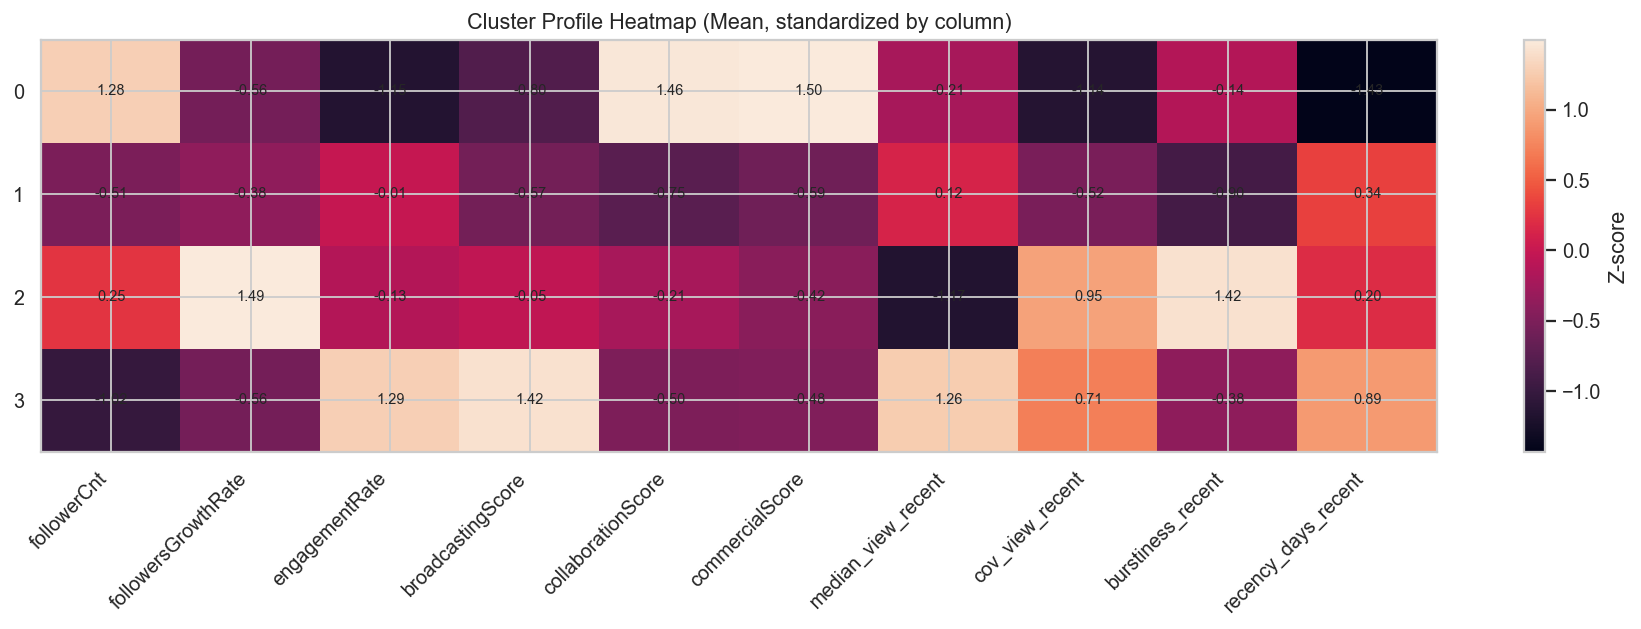

In [47]:
mean_for_heatmap = cluster_mean_named.copy()
mean_for_heatmap = zscore_by_column(mean_for_heatmap, key_cols)

plot_heatmap(
    mean_for_heatmap,
    value_cols=key_cols,
    title='Cluster Profile Heatmap (Mean, standardized by column)',
    figsize=(14, 5),
    annotate=True
)

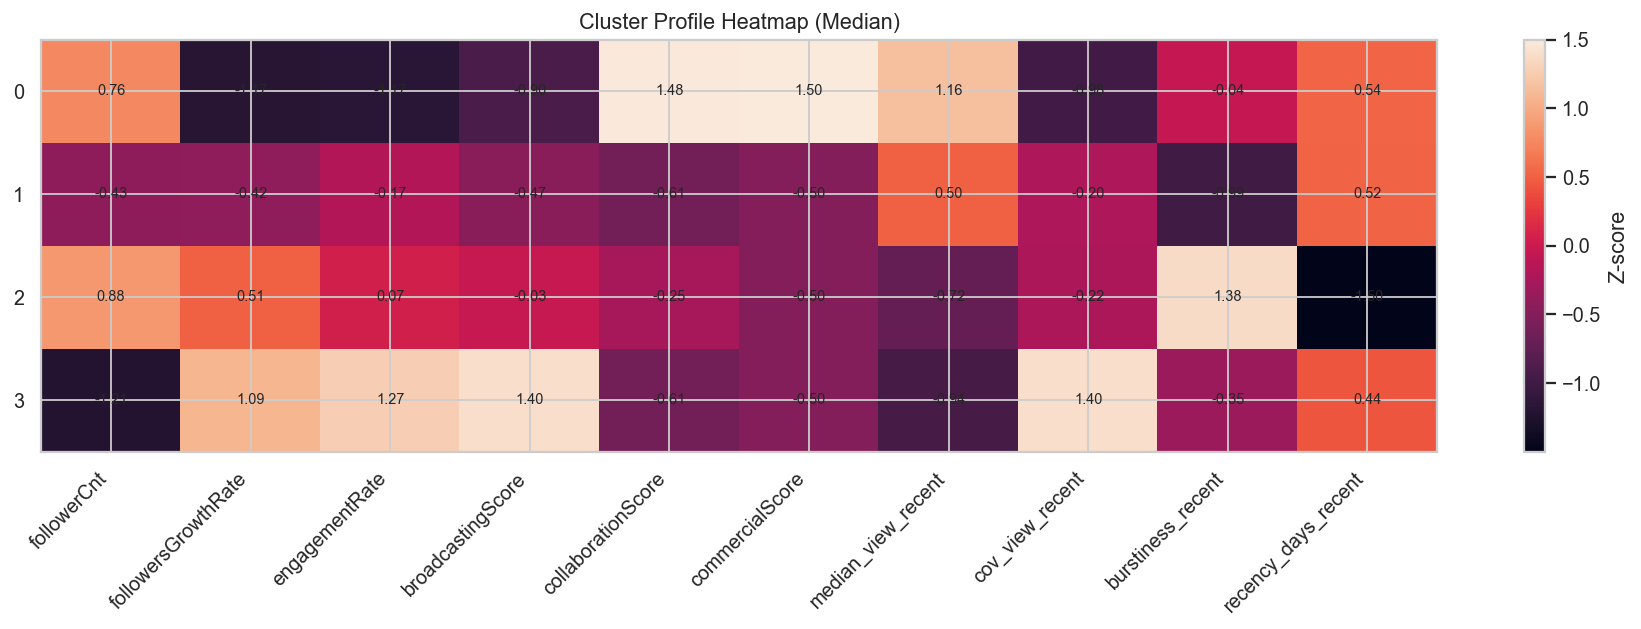

In [48]:
median_for_heatmap = cluster_median_named.copy()
median_for_heatmap = zscore_by_column(median_for_heatmap, key_cols)

plot_heatmap(
    median_for_heatmap,
    value_cols=key_cols,
    title='Cluster Profile Heatmap (Median)',
    figsize=(14, 5),
    annotate=True
)


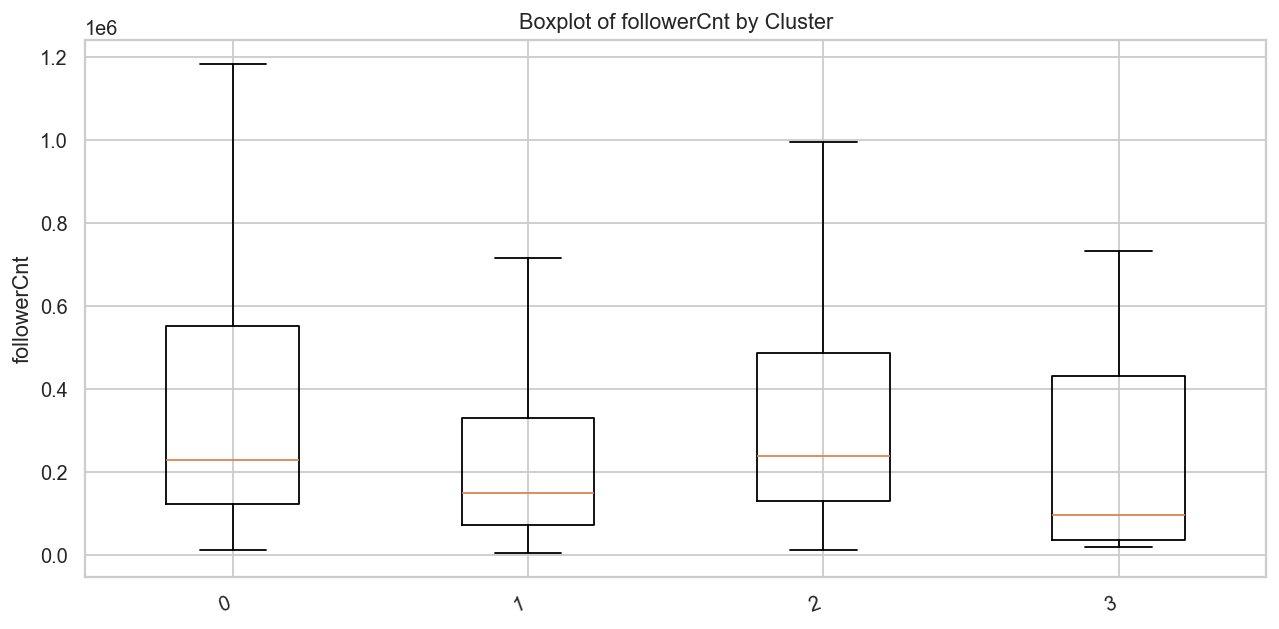

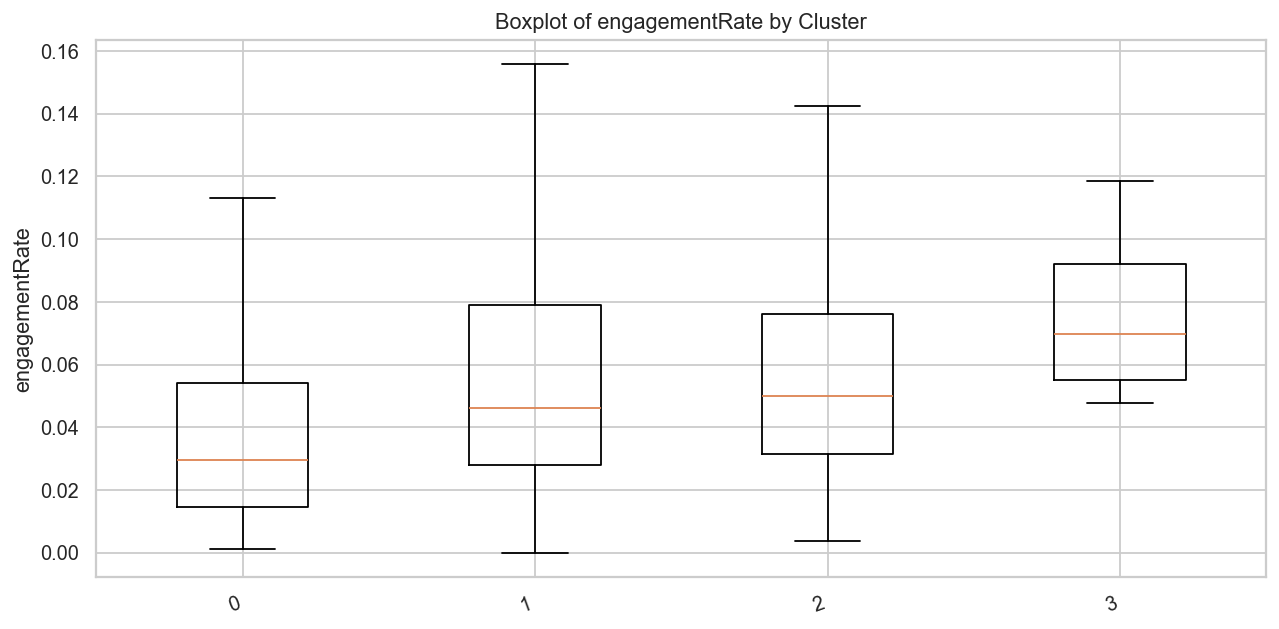

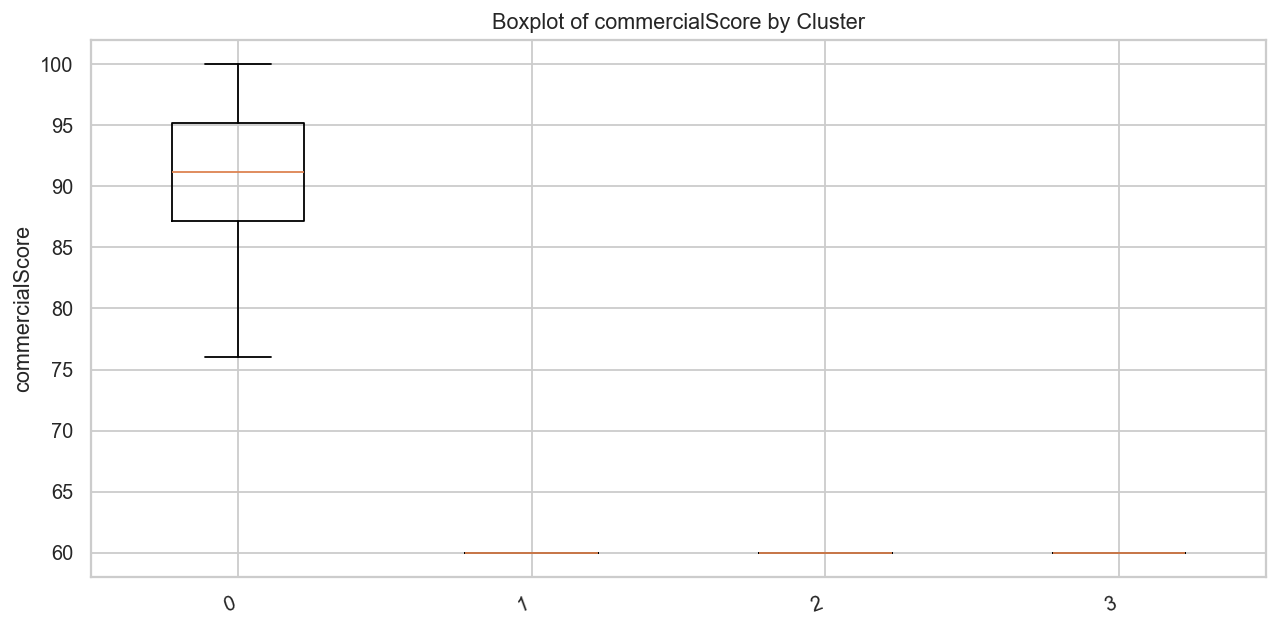

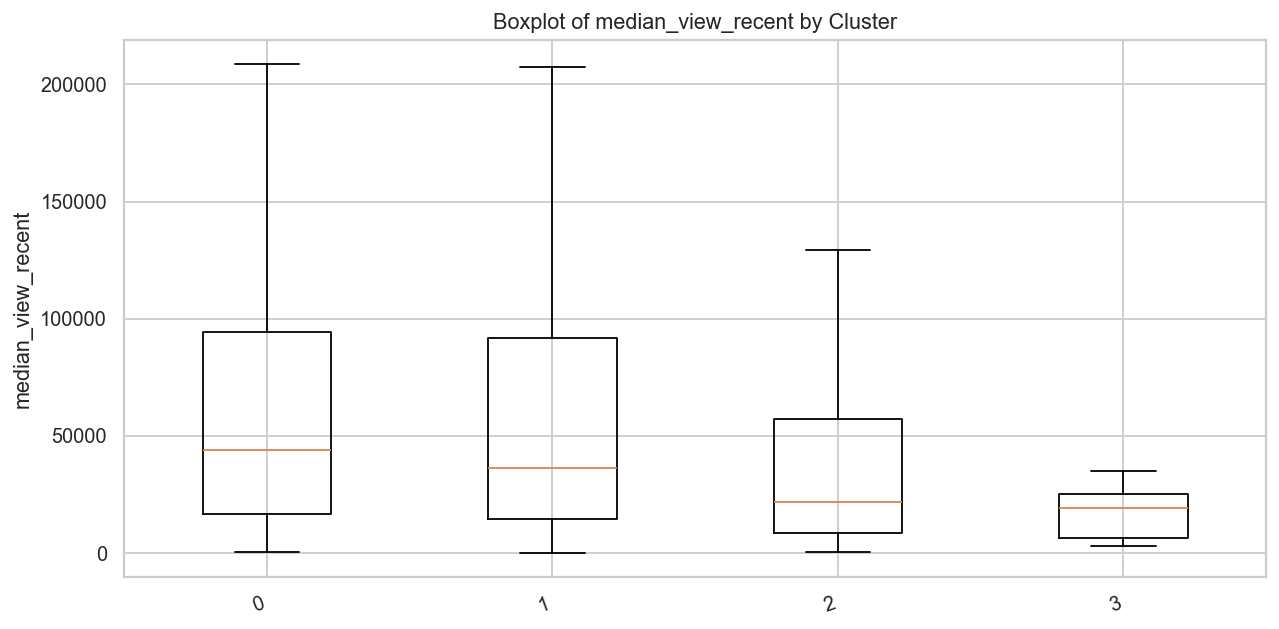

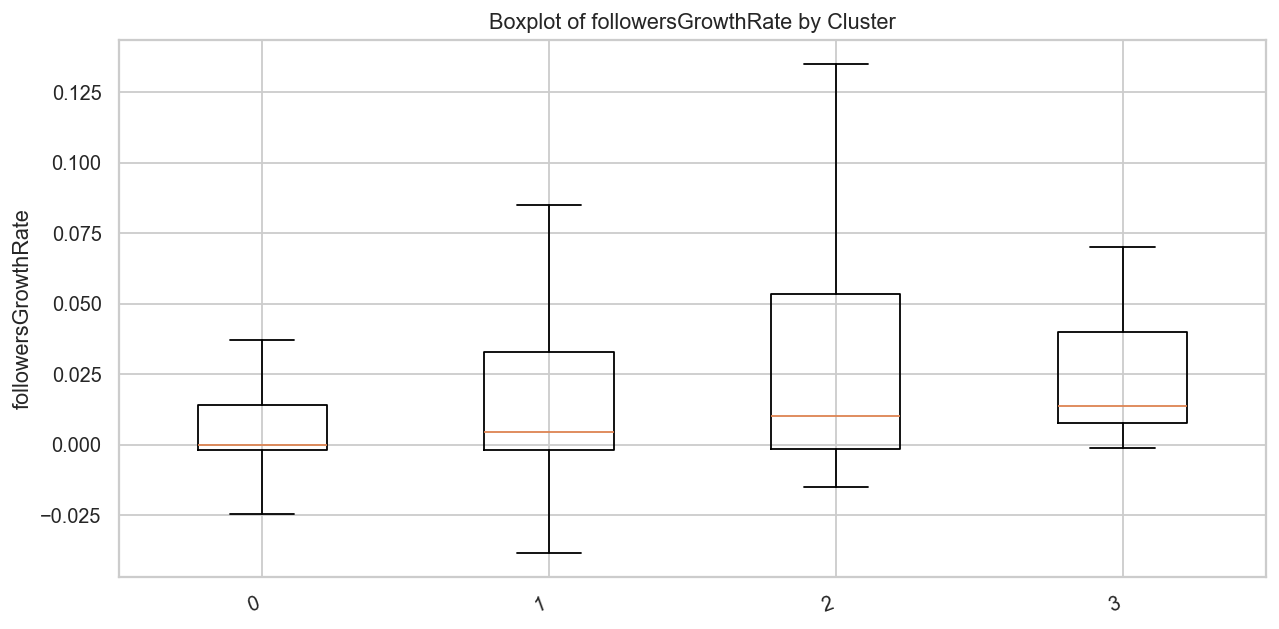

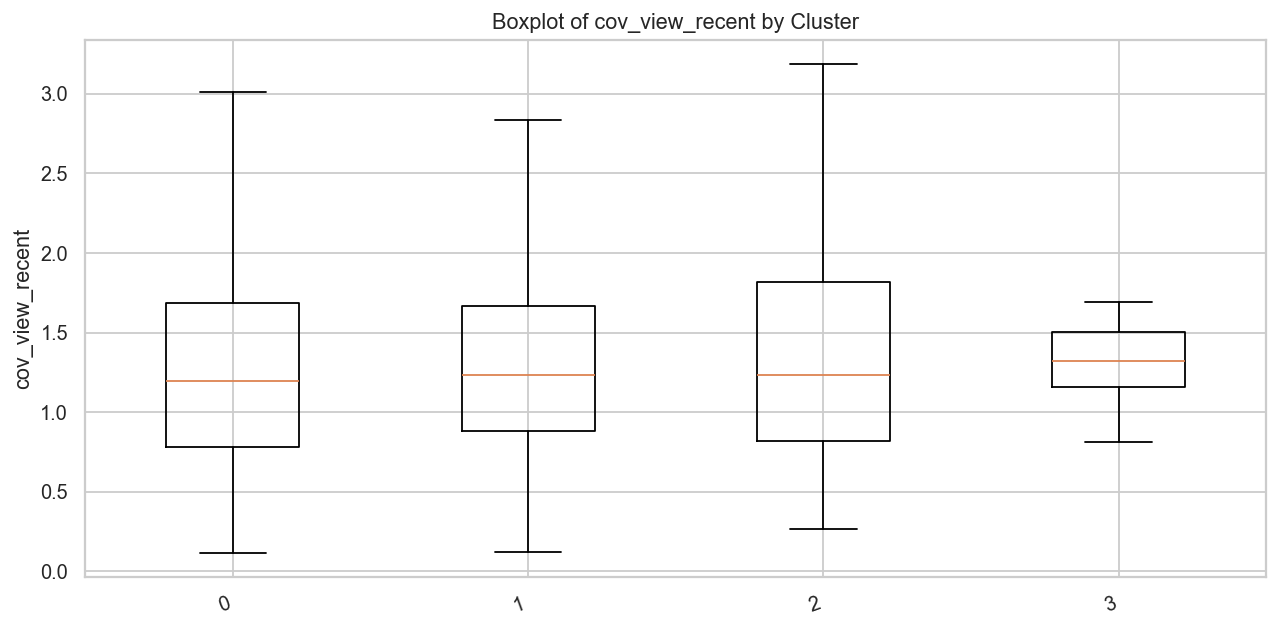

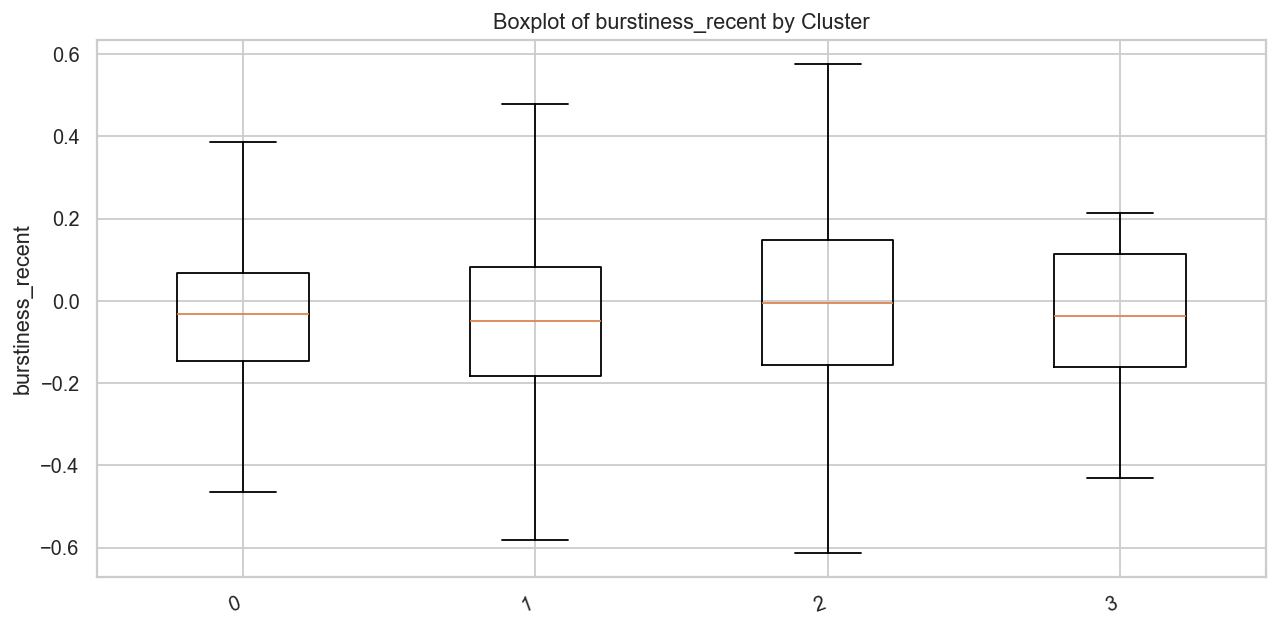

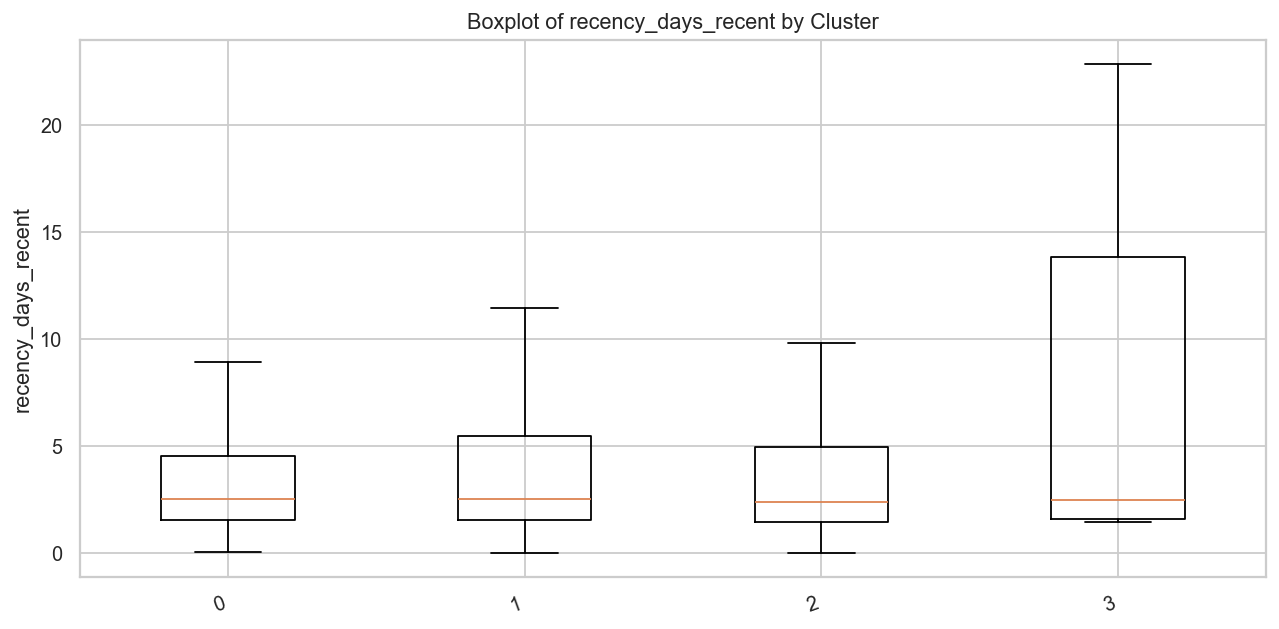

In [49]:
plot_cols = [
    'followerCnt',
    'engagementRate',
    'commercialScore',
    'median_view_recent',
    'followersGrowthRate',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

plot_cols = [c for c in plot_cols if c in df.columns]

for col in plot_cols:
    plt.figure(figsize=(10, 5))
    
    data_to_plot = [
        df.loc[df[cluster_col] == c, col].dropna().values
        for c in cluster_order
    ]
    
    plt.boxplot(data_to_plot, labels=cluster_labels, showfliers=False)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Boxplot of {col} by Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

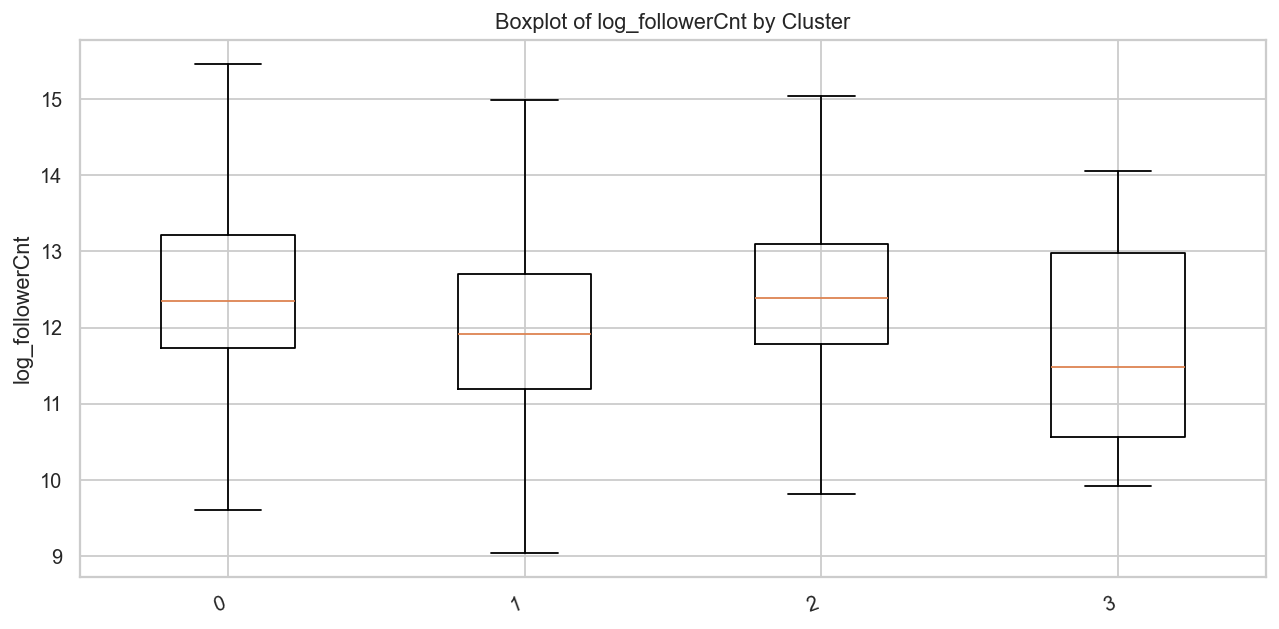

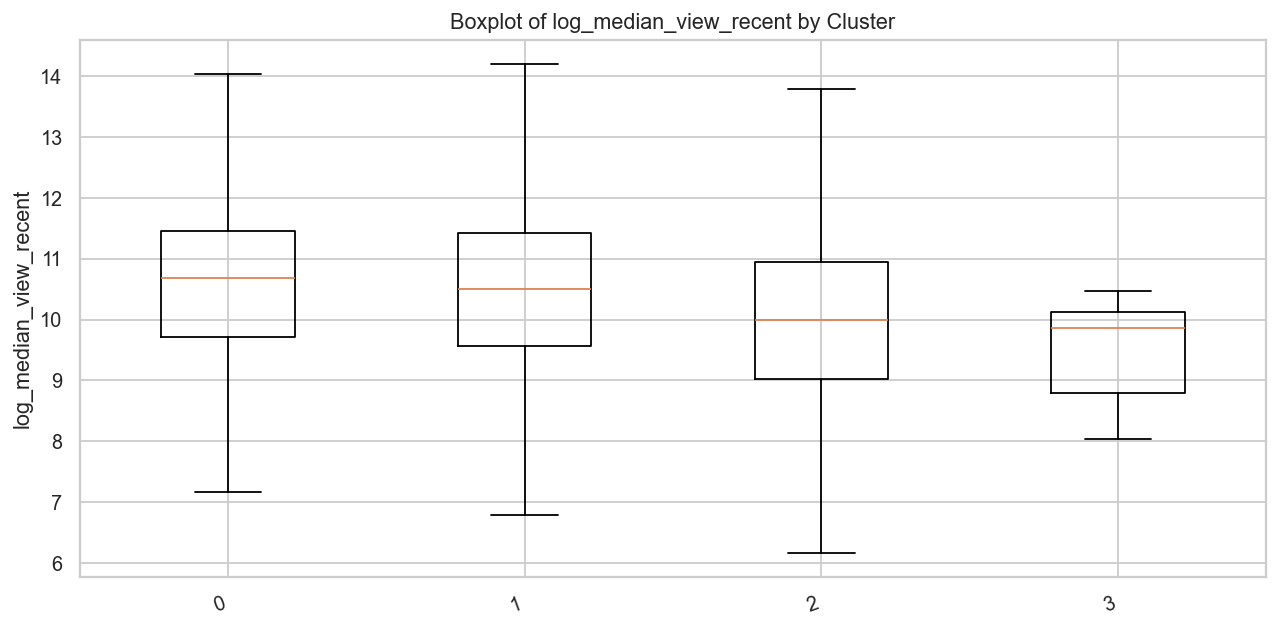

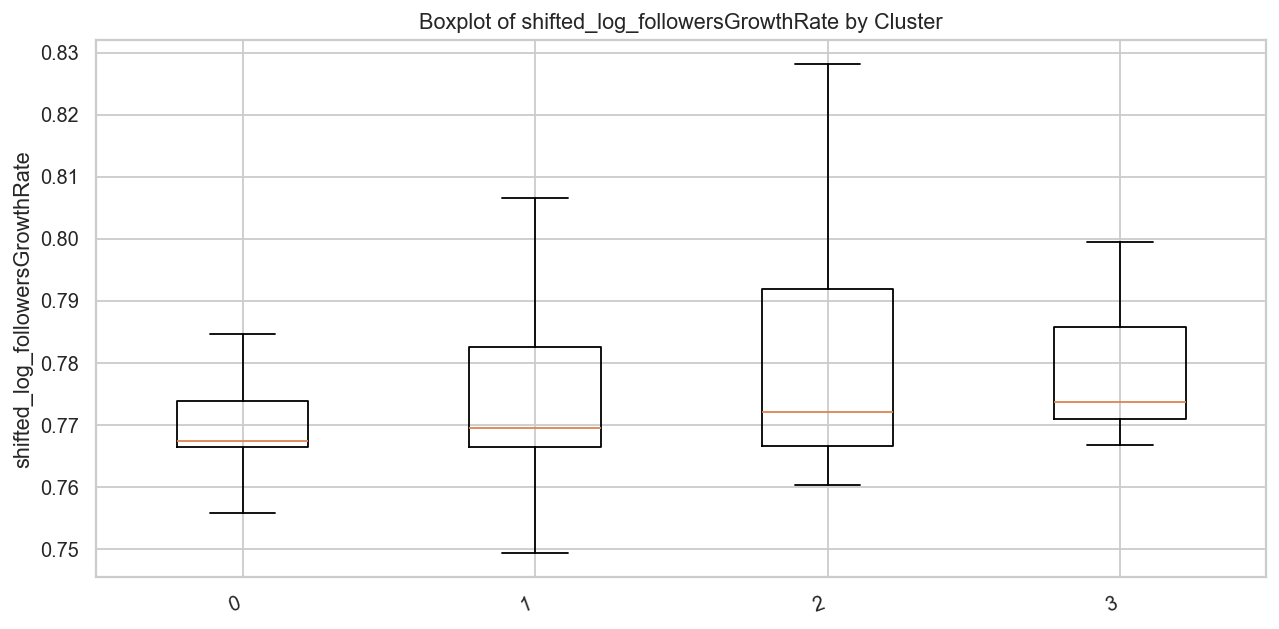

In [50]:
df['log_followerCnt'] = np.log1p(df['followerCnt']) if 'followerCnt' in df.columns else np.nan
df['log_median_view_recent'] = np.log1p(df['median_view_recent']) if 'median_view_recent' in df.columns else np.nan

# followersGrowthRate có thể có giá trị âm hoặc gần 0, nên cần cẩn thận
if 'followersGrowthRate' in df.columns:
    min_val = df['followersGrowthRate'].min()
    shift = 1 - min_val if min_val <= 0 else 0
    df['shifted_log_followersGrowthRate'] = np.log1p(df['followersGrowthRate'] + shift)

extra_plot_cols = ['log_followerCnt', 'log_median_view_recent', 'shifted_log_followersGrowthRate']
extra_plot_cols = [c for c in extra_plot_cols if c in df.columns]

for col in extra_plot_cols:
    plt.figure(figsize=(10, 5))
    
    data_to_plot = [
        df.loc[df[cluster_col] == c, col].dropna().values
        for c in cluster_order
    ]
    
    plt.boxplot(data_to_plot, labels=cluster_labels, showfliers=False)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Boxplot of {col} by Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [51]:
# ================================================================
# CLUSTER 0 — Commercial Mature Leaders: Deep Dive Analysis
# Dán từng section vào notebook, chạy theo thứ tự từ trên xuống
# ================================================================



# ── Màu sắc nhất quán cho toàn bộ phân tích ──────────────────
CLR = {
    'purple':       '#534AB7',
    'purple_mid':   '#7F77DD',
    'purple_light': '#EEEDFE',
    'coral':        '#D85A30',
    'coral_light':  '#FAECE7',
    'amber':        '#BA7517',
    'amber_light':  '#FAEEDA',
    'teal':         '#1D9E75',
    'teal_light':   '#E1F5EE',
    'gray':         '#B4B2A9',
    'gray_dark':    '#5F5E5A',
    'gray_light':   '#F1EFE8',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

# ── Lấy dữ liệu Cluster 0 ────────────────────────────────────
c0 = df[df['cluster_kmeans'] == 0].copy()
print(f"✓ Cluster 0 — Commercial Mature Leaders: {len(c0):,} creators")
print(f"  Cột hiện có: {c0.columns.tolist()}\n")



✓ Cluster 0 — Commercial Mature Leaders: 788 creators
  Cột hiện có: ['handleName', 'followerCnt', 'startingRate100k', 'recommendRate100k', 'followersGrowthRateRank', 'avgSixSecondsViewsRateRank', 'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank', 'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews', 'engagementRateBenchMark', 'followersGrowthRate', 'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate', 'medianViews', 'broadcastingScore', 'collaborationScore', 'commercialScore', 'active_active', 'active_inactive', 'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54', 'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female', 'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW', 'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports', 'total_views_recent', 'total_hear

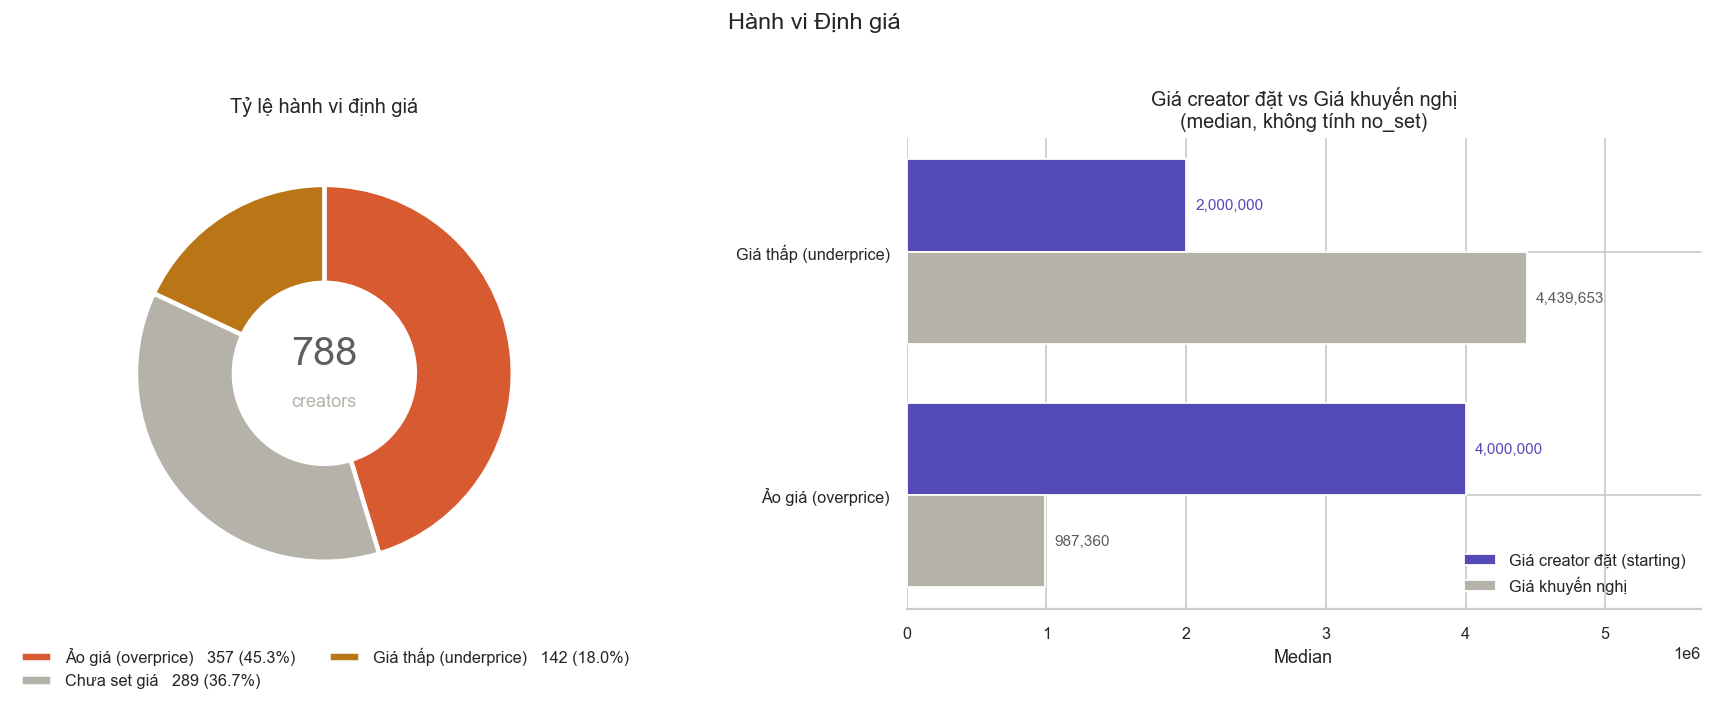

📊 Section 1 xong. File: c0_1_pricing_behavior.png


In [ ]:

# ================================================================
# SECTION 1 — HÀNH VI ĐỊNH GIÁ
# Biểu đồ: Donut (tỷ lệ) + Horizontal bar (giá thực vs khuyến nghị)
# Lý do chọn: Donut rõ nhất cho 4 category, bar cho so sánh 2 giá trị
# ================================================================

# ── Tạo cột pricing_behavior nếu chưa có ─────────────────────
if 'pricing_behavior' not in c0.columns:
    c0['pricing_behavior'] = 'normal'
    c0.loc[
        c0['startingRate100k'].isna() | (c0['startingRate100k'] == 0),
        'pricing_behavior'
    ] = 'no_set'
    c0.loc[
        c0['startingRate100k'] > c0['recommendRate100k'],
        'pricing_behavior'
    ] = 'overprice'
    c0.loc[
        (c0['startingRate100k'] < c0['recommendRate100k']) &
        (c0['pricing_behavior'] != 'no_set'),
        'pricing_behavior'
    ] = 'underprice'

LABEL_MAP = {
    'overprice':  'Ảo giá (overprice)',
    'underprice': 'Giá thấp (underprice)',
    'no_set':     'Chưa set giá',
    'normal':     'Giá hợp lý (normal)',
}
COLOR_MAP = {
    'overprice':  CLR['coral'],
    'underprice': CLR['amber'],
    'no_set':     CLR['gray'],
    'normal':     CLR['purple'],
}

price_counts = c0['pricing_behavior'].value_counts()
total        = len(c0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Hành vi Định giá',
    fontsize=13, fontweight='500', y=1.01
)

# ── [Trái] Donut: tỷ lệ 4 nhóm ───────────────────────────────
ax = axes[0]
labels  = [LABEL_MAP.get(k, k) for k in price_counts.index]
colors  = [COLOR_MAP.get(k, CLR['purple_mid']) for k in price_counts.index]
wedges, _ = ax.pie(
    price_counts.values,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
    counterclock=False,
)
ax.text(0, 0.1,  f'{total:,}',    ha='center', va='center',
        fontsize=22, fontweight='500', color=CLR['gray_dark'])
ax.text(0, -0.15, 'creators', ha='center', va='center',
        fontsize=10, color=CLR['gray'])

leg_labels = [
    f'{l}   {n:,} ({n/total:.1%})'
    for l, n in zip(labels, price_counts.values)
]
ax.legend(wedges, leg_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.2), fontsize=9, frameon=False, ncol=2)
ax.set_title('Tỷ lệ hành vi định giá', fontsize=11, pad=14)

# ── [Phải] Horizontal bar: median starting vs recommend ───────
ax2 = axes[1]
rate_df = c0[c0['pricing_behavior'] != 'no_set'].copy()
rate_med = (
    rate_df.groupby('pricing_behavior')[
        ['startingRate100k', 'recommendRate100k']
    ]
    .median()
    .reset_index()
)
rate_med['startingRate100k'] = rate_med['startingRate100k'] / 100000
rate_med['recommendRate100k'] = rate_med['recommendRate100k'] / 100000
x   = np.arange(len(rate_med))
w   = 0.38
max_val = max(rate_med['startingRate100k'].max(),
              rate_med['recommendRate100k'].max())

b1 = ax2.barh(x + w/2, rate_med['startingRate100k'],   height=w,
              color=CLR['purple'],   label='Giá creator đặt (starting)')
b2 = ax2.barh(x - w/2, rate_med['recommendRate100k'],  height=w,
              color=CLR['gray'],     label='Giá khuyến nghị')

ax2.set_yticks(x)
ax2.set_yticklabels([LABEL_MAP.get(b, b) for b in rate_med['pricing_behavior']])
ax2.set_xlabel('Median')
ax2.set_title('Giá creator đặt vs Giá khuyến nghị\n(median, không tính no_set)', fontsize=11)
ax2.legend(fontsize=9, frameon=False, loc='lower right')
ax2.spines['left'].set_visible(False)
ax2.set_xlim(0, max_val * 1.28)

for bar in b1:
    v = bar.get_width()
    ax2.text(v + max_val * 0.015, bar.get_y() + bar.get_height()/2,
             f'{v:,.0f}', va='center', fontsize=8.5, color=CLR['purple'])
for bar in b2:
    v = bar.get_width()
    ax2.text(v + max_val * 0.015, bar.get_y() + bar.get_height()/2,
             f'{v:,.0f}', va='center', fontsize=8.5, color=CLR['gray_dark'])

plt.tight_layout()
plt.show()

print("📊 Section 1 xong. File: c0_1_pricing_behavior.png")


Cluster 0 — Commercial Mature Leaders: 788 creators



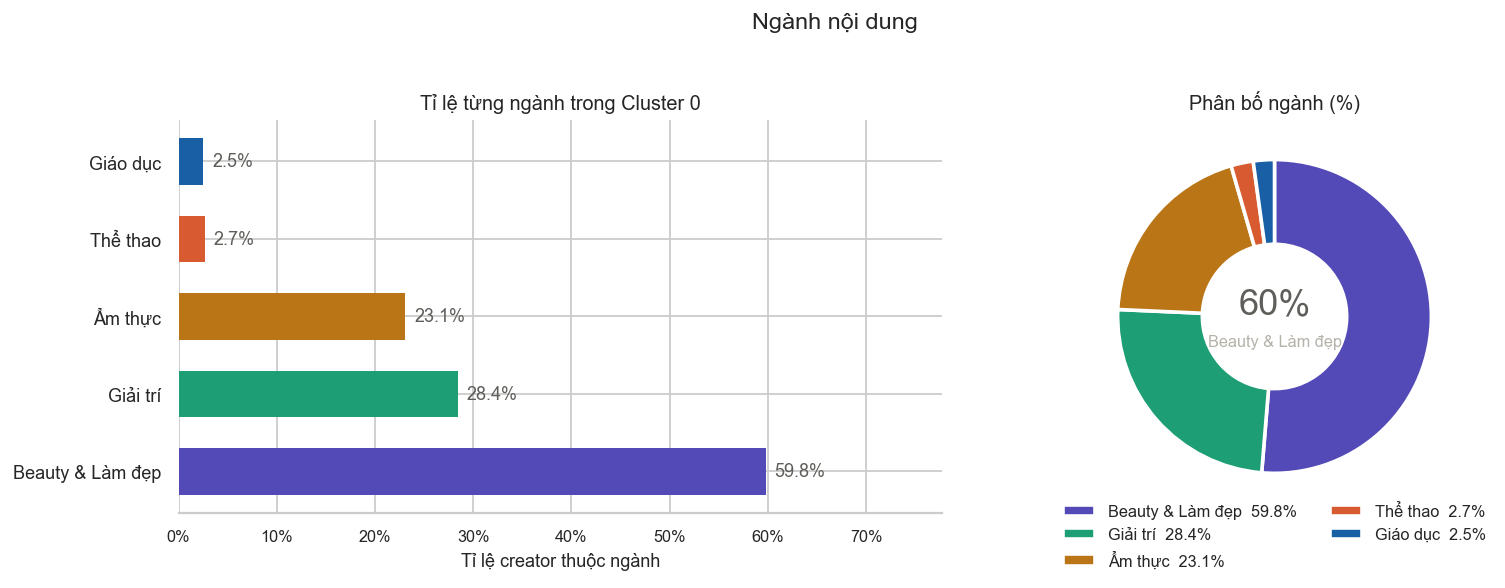

📊 Section 3 xong → c0_3_content.png


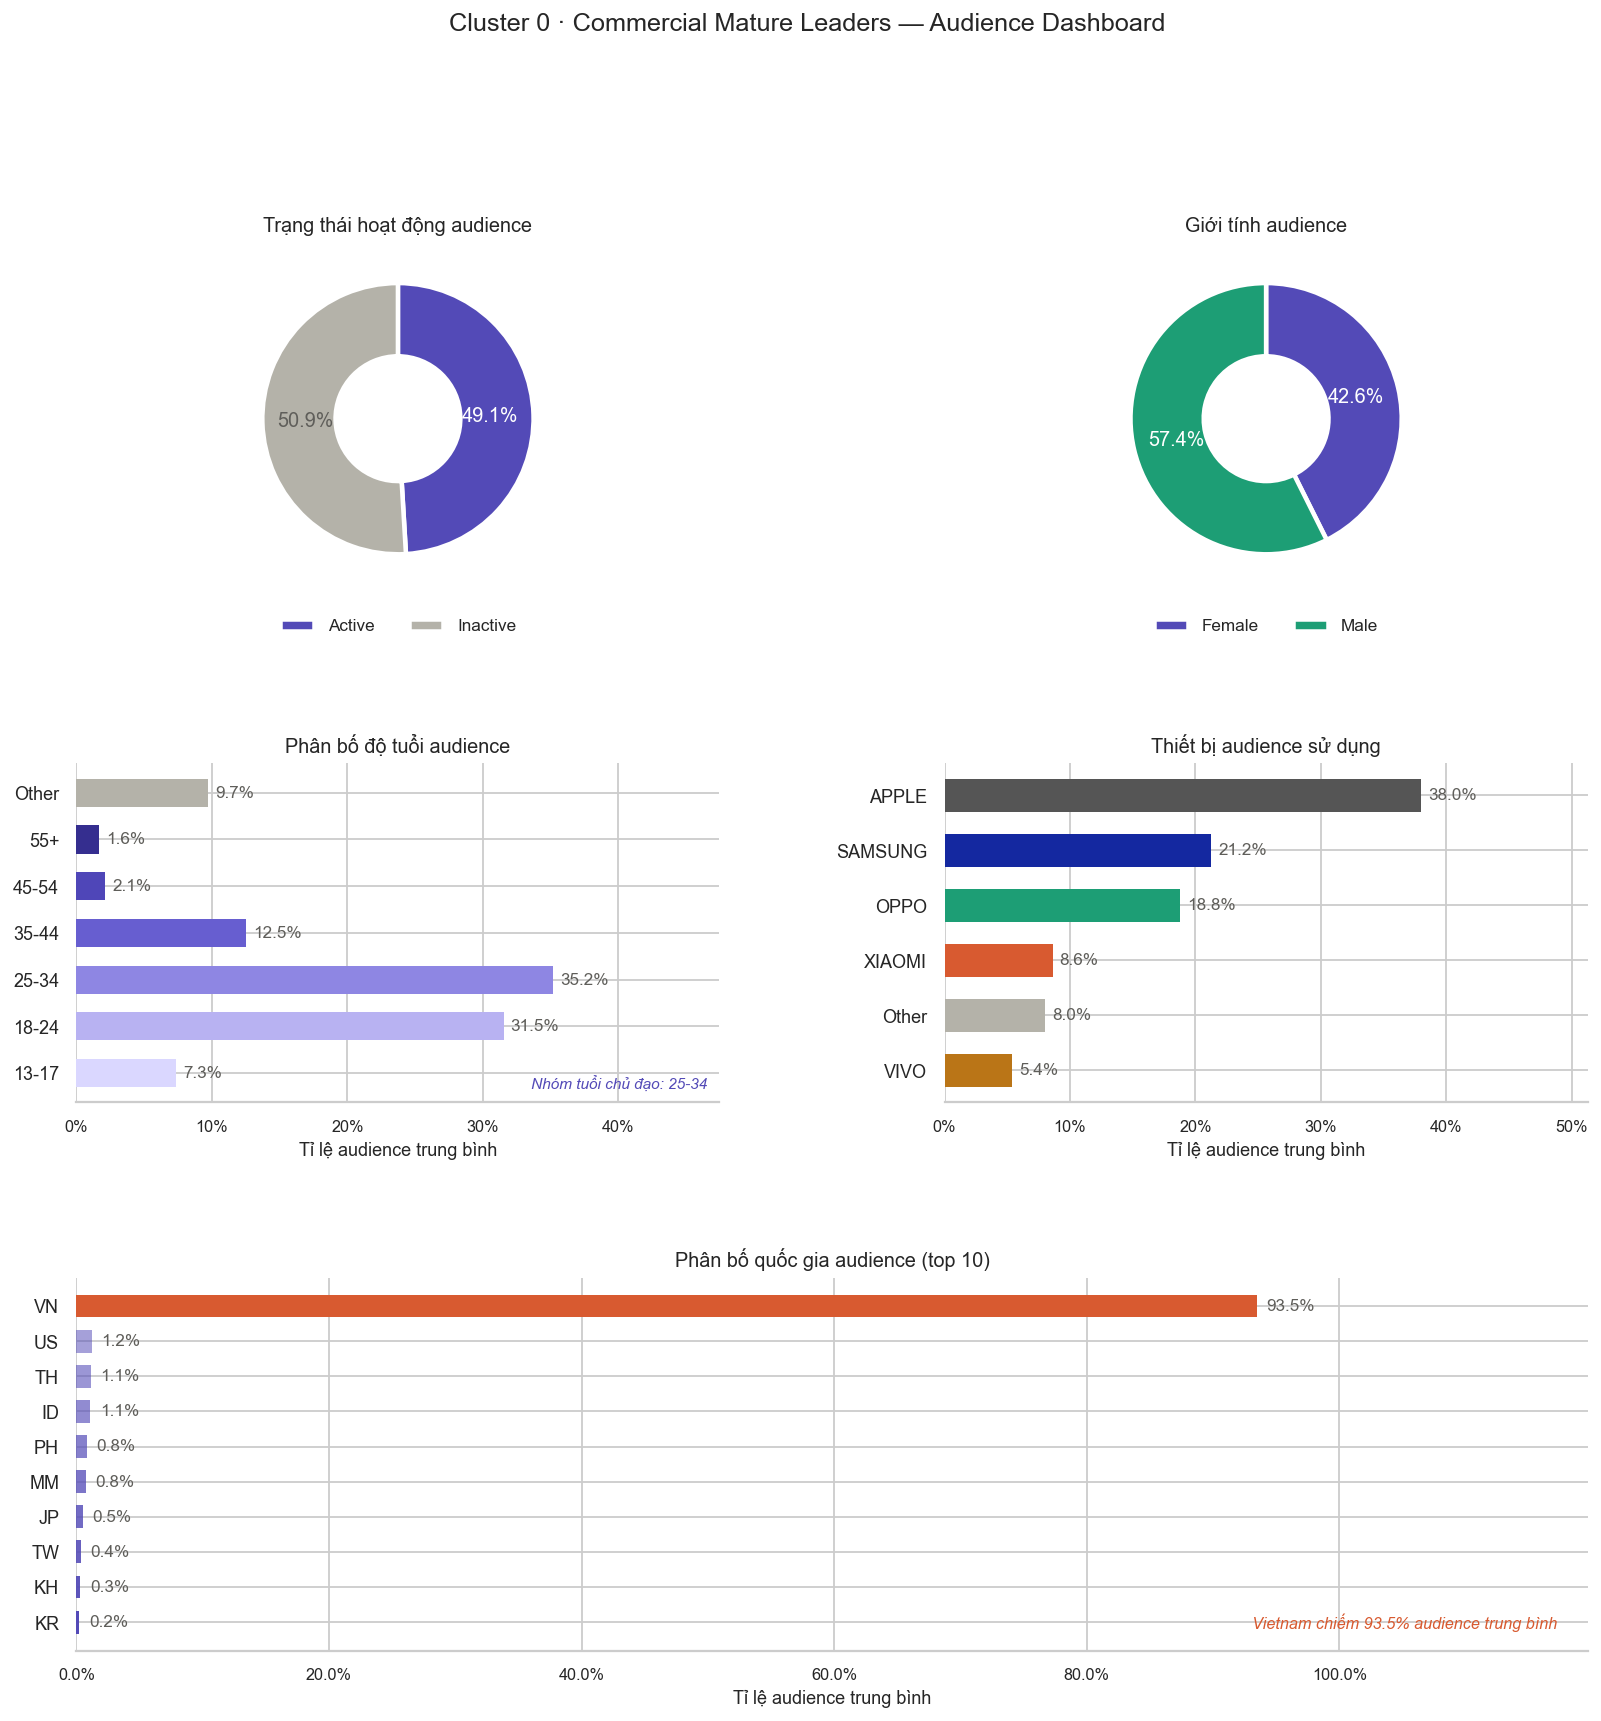

📊 Section 4 xong → c0_4_audience_dashboard.png

═══════════════════════════════════════════════════════
  CLUSTER 0 — AUDIENCE SUMMARY
═══════════════════════════════════════════════════════

  Trạng thái hoạt động:
    active      : 49.1%
    inactive    : 50.9%

  Giới tính:
    Female    : 42.6%
    Male      : 57.4%

  Độ tuổi (sắp xếp theo thứ tự):
    13-17     : 7.3%
    18-24     : 31.5%
    25-34     : 35.2%
    35-44     : 12.5%
    45-54     : 2.1%
    55+       : 1.6%
    Other     : 9.7%

  Thiết bị:
    APPLE       : 38.0%
    SAMSUNG     : 21.2%
    OPPO        : 18.8%
    XIAOMI      : 8.6%
    Other       : 8.0%
    VIVO        : 5.4%

  Quốc gia (top 5):
    VN      : 93.5%
    US      : 1.2%
    TH      : 1.1%
    ID      : 1.1%
    PH      : 0.8%

  Ngành nội dung:
    Beauty         : 59.8%
    Entertainment  : 28.4%
    Food           : 23.1%
    Sports         : 2.7%
    Education      : 2.5%


In [ ]:
# ================================================================
# CLUSTER 0 — SECTION 3 & 4: NGÀNH NỘI DUNG + AUDIENCE
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── Palette ──────────────────────────────────────────────────
CLR = {
    'purple':       '#534AB7',
    'purple_mid':   '#7F77DD',
    'purple_light': '#EEEDFE',
    'coral':        '#D85A30',
    'coral_light':  '#FAECE7',
    'amber':        '#BA7517',
    'amber_light':  '#FAEEDA',
    'teal':         '#1D9E75',
    'teal_light':   '#E1F5EE',
    'blue':         '#185FA5',
    'blue_light':   '#E6F1FB',
    'green':        '#3B6D11',
    'green_light':  '#EAF3DE',
    'gray':         '#B4B2A9',
    'gray_dark':    '#5F5E5A',
    'gray_light':   '#F1EFE8',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

# ── Filter Cluster 0 ─────────────────────────────────────────
c0 = df[df['cluster_kmeans'] == 0].copy()
N  = len(c0)
print(f"Cluster 0 — Commercial Mature Leaders: {N:,} creators\n")

# ── Định nghĩa các cột ───────────────────────────────────────
AUDIENCE_COLS = [
    'active_active', 'active_inactive',
    'age_18-24', 'age_25-34', 'age_13-17',
    'age_35-44', 'age_55+', 'age_45-54', 'age_Other',
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO', 'device_Other',
    'gender_Female', 'gender_Male',
    'country_VN', 'country_US', 'country_JP', 'country_TW',
    'country_KR', 'country_MM', 'country_KH',
    'country_TH', 'country_PH', 'country_ID',
]
CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']

# Chỉ giữ cột có thật trong df
aud_cols  = [c for c in AUDIENCE_COLS if c in c0.columns]
cont_cols = [c for c in CONTENT_COLS  if c in c0.columns]

# ── Detect kiểu dữ liệu: one-hot (0/1) hay tỉ lệ (0–1 float) ─
#    Nếu max > 1 → đơn vị % thô (0–100), cần /100
#    Nếu max ≤ 1 → tỉ lệ (0–1)
#    Nếu chỉ có 0/1 → one-hot
def smart_mean(series):
    """Trả về giá trị trung bình dưới dạng tỉ lệ 0–1."""
    s = series.dropna()
    if s.empty:
        return 0.0
    mx = s.max()
    if mx > 1:          # đơn vị là %
        return s.mean() / 100
    return s.mean()     # đã là 0–1 hoặc one-hot


# ================================================================
# SECTION 3 — NGÀNH NỘI DUNG (Content Category)
# Biểu đồ: Horizontal bar + Donut
# ================================================================

if cont_cols:
    # Tỉ lệ creator thuộc từng ngành (one-hot → sum / N)
    content_rate = pd.Series(
        {col: smart_mean(c0[col]) for col in cont_cols}
    ).sort_values(ascending=False)

    CONTENT_LABEL = {
        'Beauty':        'Beauty & Làm đẹp',
        'Education':     'Giáo dục',
        'Entertainment': 'Giải trí',
        'Food':          'Ẩm thực',
        'Sports':        'Thể thao',
    }
    CONTENT_CLR = [CLR['purple'], CLR['teal'], CLR['amber'],
                   CLR['coral'], CLR['blue']]
    labels_cont = [CONTENT_LABEL.get(c, c) for c in content_rate.index]
    clrs_cont   = CONTENT_CLR[:len(content_rate)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(
        'Ngành nội dung',
        fontsize=13, fontweight='500', y=1.02
    )

    # ── [Trái] Horizontal bar ─────────────────────────────────
    ax = axes[0]
    bars = ax.barh(
        range(len(content_rate)), content_rate.values[::-1][::-1],
        color=clrs_cont, height=0.6, edgecolor='none'
    )
    ax.set_yticks(range(len(content_rate)))
    ax.set_yticklabels(labels_cont, fontsize=10)
    ax.set_xlabel('Tỉ lệ creator thuộc ngành')
    ax.set_title('Tỉ lệ từng ngành trong Cluster 0', fontsize=11)
    ax.spines['left'].set_visible(False)
    ax.set_xlim(0, content_rate.max() * 1.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    for bar, v in zip(bars, content_rate.values):
        ax.text(v + content_rate.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.1%}', va='center', fontsize=10, fontweight='500',
                color=CLR['gray_dark'])

    # ── [Phải] Donut ──────────────────────────────────────────
    ax2 = axes[1]
    wedges, _ = ax2.pie(
        content_rate.values,
        colors=clrs_cont,
        startangle=90,
        wedgeprops=dict(width=0.54, edgecolor='white', linewidth=2),
        counterclock=False,
    )
    top_label = labels_cont[0]
    top_pct   = content_rate.values[0]
    ax2.text(0, 0.08,  f'{top_pct:.0%}', ha='center', va='center',
             fontsize=20, fontweight='500', color=CLR['gray_dark'])
    ax2.text(0, -0.16, top_label,         ha='center', va='center',
             fontsize=9,  color=CLR['gray'])
    ax2.legend(
        wedges,
        [f'{l}  {v:.1%}' for l, v in zip(labels_cont, content_rate.values)],
        loc='lower center', bbox_to_anchor=(0.5, -0.18),
        fontsize=9, frameon=False, ncol=2
    )
    ax2.set_title('Phân bố ngành (%)', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Không tìm thấy cột content trong df. Kiểm tra lại tên cột.")


# ================================================================
# SECTION 4 — AUDIENCE DASHBOARD
# Layout: 1 figure, 3 hàng × 2 cột
#   [R1 C1] Active / Inactive — Donut
#   [R1 C2] Gender            — Donut
#   [R2 C1] Độ tuổi           — Horizontal bar (sorted)
#   [R2 C2] Thiết bị          — Horizontal bar
#   [R3   ] Quốc gia          — Horizontal bar full-width (top 10)
# ================================================================

# ── Helper: tính tỉ lệ trung bình từ nhóm cột ─────────────────
def group_means(c0, prefix, cols):
    """Tính mean mỗi cột trong nhóm và chuẩn hóa tổng = 1."""
    sub = {c: smart_mean(c0[c]) for c in cols if c in c0.columns}
    if not sub:
        return pd.Series(dtype=float)
    s = pd.Series(sub)
    total = s.sum()
    return (s / total) if total > 0 else s   # chuẩn hóa

def clean_label(col, prefix):
    return col.replace(prefix, '').replace('_', ' ').strip()


# ── Tách nhóm ────────────────────────────────────────────────
active_cols  = [c for c in aud_cols if c.startswith('active_')]
age_cols     = [c for c in aud_cols if c.startswith('age_')]
device_cols  = [c for c in aud_cols if c.startswith('device_')]
gender_cols  = [c for c in aud_cols if c.startswith('gender_')]
country_cols = [c for c in aud_cols if c.startswith('country_')]

active_s  = group_means(c0, 'active_',  active_cols)
age_s     = group_means(c0, 'age_',     age_cols)
device_s  = group_means(c0, 'device_',  device_cols)
gender_s  = group_means(c0, 'gender_',  gender_cols)
country_s = group_means(c0, 'country_', country_cols).sort_values(ascending=False)

# ── Sắp xếp độ tuổi đúng thứ tự ─────────────────────────────
AGE_ORDER = ['age_13-17', 'age_18-24', 'age_25-34',
             'age_35-44', 'age_45-54', 'age_55+', 'age_Other']
age_ordered = age_s.reindex([a for a in AGE_ORDER if a in age_s.index])

# ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 14))
fig.suptitle(
    'Cluster 0 · Commercial Mature Leaders — Audience Dashboard',
    fontsize=14, fontweight='500', y=1.01
)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.5, wspace=0.35,
                       height_ratios=[1, 1, 1.1])

# ── [R1 C1] Active vs Inactive ───────────────────────────────
ax_act = fig.add_subplot(gs[0, 0])
if len(active_s) >= 2:
    act_labels = [clean_label(c, 'active_').capitalize() for c in active_s.index]
    act_clrs   = [CLR['purple'], CLR['gray']]
    wedges, _  = ax_act.pie(
        active_s.values,
        colors=act_clrs,
        startangle=90,
        wedgeprops=dict(width=0.54, edgecolor='white', linewidth=2.5),
        counterclock=False,
    )
    # Label trong vòng
    for i, (w, v, l) in enumerate(zip(wedges, active_s.values, act_labels)):
        ang   = (w.theta2 + w.theta1) / 2
        rad   = 0.68
        x_pos = rad * np.cos(np.deg2rad(ang))
        y_pos = rad * np.sin(np.deg2rad(ang))
        ax_act.text(x_pos, y_pos, f'{v:.1%}', ha='center', va='center',
                    fontsize=11, fontweight='500',
                    color='white' if i == 0 else CLR['gray_dark'])
    ax_act.legend(wedges, act_labels, loc='lower center',
                  bbox_to_anchor=(0.5, -0.18), fontsize=9.5,
                  frameon=False, ncol=2)
    ax_act.set_title('Trạng thái hoạt động audience', fontsize=11, pad=10)
else:
    ax_act.text(0.5, 0.5, 'Không có dữ liệu', ha='center', va='center',
                transform=ax_act.transAxes, color=CLR['gray'])
    ax_act.axis('off')

# ── [R1 C2] Gender ───────────────────────────────────────────
ax_gen = fig.add_subplot(gs[0, 1])
if len(gender_s) >= 1:
    gen_labels = [clean_label(c, 'gender_') for c in gender_s.index]
    gen_clrs   = [CLR['purple'], CLR['teal']]
    wedges_g, _ = ax_gen.pie(
        gender_s.values,
        colors=gen_clrs[:len(gender_s)],
        startangle=90,
        wedgeprops=dict(width=0.54, edgecolor='white', linewidth=2.5),
        counterclock=False,
    )
    for i, (w, v) in enumerate(zip(wedges_g, gender_s.values)):
        ang   = (w.theta2 + w.theta1) / 2
        rad   = 0.68
        ax_gen.text(rad * np.cos(np.deg2rad(ang)),
                    rad * np.sin(np.deg2rad(ang)),
                    f'{v:.1%}', ha='center', va='center',
                    fontsize=11, fontweight='500', color='white')
    ax_gen.legend(wedges_g, gen_labels, loc='lower center',
                  bbox_to_anchor=(0.5, -0.18), fontsize=9.5,
                  frameon=False, ncol=2)
    ax_gen.set_title('Giới tính audience', fontsize=11, pad=10)

# ── [R2 C1] Độ tuổi ──────────────────────────────────────────
ax_age = fig.add_subplot(gs[1, 0])
if len(age_ordered) > 0:
    age_labels = [c.replace('age_', '') for c in age_ordered.index]

    AGE_COLOR_MAP = {
        '13-17': '#DAD7FF',   # nhạt nhất
        '18-24': '#B8B2F2',
        '25-34': '#8E86E3',
        '35-44': '#675ED0',
        '45-54': '#4F46B8',
        '55+':   '#352E8F',   # đậm nhất
        'Other': '#B4B2A9'
    }

    age_clrs = [AGE_COLOR_MAP.get(lbl, CLR['gray']) for lbl in age_labels]

    bars = ax_age.barh(range(len(age_ordered)), age_ordered.values,
                       color=age_clrs, height=0.6, edgecolor='none')
    ax_age.set_yticks(range(len(age_ordered)))
    ax_age.set_yticklabels(age_labels, fontsize=10)
    ax_age.set_xlabel('Tỉ lệ audience trung bình')
    ax_age.set_title('Phân bố độ tuổi audience', fontsize=11)
    ax_age.spines['left'].set_visible(False)
    ax_age.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax_age.set_xlim(0, age_ordered.max() * 1.35)

    for bar, v in zip(bars, age_ordered.values):
        ax_age.text(v + age_ordered.max() * 0.015,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.1%}', va='center', fontsize=9.5, fontweight='500',
                    color=CLR['gray_dark'])

    # Chú thích nhóm chính
    dominant_age = age_ordered.idxmax().replace('age_', '')
    ax_age.text(0.98, 0.03,
                f'Nhóm tuổi chủ đạo: {dominant_age}',
                ha='right', va='bottom', transform=ax_age.transAxes,
                fontsize=8.5, color=CLR['purple'], fontstyle='italic')

# ── [R2 C2] Thiết bị ─────────────────────────────────────────
ax_dev = fig.add_subplot(gs[1, 1])
if len(device_s) > 0:
    dev_sorted = device_s.sort_values(ascending=True)
    dev_labels = [clean_label(c, 'device_') for c in dev_sorted.index]

    # Màu theo brand
    BRAND_CLR = {
        'APPLE':   '#555555',
        'SAMSUNG': '#1428A0',
        'OPPO':    CLR['teal'],
        'XIAOMI':  CLR['coral'],
        'VIVO':    CLR['amber'],
        'Other':   CLR['gray'],
    }
    dev_clrs = [BRAND_CLR.get(l, CLR['gray_dark']) for l in dev_labels]

    bars = ax_dev.barh(range(len(dev_sorted)), dev_sorted.values,
                       color=dev_clrs, height=0.6, edgecolor='none')
    ax_dev.set_yticks(range(len(dev_sorted)))
    ax_dev.set_yticklabels(dev_labels, fontsize=10)
    ax_dev.set_xlabel('Tỉ lệ audience trung bình')
    ax_dev.set_title('Thiết bị audience sử dụng', fontsize=11)
    ax_dev.spines['left'].set_visible(False)
    ax_dev.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax_dev.set_xlim(0, dev_sorted.max() * 1.35)

    for bar, v in zip(bars, dev_sorted.values):
        ax_dev.text(v + dev_sorted.max() * 0.015,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.1%}', va='center', fontsize=9.5, fontweight='500',
                    color=CLR['gray_dark'])

# ── [R3] Quốc gia — full width ───────────────────────────────
ax_ctr = fig.add_subplot(gs[2, :])
if len(country_s) > 0:
    # Top 10 quốc gia, sắp xếp tăng dần để VN dẫn đầu bên phải
    top_ctr = country_s.head(10).sort_values(ascending=True)
    ctr_labels = [c.replace('country_', '') for c in top_ctr.index]

    # Màu đặc biệt cho VN, phần còn lại dùng gradient purple
    ctr_clrs = [
        CLR['coral'] if l == 'VN' else CLR['purple']
        for l in ctr_labels
    ]
    alpha_vals = [1.0 if l == 'VN' else
                  max(0.4, 1 - 0.06 * i)
                  for i, l in enumerate(ctr_labels)]

    bars = ax_ctr.barh(range(len(top_ctr)), top_ctr.values,
                       color=ctr_clrs, height=0.65, edgecolor='none',
                       alpha=None)
    # Override alpha per bar
    for bar, a in zip(bars, alpha_vals):
        bar.set_alpha(a)

    ax_ctr.set_yticks(range(len(top_ctr)))
    ax_ctr.set_yticklabels(ctr_labels, fontsize=10)
    ax_ctr.set_xlabel('Tỉ lệ audience trung bình')
    ax_ctr.set_title('Phân bố quốc gia audience (top 10)', fontsize=11)
    ax_ctr.spines['left'].set_visible(False)
    ax_ctr.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
    ax_ctr.set_xlim(0, top_ctr.max() * 1.28)

    for bar, v, l in zip(bars, top_ctr.values, ctr_labels):
        ax_ctr.text(v + top_ctr.max() * 0.008,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.1%}', va='center', fontsize=9.5, fontweight='500',
                    color=CLR['gray_dark'])

    # Chú thích VN
    vn_pct = country_s.get('country_VN', 0)
    ax_ctr.text(0.98, 0.05,
                f'Vietnam chiếm {vn_pct:.1%} audience trung bình',
                ha='right', va='bottom', transform=ax_ctr.transAxes,
                fontsize=9, color=CLR['coral'], fontstyle='italic')

plt.show()


# ================================================================
# SECTION 4B — BẢNG TÓM TẮT SỐ CHO BÁO CÁO
# ================================================================
print("\n" + "═" * 55)
print("  CLUSTER 0 — AUDIENCE SUMMARY")
print("═" * 55)

if len(active_s) >= 2:
    print("\n  Trạng thái hoạt động:")
    for c, v in active_s.items():
        print(f"    {c.replace('active_',''):12s}: {v:.1%}")

if len(gender_s) >= 1:
    print("\n  Giới tính:")
    for c, v in gender_s.items():
        print(f"    {c.replace('gender_',''):10s}: {v:.1%}")

if len(age_ordered) > 0:
    print("\n  Độ tuổi (sắp xếp theo thứ tự):")
    for c, v in age_ordered.items():
        print(f"    {c.replace('age_',''):10s}: {v:.1%}")

if len(device_s) > 0:
    print("\n  Thiết bị:")
    for c, v in device_s.sort_values(ascending=False).items():
        print(f"    {c.replace('device_',''):12s}: {v:.1%}")

if len(country_s) > 0:
    print("\n  Quốc gia (top 5):")
    for c, v in country_s.head(5).items():
        print(f"    {c.replace('country_',''):8s}: {v:.1%}")

if len(content_rate) > 0:
    print("\n  Ngành nội dung:")
    for c, v in content_rate.items():
        print(f"    {c:15s}: {v:.1%}")

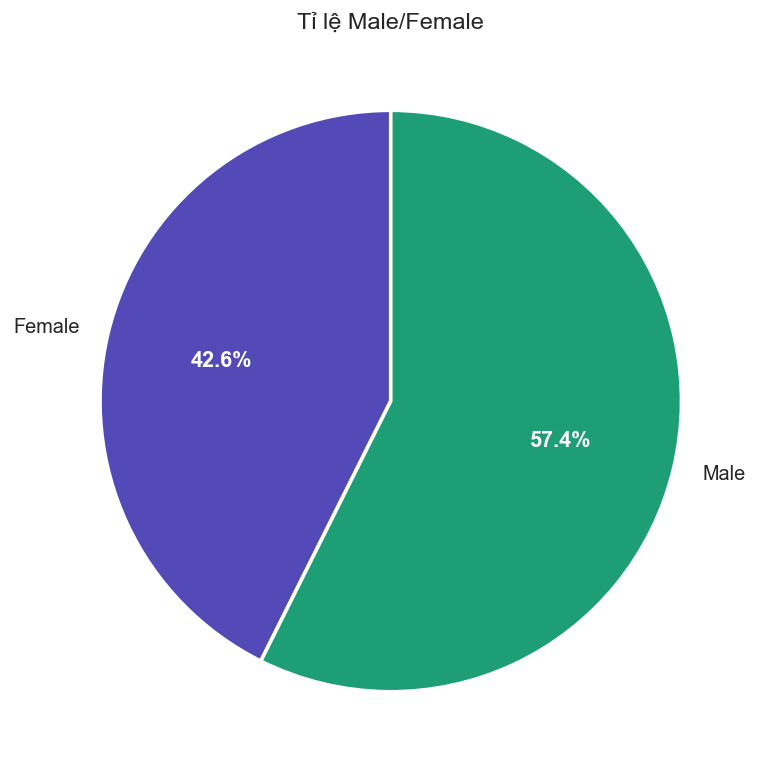

Đã lưu biểu đồ: c0_gender_pie.png


In [ ]:

# Lọc Cluster 0
c0 = df[df['cluster_kmeans'] == 0].copy()

# Hàm xử lý nếu dữ liệu là 0-1 hoặc 0-100
def smart_mean(series):
    s = series.dropna()
    if s.empty:
        return 0.0
    if s.max() > 1:
        return s.mean() / 100
    return s.mean()

# Lấy 2 cột giới tính
gender_cols = ['gender_Female', 'gender_Male']
gender_cols = [c for c in gender_cols if c in c0.columns]

# Tính tỉ lệ trung bình
gender_s = pd.Series({
    c: smart_mean(c0[c]) for c in gender_cols
})

# Chuẩn hóa để tổng Male + Female = 100%
gender_s = gender_s / gender_s.sum()

# Đổi nhãn cho đẹp
gender_labels = [
    c.replace('gender_', '') for c in gender_s.index
]

# Màu
gender_colors = ['#534AB7', '#1D9E75']

# Vẽ pie chart
fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    gender_s.values,
    labels=gender_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=gender_colors[:len(gender_s)],
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)

# Làm chữ phần trăm rõ hơn
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title(
    'Tỉ lệ Male/Female',
    fontsize=13,
    fontweight='500',
    pad=15
)

ax.axis('equal')

plt.tight_layout()
plt.show()


In [55]:

# # ================================================================
# # SECTION 5 — BẢNG TÓM TẮT NHANH (Summary table)
# # ================================================================

# print("\n" + "═" * 60)
# print("CLUSTER 0 — COMMERCIAL MATURE LEADERS: TÓM TẮT")
# print("═" * 60)
# print(f"  Tổng creator              : {len(c0):,}")
# print(f"  Follower trung vị         : {c0['followerCnt'].median():>12,.0f}")
# print(f"  Engagement rate trung vị  : {c0['engagementRate'].median():>12.4f}")
# if 'startingRate100k' in c0.columns:
#     print(f"  Starting rate trung vị    : {c0['startingRate100k'].median():>12,.0f}")
#     print(f"  Recommend rate trung vị   : {c0['recommendRate100k'].median():>12,.0f}")
# print()
# print("  Hành vi định giá:")
# for behavior, label in LABEL_MAP.items():
#     n   = (c0['pricing_behavior'] == behavior).sum()
#     pct = n / len(c0)
#     print(f"    {label:<30}: {n:>5,} ({pct:.1%})")

# # Top 15 creator theo commercialScore
# summary_cols = [c for c in ['handleName', 'followerCnt', 'engagementRate',
#                              'commercialScore', 'startingRate100k',
#                              'recommendRate100k', 'pricing_behavior',
#                              'follower_tier']
#                 if c in c0.columns]

# top15 = (
#     c0[summary_cols]
#     .sort_values('commercialScore', ascending=False)
#     .head(15)
#     .reset_index(drop=True)
# )
# print("\n═══ Top 15 creator theo commercialScore ═══")
# display(top15)

# # Top 10 creator chưa set giá nhưng commercial score cao (cơ hội!)
# no_set_opportunity = (
#     c0[c0['pricing_behavior'] == 'no_set'][summary_cols]
#     .sort_values('commercialScore', ascending=False)
#     .head(10)
#     .reset_index(drop=True)
# )
# print("\n═══ Top 10 creator chưa set giá nhưng commercialScore cao ═══")
# print("   → Đây là cơ hội tư vấn giá / tiếp cận hợp tác!")
# display(no_set_opportunity)

Số creator dùng để phân tích: 3,966
Số dòng sau khi mở rộng theo ngành: 4287
Các ngành được dùng: <ArrowStringArray>
['Beauty & Làm đẹp', 'Giáo dục', 'Giải trí', 'Ẩm thực', 'Thể thao']
Length: 5, dtype: str


,content_category,n_creator,avgSixSecondsViewsRate_median,avgSixSecondsViewsRate_mean,videoCompleteRate_median,videoCompleteRate_mean
0,Beauty & Làm đẹp,915,0.2929,0.2917,0.0623,0.0765
1,Giáo dục,169,0.4209,0.4152,0.0723,0.0859
2,Giải trí,2238,0.4370,0.4310,0.1178,0.1319
3,Thể thao,84,0.4365,0.3866,0.0873,0.1093
4,Ẩm thực,881,0.4225,0.3841,0.0577,0.0778


NameError: name 'mticker' is not defined

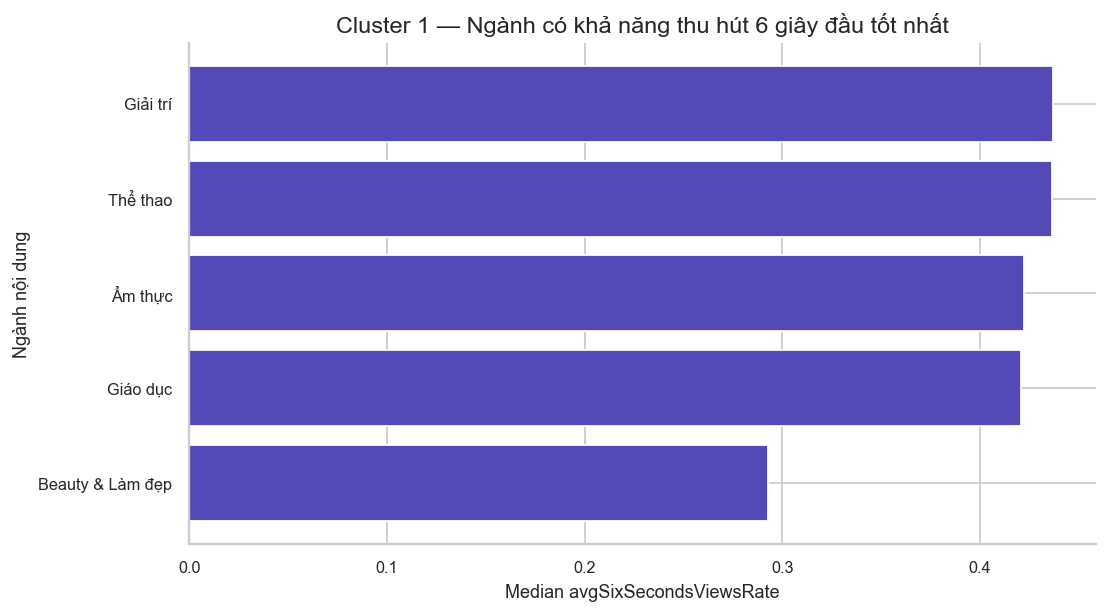

In [56]:
# ================================================================
# VISUAL ANALYSIS — CONTENT ATTRACTIVENESS, AUDIENCE PORTRAIT,
# AND ENGAGEMENT BY INDUSTRY
# ================================================================

# ================================================================
# 0. CONFIG
# ================================================================

# Nếu muốn phân tích toàn bộ dữ liệu, để:
# target_cluster = None

# Nếu muốn phân tích riêng một cụm, ví dụ cụm 1:
target_cluster = 1
cluster_col = 'cluster_kmeans'

df_plot = df.copy()

if target_cluster is not None:
    df_plot = df_plot[df_plot[cluster_col] == target_cluster].copy()
    title_prefix = f'Cluster {target_cluster}'
else:
    title_prefix = 'Toàn bộ dữ liệu'

print(f"Số creator dùng để phân tích: {len(df_plot):,}")

# Các ngành nội dung
CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
content_cols = [c for c in CONTENT_COLS if c in df_plot.columns]

CONTENT_LABEL = {
    'Beauty': 'Beauty & Làm đẹp',
    'Education': 'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food': 'Ẩm thực',
    'Sports': 'Thể thao'
}

# Màu cơ bản
CLR = {
    'purple': '#534AB7',
    'teal': '#1D9E75',
    'coral': '#D85A30',
    'amber': '#BA7517',
    'blue': '#185FA5',
    'gray': '#B4B2A9',
    'gray_dark': '#5F5E5A'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

# ================================================================
# 1. CHUYỂN DATA TỪ DẠNG WIDE SANG LONG THEO NGÀNH
# Một creator có thể thuộc nhiều ngành.
# Nếu Beauty = 1 và Food = 1 thì creator đó được tính vào cả 2 ngành.
# ================================================================

rows = []

for col in content_cols:
    sub = df_plot[df_plot[col].fillna(0) > 0].copy()
    sub['content_category'] = CONTENT_LABEL.get(col, col)
    sub['content_col'] = col
    rows.append(sub)

if len(rows) == 0:
    raise ValueError("Không tìm thấy cột ngành nội dung phù hợp.")

df_long = pd.concat(rows, ignore_index=True)

print("Số dòng sau khi mở rộng theo ngành:", len(df_long))
print("Các ngành được dùng:", df_long['content_category'].unique())


# ================================================================
# 2. NỘI DUNG THU HÚT NHẤT Ở NGÀNH NÀO?
# Dùng avgSixSecondsViewsRate và videoCompleteRate
# ================================================================

attraction_metrics = [
    'avgSixSecondsViewsRate',
    'videoCompleteRate'
]

available_attraction_metrics = [
    c for c in attraction_metrics if c in df_long.columns
]

industry_attraction = (
    df_long
    .groupby('content_category')
    .agg(
        n_creator=('handleName', 'count'),
        avgSixSecondsViewsRate_median=('avgSixSecondsViewsRate', 'median'),
        avgSixSecondsViewsRate_mean=('avgSixSecondsViewsRate', 'mean'),
        videoCompleteRate_median=('videoCompleteRate', 'median'),
        videoCompleteRate_mean=('videoCompleteRate', 'mean')
    )
    .reset_index()
)

display(industry_attraction.round(4))


# ----------------
# 2.1 Bar chart — avgSixSecondsViewsRate theo ngành
# ----------------

plot_df = industry_attraction.sort_values(
    'avgSixSecondsViewsRate_median',
    ascending=True
)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    plot_df['content_category'],
    plot_df['avgSixSecondsViewsRate_median'],
    color=CLR['purple']
)

plt.title(
    f'{title_prefix} — Ngành có khả năng thu hút 6 giây đầu tốt nhất',
    fontsize=13,
    fontweight='500'
)
plt.xlabel('Median avgSixSecondsViewsRate')
plt.ylabel('Ngành nội dung')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + plot_df['avgSixSecondsViewsRate_median'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.2%}',
        va='center',
        fontsize=9,
        color=CLR['gray_dark']
    )

plt.tight_layout()
plt.show()


# ----------------
# 2.2 Bar chart — videoCompleteRate theo ngành
# ----------------

plot_df = industry_attraction.sort_values(
    'videoCompleteRate_median',
    ascending=True
)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    plot_df['content_category'],
    plot_df['videoCompleteRate_median'],
    color=CLR['teal']
)

plt.title(
    f'{title_prefix} — Ngành giữ chân người xem tốt nhất',
    fontsize=13,
    fontweight='500'
)
plt.xlabel('Median videoCompleteRate')
plt.ylabel('Ngành nội dung')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + plot_df['videoCompleteRate_median'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.2%}',
        va='center',
        fontsize=9,
        color=CLR['gray_dark']
    )

plt.tight_layout()
plt.show()



# ----------------
# 4.1 Bar chart — engagementRate trung vị theo ngành
# ----------------

plot_df = industry_engagement.sort_values(
    'engagementRate_median',
    ascending=True
)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    plot_df['content_category'],
    plot_df['engagementRate_median'],
    color=CLR['coral']
)

plt.title(
    f'{title_prefix} — Ngành có creator tương tác tốt nhất',
    fontsize=13,
    fontweight='500'
)
plt.xlabel('Median engagementRate')
plt.ylabel('Ngành nội dung')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + plot_df['engagementRate_median'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.2%}',
        va='center',
        fontsize=9,
        color=CLR['gray_dark']
    )

plt.tight_layout()
plt.show()


# ----------------
# 4.2 Boxplot — phân bố engagementRate theo ngành
# ----------------

plt.figure(figsize=(10, 5.5))

sns.boxplot(
    data=df_long,
    x='content_category',
    y='engagementRate',
    showfliers=False
)

plt.title(
    f'{title_prefix} — Phân bố engagementRate theo ngành',
    fontsize=13,
    fontweight='500'
)
plt.xlabel('Ngành nội dung')
plt.ylabel('Engagement Rate')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


import matplotlib.gridspec as gridspec

# ------------------------------------------------
# Helper functions
# ------------------------------------------------

def smart_mean(s):
    """
    Tính mean an toàn.
    Ép dữ liệu về numeric để tránh lỗi nếu có string/null.
    """
    return pd.to_numeric(s, errors='coerce').mean()


def group_means(data, cols):
    """
    Tính tỷ lệ trung bình của từng nhóm cột và chuẩn hóa tổng = 1.
    Ví dụ:
    - gender_Female + gender_Male = 100%
    - age_13-17 + age_18-24 + ... = 100%
    """
    sub = {c: smart_mean(data[c]) for c in cols if c in data.columns}

    if not sub:
        return pd.Series(dtype=float)

    s = pd.Series(sub).dropna()
    total = s.sum()

    return (s / total) if total > 0 else s


def clean_label(col, prefix):
    """
    Làm sạch tên cột để hiển thị trên biểu đồ.
    """
    return col.replace(prefix, '').replace('_', ' ').strip()


# ------------------------------------------------
# Tách các nhóm audience columns
# ------------------------------------------------

aud_cols = [
    c for c in df_plot.columns
    if c.startswith(('active_', 'age_', 'device_', 'gender_', 'country_'))
]

active_cols = [c for c in aud_cols if c.startswith('active_')]
age_cols = [c for c in aud_cols if c.startswith('age_')]
device_cols = [c for c in aud_cols if c.startswith('device_')]
gender_cols = [c for c in aud_cols if c.startswith('gender_')]
country_cols = [c for c in aud_cols if c.startswith('country_')]

active_s = group_means(df_plot, active_cols)
age_s = group_means(df_plot, age_cols)
device_s = group_means(df_plot, device_cols)
gender_s = group_means(df_plot, gender_cols)
country_s = group_means(df_plot, country_cols).sort_values(ascending=False)


# ------------------------------------------------
# Sắp xếp độ tuổi đúng thứ tự
# ------------------------------------------------

AGE_ORDER = [
    'age_13-17',
    'age_18-24',
    'age_25-34',
    'age_35-44',
    'age_45-54',
    'age_55+',
    'age_Other'
]

age_ordered = age_s.reindex([a for a in AGE_ORDER if a in age_s.index])


# ------------------------------------------------
# Tạo dashboard
# ------------------------------------------------

fig = plt.figure(figsize=(15, 14))

fig.suptitle(
    f'{title_prefix} — Audience Dashboard',
    fontsize=14,
    fontweight='500',
    y=1.01
)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.5,
    wspace=0.35,
    height_ratios=[1, 1, 1.1]
)


# ================================================================
# [R1 C1] Active / Inactive — Donut
# ================================================================

ax_act = fig.add_subplot(gs[0, 0])

if len(active_s) >= 2:
    act_labels = [
        clean_label(c, 'active_').capitalize()
        for c in active_s.index
    ]

    act_clrs = [CLR['purple'], CLR['gray']]

    wedges, _ = ax_act.pie(
        active_s.values,
        colors=act_clrs[:len(active_s)],
        startangle=90,
        wedgeprops=dict(width=0.54, edgecolor='white', linewidth=2.5),
        counterclock=False
    )

    for i, (w, v) in enumerate(zip(wedges, active_s.values)):
        ang = (w.theta2 + w.theta1) / 2
        rad = 0.68
        x_pos = rad * np.cos(np.deg2rad(ang))
        y_pos = rad * np.sin(np.deg2rad(ang))

        ax_act.text(
            x_pos,
            y_pos,
            f'{v:.1%}',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='500',
            color='white' if i == 0 else CLR['gray_dark']
        )

    ax_act.legend(
        wedges,
        act_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.18),
        fontsize=9.5,
        frameon=False,
        ncol=2
    )

    ax_act.set_title(
        'Trạng thái hoạt động audience',
        fontsize=11,
        pad=10
    )

else:
    ax_act.text(
        0.5,
        0.5,
        'Không có dữ liệu active/inactive',
        ha='center',
        va='center',
        transform=ax_act.transAxes,
        color=CLR['gray_dark']
    )
    ax_act.axis('off')


# ================================================================
# [R1 C2] Gender — Donut
# ================================================================

ax_gen = fig.add_subplot(gs[0, 1])

if len(gender_s) >= 1:
    gen_labels = [
        clean_label(c, 'gender_')
        for c in gender_s.index
    ]

    gen_clrs = [CLR['purple'], CLR['teal'], CLR['gray']]

    wedges_g, _ = ax_gen.pie(
        gender_s.values,
        colors=gen_clrs[:len(gender_s)],
        startangle=90,
        wedgeprops=dict(width=0.54, edgecolor='white', linewidth=2.5),
        counterclock=False
    )

    for w, v in zip(wedges_g, gender_s.values):
        ang = (w.theta2 + w.theta1) / 2
        rad = 0.68

        ax_gen.text(
            rad * np.cos(np.deg2rad(ang)),
            rad * np.sin(np.deg2rad(ang)),
            f'{v:.1%}',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='500',
            color='white'
        )

    ax_gen.legend(
        wedges_g,
        gen_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.18),
        fontsize=9.5,
        frameon=False,
        ncol=2
    )

    ax_gen.set_title(
        'Giới tính audience',
        fontsize=11,
        pad=10
    )

else:
    ax_gen.text(
        0.5,
        0.5,
        'Không có dữ liệu giới tính',
        ha='center',
        va='center',
        transform=ax_gen.transAxes,
        color=CLR['gray_dark']
    )
    ax_gen.axis('off')


# ================================================================
# [R2 C1] Độ tuổi — Horizontal bar
# Màu đậm dần từ nhóm tuổi nhỏ đến lớn
# ================================================================

ax_age = fig.add_subplot(gs[1, 0])

if len(age_ordered) > 0:
    age_labels = [
        c.replace('age_', '')
        for c in age_ordered.index
    ]

    AGE_COLOR_MAP = {
        '13-17': '#DAD7FF',
        '18-24': '#B8B2F2',
        '25-34': '#8E86E3',
        '35-44': '#675ED0',
        '45-54': '#4F46B8',
        '55+': '#352E8F',
        'Other': '#B4B2A9'
    }

    age_clrs = [
        AGE_COLOR_MAP.get(lbl, CLR['gray'])
        for lbl in age_labels
    ]

    bars = ax_age.barh(
        range(len(age_ordered)),
        age_ordered.values,
        color=age_clrs,
        height=0.6,
        edgecolor='none'
    )

    ax_age.set_yticks(range(len(age_ordered)))
    ax_age.set_yticklabels(age_labels, fontsize=10)
    ax_age.set_xlabel('Tỉ lệ audience trung bình')
    ax_age.set_title('Phân bố độ tuổi audience', fontsize=11)
    ax_age.spines['left'].set_visible(False)
    ax_age.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}')
    )

    ax_age.set_xlim(0, age_ordered.max() * 1.35)

    for bar, v in zip(bars, age_ordered.values):
        ax_age.text(
            v + age_ordered.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.1%}',
            va='center',
            fontsize=9.5,
            fontweight='500',
            color=CLR['gray_dark']
        )

    dominant_age = age_ordered.idxmax().replace('age_', '')

    ax_age.text(
        0.98,
        0.03,
        f'Nhóm tuổi chủ đạo: {dominant_age}',
        ha='right',
        va='bottom',
        transform=ax_age.transAxes,
        fontsize=8.5,
        color=CLR['purple'],
        fontstyle='italic'
    )

else:
    ax_age.text(
        0.5,
        0.5,
        'Không có dữ liệu độ tuổi',
        ha='center',
        va='center',
        transform=ax_age.transAxes,
        color=CLR['gray_dark']
    )
    ax_age.axis('off')


# ================================================================
# [R2 C2] Thiết bị — Horizontal bar
# ================================================================

ax_dev = fig.add_subplot(gs[1, 1])

if len(device_s) > 0:
    dev_sorted = device_s.sort_values(ascending=True)

    dev_labels = [
        clean_label(c, 'device_')
        for c in dev_sorted.index
    ]

    BRAND_CLR = {
        'APPLE': '#555555',
        'SAMSUNG': '#1428A0',
        'OPPO': CLR['teal'],
        'XIAOMI': CLR['coral'],
        'VIVO': CLR['amber'],
        'Other': CLR['gray']
    }

    dev_clrs = [
        BRAND_CLR.get(l, CLR['gray_dark'])
        for l in dev_labels
    ]

    bars = ax_dev.barh(
        range(len(dev_sorted)),
        dev_sorted.values,
        color=dev_clrs,
        height=0.6,
        edgecolor='none'
    )

    ax_dev.set_yticks(range(len(dev_sorted)))
    ax_dev.set_yticklabels(dev_labels, fontsize=10)
    ax_dev.set_xlabel('Tỉ lệ audience trung bình')
    ax_dev.set_title('Thiết bị audience sử dụng', fontsize=11)
    ax_dev.spines['left'].set_visible(False)
    ax_dev.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}')
    )

    ax_dev.set_xlim(0, dev_sorted.max() * 1.35)

    for bar, v in zip(bars, dev_sorted.values):
        ax_dev.text(
            v + dev_sorted.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.1%}',
            va='center',
            fontsize=9.5,
            fontweight='500',
            color=CLR['gray_dark']
        )

else:
    ax_dev.text(
        0.5,
        0.5,
        'Không có dữ liệu thiết bị',
        ha='center',
        va='center',
        transform=ax_dev.transAxes,
        color=CLR['gray_dark']
    )
    ax_dev.axis('off')


# ================================================================
# [R3] Quốc gia — Horizontal bar full width, top 10
# ================================================================

ax_ctr = fig.add_subplot(gs[2, :])

if len(country_s) > 0:
    top_ctr = country_s.head(10).sort_values(ascending=True)

    ctr_labels = [
        c.replace('country_', '')
        for c in top_ctr.index
    ]

    ctr_clrs = [
        CLR['coral'] if l == 'VN' else CLR['purple']
        for l in ctr_labels
    ]

    alpha_vals = [
        1.0 if l == 'VN' else max(0.4, 1 - 0.06 * i)
        for i, l in enumerate(ctr_labels)
    ]

    bars = ax_ctr.barh(
        range(len(top_ctr)),
        top_ctr.values,
        color=ctr_clrs,
        height=0.65,
        edgecolor='none'
    )

    for bar, a in zip(bars, alpha_vals):
        bar.set_alpha(a)

    ax_ctr.set_yticks(range(len(top_ctr)))
    ax_ctr.set_yticklabels(ctr_labels, fontsize=10)
    ax_ctr.set_xlabel('Tỉ lệ audience trung bình')
    ax_ctr.set_title('Phân bố quốc gia audience, top 10', fontsize=11)
    ax_ctr.spines['left'].set_visible(False)
    ax_ctr.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.1%}')
    )

    ax_ctr.set_xlim(0, top_ctr.max() * 1.28)

    for bar, v, l in zip(bars, top_ctr.values, ctr_labels):
        ax_ctr.text(
            v + top_ctr.max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.1%}',
            va='center',
            fontsize=9.5,
            fontweight='500',
            color=CLR['gray_dark']
        )

    vn_pct = country_s.get('country_VN', 0)

    ax_ctr.text(
        0.98,
        0.05,
        f'Vietnam chiếm {vn_pct:.1%} audience trung bình',
        ha='right',
        va='bottom',
        transform=ax_ctr.transAxes,
        fontsize=9,
        color=CLR['coral'],
        fontstyle='italic'
    )

else:
    ax_ctr.text(
        0.5,
        0.5,
        'Không có dữ liệu quốc gia',
        ha='center',
        va='center',
        transform=ax_ctr.transAxes,
        color=CLR['gray_dark']
    )
    ax_ctr.axis('off')



,content_category,n_creator,followersGrowthRate_median,followersGrowthRate_mean,followersGrowthRate_p75,followersGrowthRate_p90
0,Giáo dục,192,0.0215,0.3800,0.0614,0.2814
1,Giải trí,2698,0.0107,32.7375,0.0481,0.1598
2,Thể thao,118,0.0087,0.0970,0.0380,0.1028
3,Ẩm thực,1114,0.0015,0.0465,0.0184,0.0733
4,Beauty & Làm đẹp,1448,-0.0008,0.0183,0.0071,0.0361


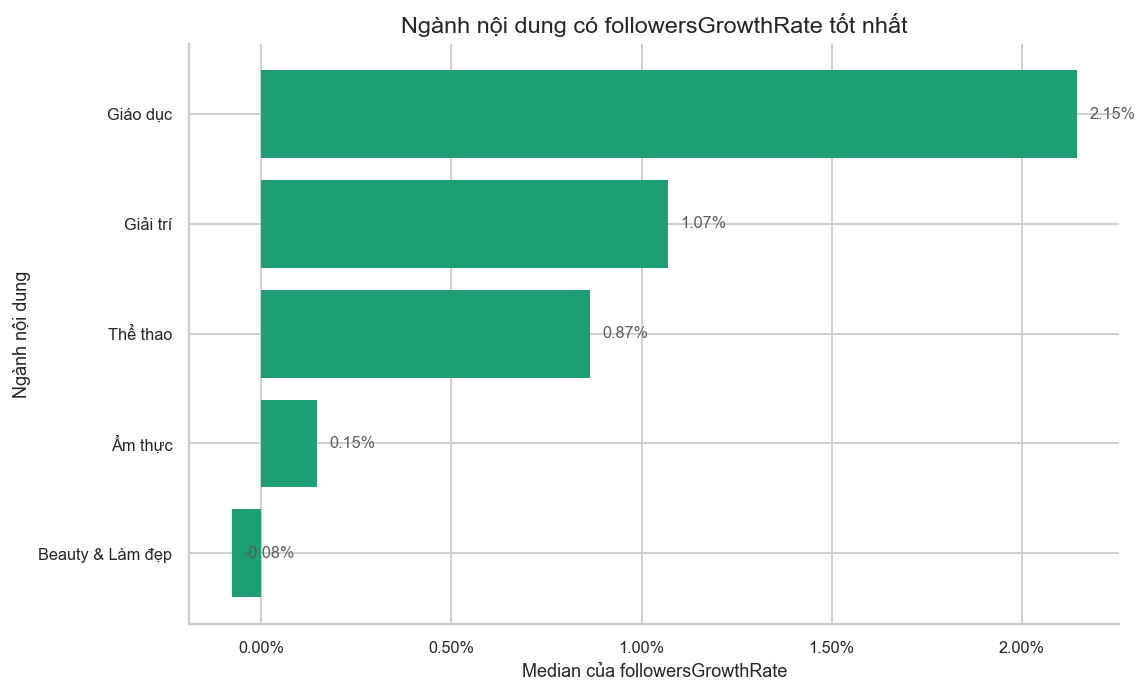

In [ ]:
# ================================================================
# NGÀNH NÀO CÓ followersGrowthRate TỐT NHẤT?
# Một creator có thể thuộc nhiều ngành
# ================================================================


# Nếu muốn xem toàn bộ dữ liệu
df_plot = df.copy()

# Nếu muốn xem riêng một cụm, mở 2 dòng dưới:
# target_cluster = 1
# df_plot = df[df['cluster_kmeans'] == target_cluster].copy()

CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']

CONTENT_LABEL = {
    'Beauty': 'Beauty & Làm đẹp',
    'Education': 'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food': 'Ẩm thực',
    'Sports': 'Thể thao'
}

CLR = {
    'purple': '#534AB7',
    'teal': '#1D9E75',
    'coral': '#D85A30',
    'amber': '#BA7517',
    'blue': '#185FA5',
    'gray_dark': '#5F5E5A'
}

content_cols = [c for c in CONTENT_COLS if c in df_plot.columns]

rows = []

for col in content_cols:
    sub = df_plot[df_plot[col].fillna(0) > 0].copy()

    rows.append({
        'content_category': CONTENT_LABEL.get(col, col),
        'n_creator': len(sub),
        'followersGrowthRate_median': sub['followersGrowthRate'].median(),
        'followersGrowthRate_mean': sub['followersGrowthRate'].mean(),
        'followersGrowthRate_p75': sub['followersGrowthRate'].quantile(0.75),
        'followersGrowthRate_p90': sub['followersGrowthRate'].quantile(0.90)
    })

industry_growth = (
    pd.DataFrame(rows)
    .sort_values('followersGrowthRate_median', ascending=False)
    .reset_index(drop=True)
)

display(industry_growth.round(4))


# ================================================================
# BAR CHART — followersGrowthRate trung vị theo ngành
# ================================================================

plot_df = industry_growth.sort_values(
    'followersGrowthRate_median',
    ascending=True
)

plt.figure(figsize=(9, 5.5))

bars = plt.barh(
    plot_df['content_category'],
    plot_df['followersGrowthRate_median'],
    color=CLR['teal'],
    edgecolor='none'
)

plt.title(
    'Ngành nội dung có followersGrowthRate tốt nhất',
    fontsize=13,
    fontweight='500'
)
plt.xlabel('Median của followersGrowthRate')
plt.ylabel('Ngành nội dung')

plt.gca().xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + plot_df['followersGrowthRate_median'].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.2%}',
        va='center',
        fontsize=9,
        color=CLR['gray_dark']
    )

plt.tight_layout()
plt.show()

CLUSTER 2 — Breakout Segment
Số creator trong cụm: 322

BURSTINESS_RECENT — CLUSTER 2 SO VỚI CÁC CỤM KHÁC


,cluster_kmeans,cluster_name,count,mean,median,std
0,0,Commercial Mature Leaders,788,-0.0384,-0.0310,0.1792
1,1,Mainstream Creator Base,3966,-0.0523,-0.0490,0.2135
2,2,Breakout Segment,322,-0.0100,-0.0042,0.2587
3,3,High-Engagement Micro-Niche,13,-0.0429,-0.0369,0.1781


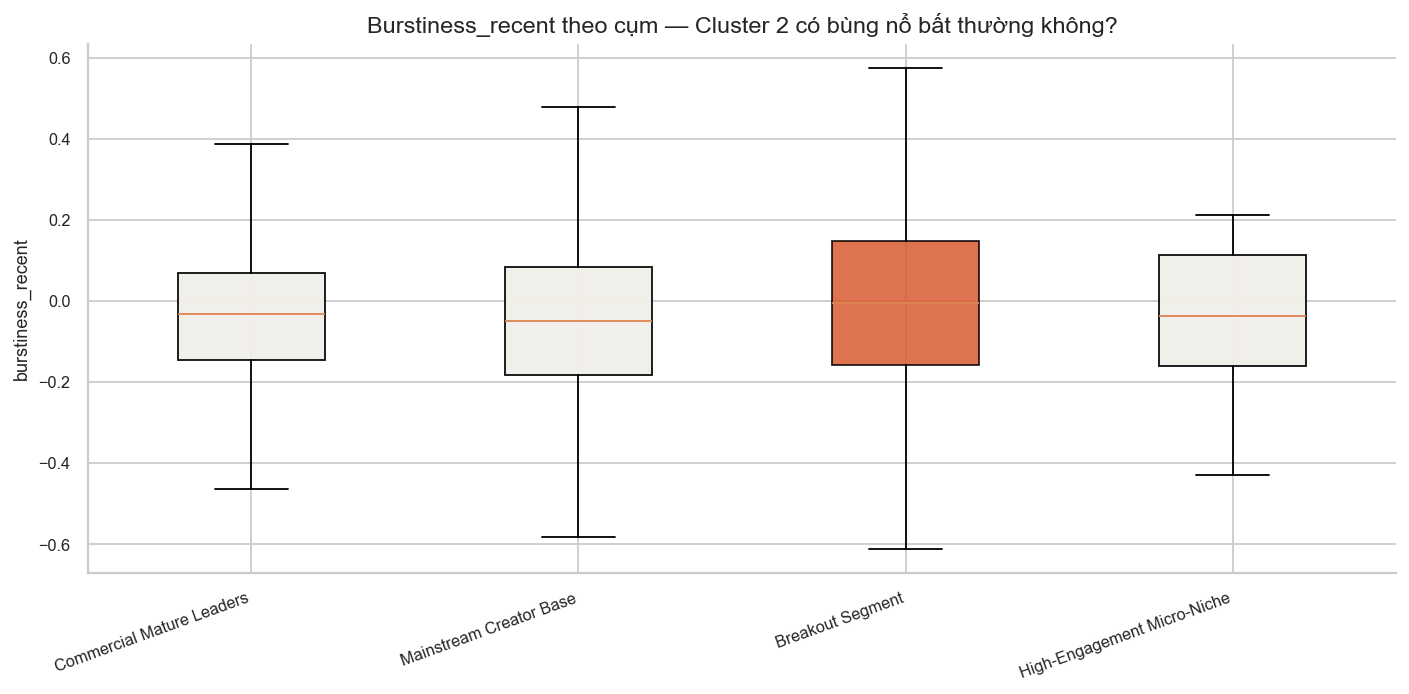


AVGSIXSECONDSVIEWSRATE — CLUSTER 2 CÓ CAO BẤT THƯỜNG KHÔNG?


,cluster_kmeans,cluster_name,count,mean,median,std
0,0,Commercial Mature Leaders,788,0.2617,0.2641,0.1866
1,1,Mainstream Creator Base,3966,0.3910,0.4133,0.1691
2,2,Breakout Segment,322,0.3894,0.4034,0.1621
3,3,High-Engagement Micro-Niche,13,0.4310,0.4106,0.0887


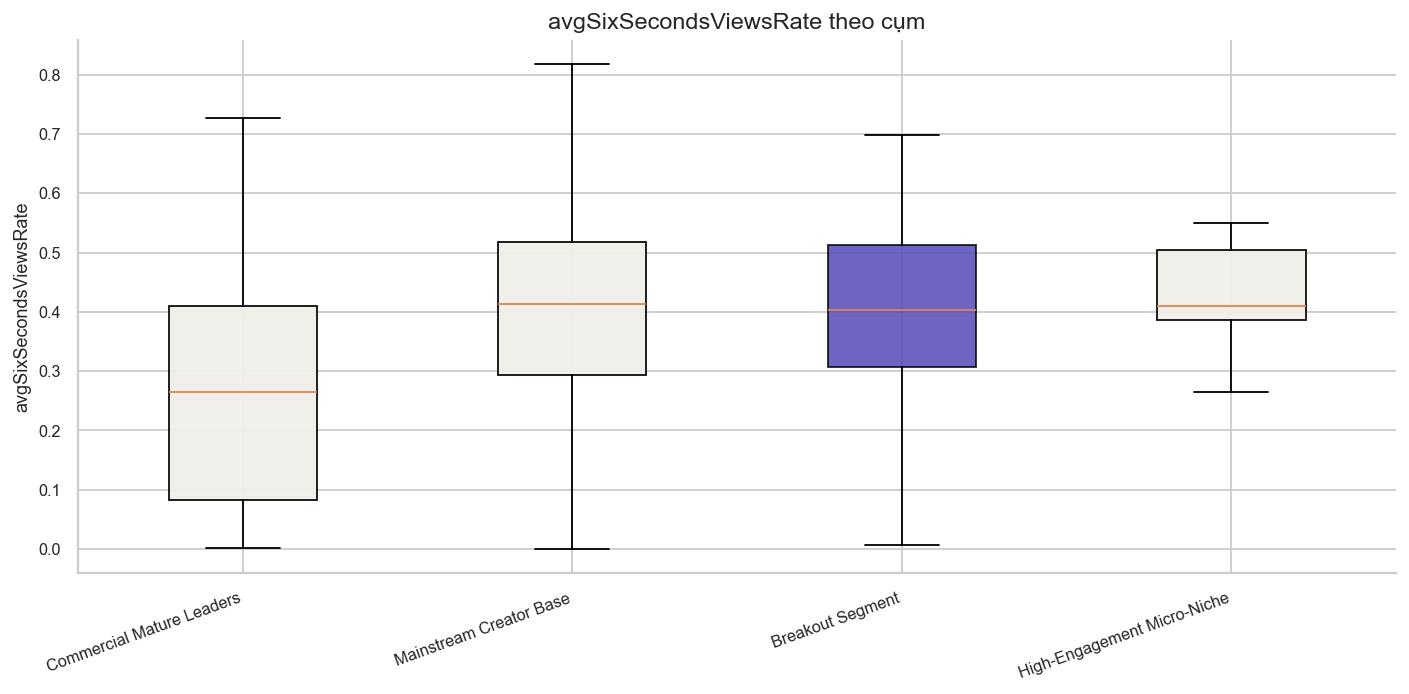


Ngưỡng top 10% avgSixSecondsViewsRate trong Cluster 2: 0.5824


,handleName,primary_content_label,followerCnt,avgSixSecondsViewsRate,avgSixSecondsViewsBenchMarkViews,lift_avg6s_views,median_view_recent,followersGrowthRate,burstiness_recent,viral_ratio,breakout_type
0,douyin_tyty,Beauty & Làm đẹp,309404,0.6983,0.4057,0.7212,1650617,-0.0024,0.2726,4.7139,Mixed / unclear
1,dorychang_03,Giải trí,11200886,0.6707,0.5200,0.2898,5427038,0.0079,-0.4269,4.0691,Mixed / unclear
2,timhieuma,Giải trí,133838,0.6689,0.4057,0.6488,8352,0.1544,0.4322,1.7173,Follower-growth only
3,chenyunyun89,Ẩm thực,984862,0.6675,0.4642,0.4380,41562,0.0019,-0.1458,26.1604,Mixed / unclear
4,thayhuykiddance,Giải trí,1189439,0.6674,0.4604,0.4496,31041,0.0389,-0.2873,40.4063,Mixed / unclear
5,khanhngan2959,Beauty & Làm đẹp,18351,0.6614,0.4431,0.4927,7722,0.1459,0.1741,55.2881,Follower-growth only
6,lopnhaythayhuy,Giải trí,357582,0.6610,0.4057,0.6293,26517,0.1679,-0.5090,195.1425,Follower-growth only
7,.phatphapvobien,Giải trí,141576,0.6585,0.4054,0.6243,3004,0.5850,0.0545,6.6489,Follower-growth only
8,hcc76400,Giải trí,136454,0.6510,0.4057,0.6046,177306,0.2570,-0.1296,17.4285,Mixed / unclear
9,tiktokdouyin086,Giải trí,53335,0.6436,0.4431,0.4525,25243,0.0232,-0.1709,51.3475,Mixed / unclear



CONTENT CATEGORY CỦA CLUSTER 2


,content_category,pct_creator
0,Giải trí,0.704969
1,Beauty & Làm đẹp,0.192547
2,Ẩm thực,0.142857
3,Thể thao,0.040373
4,Giáo dục,0.006211


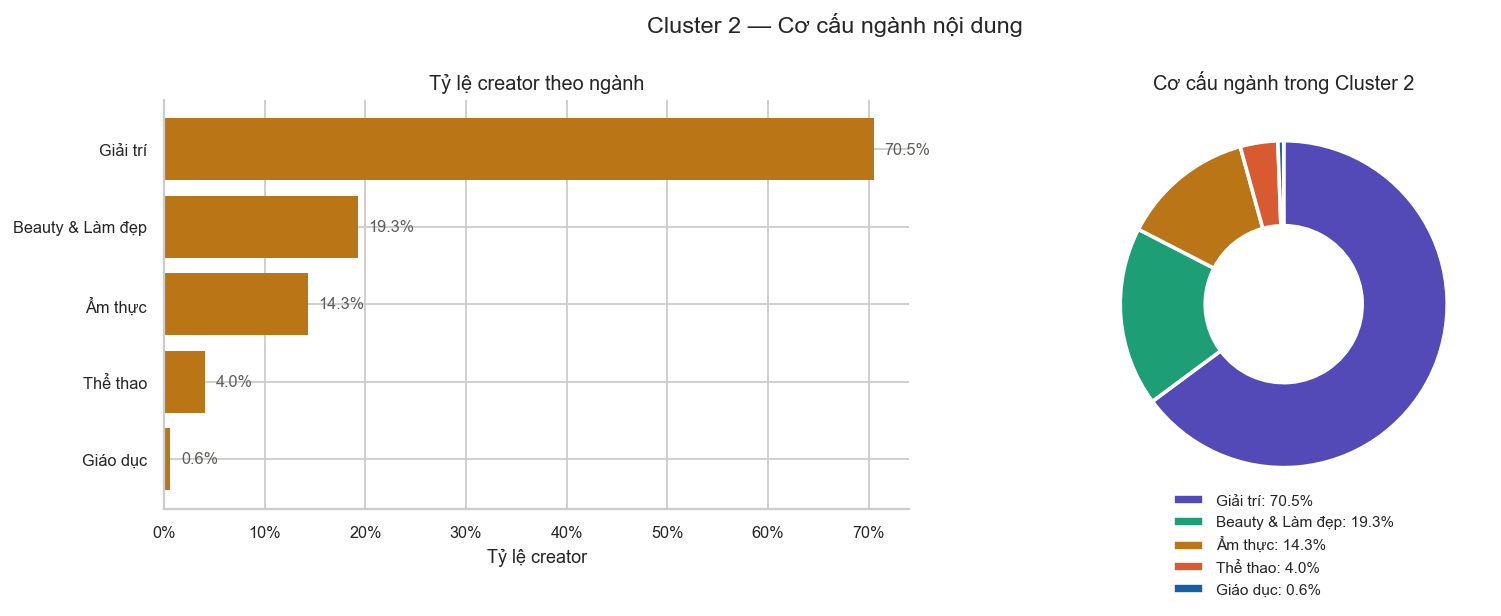

In [ ]:
# ================================================================
# CLUSTER 2 — BREAKOUT SEGMENT: DEEP DIVE ANALYSIS
# Mục tiêu:
# 1. burstiness_recent của Cluster 2 ở mức nào so với cụm khác?
# 2. Có viral video đơn lẻ hay tăng trưởng đều cả kênh?
# 3. lift_median_views so với benchmark ra sao?
# 4. avgSixSecondsViewsRate có cao bất thường không?
# 5. Họ làm content gì?
# 6. Hành vi đăng tải gần đây thế nào?
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ================================================================
# 0. CONFIG
# ================================================================

cluster_col = 'cluster_kmeans'
target_cluster = 2
target_cluster_name = 'Breakout Segment'

df = df.copy()

c2 = df[df[cluster_col] == target_cluster].copy()

print("=" * 80)
print(f"CLUSTER {target_cluster} — {target_cluster_name}")
print("=" * 80)
print(f"Số creator trong cụm: {len(c2):,}")

CLR = {
    'purple':       '#534AB7',
    'purple_mid':   '#7F77DD',
    'purple_light': '#EEEDFE',
    'coral':        '#D85A30',
    'coral_light':  '#FAECE7',
    'amber':        '#BA7517',
    'amber_light':  '#FAEEDA',
    'teal':         '#1D9E75',
    'teal_light':   '#E1F5EE',
    'blue':         '#185FA5',
    'blue_light':   '#E6F1FB',
    'green':        '#3B6D11',
    'green_light':  '#EAF3DE',
    'gray':         '#B4B2A9',
    'gray_dark':    '#5F5E5A',
    'gray_light':   '#F1EFE8',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
content_cols = [c for c in CONTENT_COLS if c in df.columns]

CONTENT_LABEL = {
    'Beauty':        'Beauty & Làm đẹp',
    'Education':     'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food':          'Ẩm thực',
    'Sports':        'Thể thao',
}

cluster_name_map = {
    0: 'Commercial Mature Leaders',
    1: 'Mainstream Creator Base',
    2: 'Breakout Segment',
    3: 'High-Engagement Micro-Niche'
}

df['cluster_name'] = df[cluster_col].map(cluster_name_map).fillna(df[cluster_col].astype(str))
c2['cluster_name'] = target_cluster_name


# ================================================================
# 1. HELPER FUNCTIONS
# ================================================================

def safe_q(s, q):
    s = pd.to_numeric(s, errors='coerce').dropna()
    if len(s) == 0:
        return np.nan
    return s.quantile(q)


def safe_divide(a, b, eps=1e-9):
    return a / (b + eps)


def format_number_cols(df_sub):
    out = df_sub.copy()

    int_cols = [
        'followerCnt',
        'medianViews',
        'median_view_recent',
        'max_view_recent',
        'total_views_recent',
        'total_hearts_recent',
        'total_comments_recent',
        'startingRate100k',
        'recommendRate100k'
    ]

    float_cols = [
        'followersGrowthRate',
        'avgSixSecondsViewsRate',
        'videoCompleteRate',
        'engagementRate',
        'cov_view_recent',
        'burstiness_recent',
        'recency_days_recent',
        'viral_ratio',
        'lift_median_views',
        'lift_avg6s_views',
        'breakout_score',
        'sustained_growth_score'
    ]

    for col in int_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce').round(0).astype('Int64')

    for col in float_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce').round(4)

    return out


def add_primary_content(df_sub, content_cols):
    df_sub = df_sub.copy()

    if not content_cols:
        df_sub['primary_content'] = 'Unknown'
        df_sub['primary_content_label'] = 'Unknown'
        return df_sub

    content_values = df_sub[content_cols].fillna(0)
    df_sub['primary_content'] = content_values.idxmax(axis=1)

    no_content_mask = content_values.sum(axis=1) == 0
    df_sub.loc[no_content_mask, 'primary_content'] = 'Unknown'

    df_sub['primary_content_label'] = (
        df_sub['primary_content']
        .map(CONTENT_LABEL)
        .fillna(df_sub['primary_content'])
    )

    return df_sub


c2 = add_primary_content(c2, content_cols)


# ================================================================
# 2. TẠO CÁC BIẾN PHÂN TÍCH CHO BREAKOUT
# ================================================================

# 2.1 Viral ratio:
# max_view_recent / median_view_recent càng cao thì càng nghiêng về 1 video viral đơn lẻ
if {'max_view_recent', 'median_view_recent'}.issubset(df.columns):
    df['viral_ratio'] = safe_divide(df['max_view_recent'], df['median_view_recent'])
    c2['viral_ratio'] = safe_divide(c2['max_view_recent'], c2['median_view_recent'])
else:
    print("Thiếu max_view_recent hoặc median_view_recent để tính viral_ratio.")

# 2.2 Lift median views so với benchmark
if {'median_view_recent', 'medianBenchMarkViews'}.issubset(df.columns):
    df['lift_median_views'] = safe_divide(
        df['median_view_recent'] - df['medianBenchMarkViews'],
        df['medianBenchMarkViews']
    )

    c2['lift_median_views'] = safe_divide(
        c2['median_view_recent'] - c2['medianBenchMarkViews'],
        c2['medianBenchMarkViews']
    )
else:
    print("Thiếu median_view_recent hoặc medianBenchMarkViews để tính lift_median_views.")

# 2.3 Lift avg six-second views so với benchmark
if {'avgSixSecondsViewsRate', 'avgSixSecondsViewsBenchMarkViews'}.issubset(df.columns):
    df['lift_avg6s_views'] = safe_divide(
        df['avgSixSecondsViewsRate'] - df['avgSixSecondsViewsBenchMarkViews'],
        df['avgSixSecondsViewsBenchMarkViews']
    )

    c2['lift_avg6s_views'] = safe_divide(
        c2['avgSixSecondsViewsRate'] - c2['avgSixSecondsViewsBenchMarkViews'],
        c2['avgSixSecondsViewsBenchMarkViews']
    )
else:
    print("Thiếu avgSixSecondsViewsRate hoặc avgSixSecondsViewsBenchMarkViews để tính lift_avg6s_views.")

# 2.4 Proxy hành vi đăng tải:
# Dữ liệu hiện có không có số video trước/sau bùng nổ.
# recency_days_recent thấp = gần đây còn đăng.
# total_views_recent cao + recency thấp = đang còn active và có lực kéo gần đây.
if 'recency_days_recent' in c2.columns:
    c2['posting_activity_proxy'] = np.where(
        c2['recency_days_recent'] <= safe_q(c2['recency_days_recent'], 0.25),
        'Very recent activity',
        np.where(
            c2['recency_days_recent'] <= safe_q(c2['recency_days_recent'], 0.50),
            'Recent activity',
            'Less recent activity'
        )
    )

# 2.5 Phân loại kiểu breakout
# Viral-led: max view rất cao so với median, burstiness cao
# Sustained breakout: growth cao, median view cao, burstiness không quá cao
required_breakout_cols = [
    'followersGrowthRate',
    'median_view_recent',
    'burstiness_recent',
    'cov_view_recent',
    'viral_ratio'
]

if all(c in c2.columns for c in required_breakout_cols):
    growth_p75_c2 = safe_q(c2['followersGrowthRate'], 0.75)
    median_view_p75_c2 = safe_q(c2['median_view_recent'], 0.75)
    burst_p75_c2 = safe_q(c2['burstiness_recent'], 0.75)
    viral_ratio_p75_c2 = safe_q(c2['viral_ratio'], 0.75)
    cov_p50_c2 = safe_q(c2['cov_view_recent'], 0.50)

    c2['breakout_type'] = 'Mixed / unclear'

    c2.loc[
        (c2['viral_ratio'] >= viral_ratio_p75_c2) &
        (c2['burstiness_recent'] >= burst_p75_c2),
        'breakout_type'
    ] = 'Viral-led breakout'

    c2.loc[
        (c2['followersGrowthRate'] >= growth_p75_c2) &
        (c2['median_view_recent'] >= median_view_p75_c2) &
        (c2['burstiness_recent'] < burst_p75_c2) &
        (c2['cov_view_recent'] <= cov_p50_c2),
        'breakout_type'
    ] = 'Sustained breakout'

    c2.loc[
        (c2['followersGrowthRate'] >= growth_p75_c2) &
        (c2['median_view_recent'] < median_view_p75_c2),
        'breakout_type'
    ] = 'Follower-growth only'

else:
    print("Không đủ cột để phân loại breakout_type.")


# ================================================================
# 3. BURSTINESS_RECENT CỦA CLUSTER 2 SO VỚI CỤM KHÁC
# ================================================================

print("\n" + "=" * 80)
print("BURSTINESS_RECENT — CLUSTER 2 SO VỚI CÁC CỤM KHÁC")
print("=" * 80)

burst_summary = (
    df.groupby([cluster_col, 'cluster_name'])['burstiness_recent']
      .agg(['count', 'mean', 'median', 'std'])
      .reset_index()
      .sort_values(cluster_col)
)

display(burst_summary.round(4))

plt.figure(figsize=(11, 5.5))

cluster_order = sorted(df[cluster_col].dropna().unique())
box_data = [
    df.loc[df[cluster_col] == cl, 'burstiness_recent'].dropna()
    for cl in cluster_order
]

box_labels = [
    cluster_name_map.get(cl, str(cl))
    for cl in cluster_order
]

box = plt.boxplot(
    box_data,
    labels=box_labels,
    showfliers=False,
    patch_artist=True
)

for i, patch in enumerate(box['boxes']):
    if cluster_order[i] == target_cluster:
        patch.set_facecolor(CLR['coral'])
        patch.set_alpha(0.85)
    else:
        patch.set_facecolor(CLR['gray_light'])
        patch.set_alpha(0.95)

plt.xticks(rotation=20, ha='right')
plt.title('Burstiness_recent theo cụm — Cluster 2 có bùng nổ bất thường không?', fontsize=13, fontweight='500')
plt.ylabel('burstiness_recent')
plt.tight_layout()
plt.show()



# ================================================================
# 6. AVGSIXSECONDSVIEWSRATE CÓ CAO BẤT THƯỜNG KHÔNG?
# ================================================================

print("\n" + "=" * 80)
print("AVGSIXSECONDSVIEWSRATE — CLUSTER 2 CÓ CAO BẤT THƯỜNG KHÔNG?")
print("=" * 80)

if 'avgSixSecondsViewsRate' in df.columns:
    avg6s_summary = (
        df.groupby([cluster_col, 'cluster_name'])['avgSixSecondsViewsRate']
          .agg(['count', 'mean', 'median', 'std'])
          .reset_index()
          .sort_values(cluster_col)
    )

    display(avg6s_summary.round(4))

    plt.figure(figsize=(11, 5.5))

    avg6s_data = [
        df.loc[df[cluster_col] == cl, 'avgSixSecondsViewsRate'].dropna()
        for cl in cluster_order
    ]

    box = plt.boxplot(
        avg6s_data,
        labels=box_labels,
        showfliers=False,
        patch_artist=True
    )

    for i, patch in enumerate(box['boxes']):
        if cluster_order[i] == target_cluster:
            patch.set_facecolor(CLR['purple'])
            patch.set_alpha(0.85)
        else:
            patch.set_facecolor(CLR['gray_light'])
            patch.set_alpha(0.95)

    plt.xticks(rotation=20, ha='right')
    plt.title('avgSixSecondsViewsRate theo cụm', fontsize=13, fontweight='500')
    plt.ylabel('avgSixSecondsViewsRate')
    plt.tight_layout()
    plt.show()

    avg6s_p90_c2 = safe_q(c2['avgSixSecondsViewsRate'], 0.90)

    top_avg6s = (
        c2[c2['avgSixSecondsViewsRate'] >= avg6s_p90_c2]
        .sort_values('avgSixSecondsViewsRate', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    avg6s_cols = [
        'handleName',
        'primary_content_label',
        'followerCnt',
        'avgSixSecondsViewsRate',
        'avgSixSecondsViewsBenchMarkViews',
        'lift_avg6s_views',
        'median_view_recent',
        'followersGrowthRate',
        'burstiness_recent',
        'viral_ratio',
        'breakout_type'
    ]

    avg6s_cols = [c for c in avg6s_cols if c in top_avg6s.columns]

    print(f"\nNgưỡng top 10% avgSixSecondsViewsRate trong Cluster 2: {avg6s_p90_c2:.4f}")
    display(format_number_cols(top_avg6s[avg6s_cols]))

else:
    print("Không có cột avgSixSecondsViewsRate.")


# ================================================================
# 7. HỌ LÀM VỀ CONTENT GÌ?
# ================================================================

print("\n" + "=" * 80)
print("CONTENT CATEGORY CỦA CLUSTER 2")
print("=" * 80)

if content_cols:
    content_rate_c2 = (
        c2[content_cols]
        .fillna(0)
        .mean()
        .sort_values(ascending=False)
    )

    content_rate_c2.index = [
        CONTENT_LABEL.get(c, c)
        for c in content_rate_c2.index
    ]

    display(
        content_rate_c2
        .rename('pct_creator')
        .reset_index()
        .rename(columns={'index': 'content_category'})
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Cluster 2 — Cơ cấu ngành nội dung', fontsize=13, fontweight='500')

    # Bar
    ax = axes[0]
    bars = ax.barh(
        content_rate_c2.index[::-1],
        content_rate_c2.values[::-1],
        color=CLR['amber'],
        edgecolor='none'
    )

    ax.set_title('Tỷ lệ creator theo ngành', fontsize=11)
    ax.set_xlabel('Tỷ lệ creator')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + content_rate_c2.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{w:.1%}',
            va='center',
            fontsize=9,
            color=CLR['gray_dark']
        )

    # Donut
    ax2 = axes[1]
    wedges, _ = ax2.pie(
        content_rate_c2.values,
        startangle=90,
        counterclock=False,
        colors=[CLR['purple'], CLR['teal'], CLR['amber'], CLR['coral'], CLR['blue']][:len(content_rate_c2)],
        wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
    )

    ax2.set_title('Cơ cấu ngành trong Cluster 2', fontsize=11)
    ax2.legend(
        wedges,
        [f'{idx}: {val:.1%}' for idx, val in content_rate_c2.items()],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=1,
        frameon=False,
        fontsize=8.5
    )

    plt.tight_layout()
    plt.show()

else:
    print("Không có cột content one-hot.")



CLUSTER 2 — Breakout Segment
Số creator trong Cluster 2: 322

IQR THRESHOLD — followersGrowthRate
Q1                    : -0.001606 (-0.16%)
Median / Q2           : 0.010198 (1.02%)
Q3                    : 0.053584 (5.36%)
IQR = Q3 - Q1         : 0.055190
Lower bound           : -0.084390 (-8.44%)
Upper bound           : 0.136368 (13.64%)

NHÓM CREATOR VƯỢT NGƯỠNG IQR
Số creator vượt upper bound IQR : 44
Tỷ lệ trong Cluster 2           : 13.66%

DANH SÁCH CREATOR VƯỢT NGƯỠNG IQR — SẮP XẾP THEO followersGrowthRate


,handleName,primary_content_label,followerCnt,followersGrowthRate,engagementRate,medianViews,median_view_recent,max_view_recent,viral_ratio,cov_view_recent,burstiness_recent,recency_days_recent,avgSixSecondsViewsRate,videoCompleteRate,lift_median_views,lift_avg6s_views,commercialScore,startingRate100k,recommendRate100k
0,chau.moe2k5,Giải trí,42571,42037.0000,0.0888,35802.0,39621.0,1120257.0,28.2743,1.8001,0.3351,2.3926,0.3774,0.1198,31.9626,-0.1483,60.0,20000000000,16000000000
1,thienannee,Giải trí,57791,287.9550,0.1065,21257.0,32982.0,1302833.0,39.5013,2.3761,-0.1573,23.8237,0.3765,0.1381,26.4393,-0.1503,60.0,0,0
2,thuybi_cute,Giải trí,75002,98.1726,0.1400,46446.0,14338.0,1236676.0,86.2516,2.6656,-0.3806,1.6079,0.3533,0.1252,10.9285,-0.2027,60.0,0,16000000000
3,.vn.thng.hanfu,Giải trí,43621,7.0744,0.1021,13373.0,15887.5,107508.0,6.7668,1.0980,-0.3104,0.0447,0.4142,0.2906,12.2176,-0.0652,60.0,10000000000,16000000000
4,titnhi._007,Giải trí,33620,4.5382,0.1020,24213.0,11218.0,1362982.0,121.4996,2.6623,-0.3972,2.4569,0.3833,0.1589,8.3328,-0.1350,60.0,0,16000000000
5,mochi181995,Giải trí,22840,4.0797,0.0289,2983.0,2797.5,93534.0,33.4349,2.0723,0.0198,1.4845,0.5591,0.1915,1.3293,0.2618,60.0,25000000000,16000000000
6,sm.healthy.ai,Giải trí,66948,1.6824,0.0512,55188.0,972893.0,9106132.0,9.3598,1.3113,0.5143,33.3124,0.4282,0.1759,809.0691,-0.0336,60.0,0,16000000000
7,pupham20.03,Giải trí,44461,1.3071,0.1112,13226.0,25506.0,768924.0,30.1468,2.4472,0.3248,1.4684,0.3919,0.1499,20.2196,-0.1155,60.0,0,16000000000
8,happychinese_k7,Giáo dục,29121,0.7605,0.0889,69602.0,75942.0,311670.0,4.1041,0.9753,0.0266,19.4889,0.3979,0.0434,62.2323,-0.1020,60.0,20000000000,68664813926
9,muonbuoi2099,Giải trí,76811,0.6059,0.0946,18566.0,34861.0,336317.0,9.6474,1.5081,-0.0074,2.5140,0.3361,0.1069,28.0025,-0.2415,60.0,50000000000,16000000000



SO SÁNH IQR OUTLIERS VỚI PHẦN CÒN LẠI


,group,n_creator,pct_cluster_2,followerCnt_mean,followerCnt_median,followersGrowthRate_mean,followersGrowthRate_median,engagementRate_mean,engagementRate_median,medianViews_mean,...,lift_median_views_mean,lift_median_views_median,lift_avg6s_views_mean,lift_avg6s_views_median,commercialScore_mean,commercialScore_median,startingRate100k_mean,startingRate100k_median,recommendRate100k_mean,recommendRate100k_median
0,IQR growth outliers,44,0.1366,114366.1591,75906.5,964.8294,0.2871,0.0671,0.0596,31573.7500,...,44.5168,6.8812,0.0391,-0.0910,60.7273,60.0,2.309164e+12,0.0,8.685845e+10,3.873233e+10
1,Rest of Cluster 2,278,0.8634,529394.5935,286341.5,0.0197,0.0045,0.0563,0.0478,105099.6475,...,6.9046,1.6432,-0.1089,-0.0775,62.6561,60.0,1.343771e+11,0.0,3.626088e+11,7.827312e+10



CONTENT CATEGORY CỦA NHÓM VƯỢT IQR


,content_category,iqr_outlier_pct,rest_cluster2_pct,diff
0,Giải trí,0.8409,0.6835,0.1575
1,Ẩm thực,0.0909,0.1511,-0.0602
2,Beauty & Làm đẹp,0.0682,0.2122,-0.1440
3,Giáo dục,0.0227,0.0036,0.0191
4,Thể thao,0.0227,0.0432,-0.0204


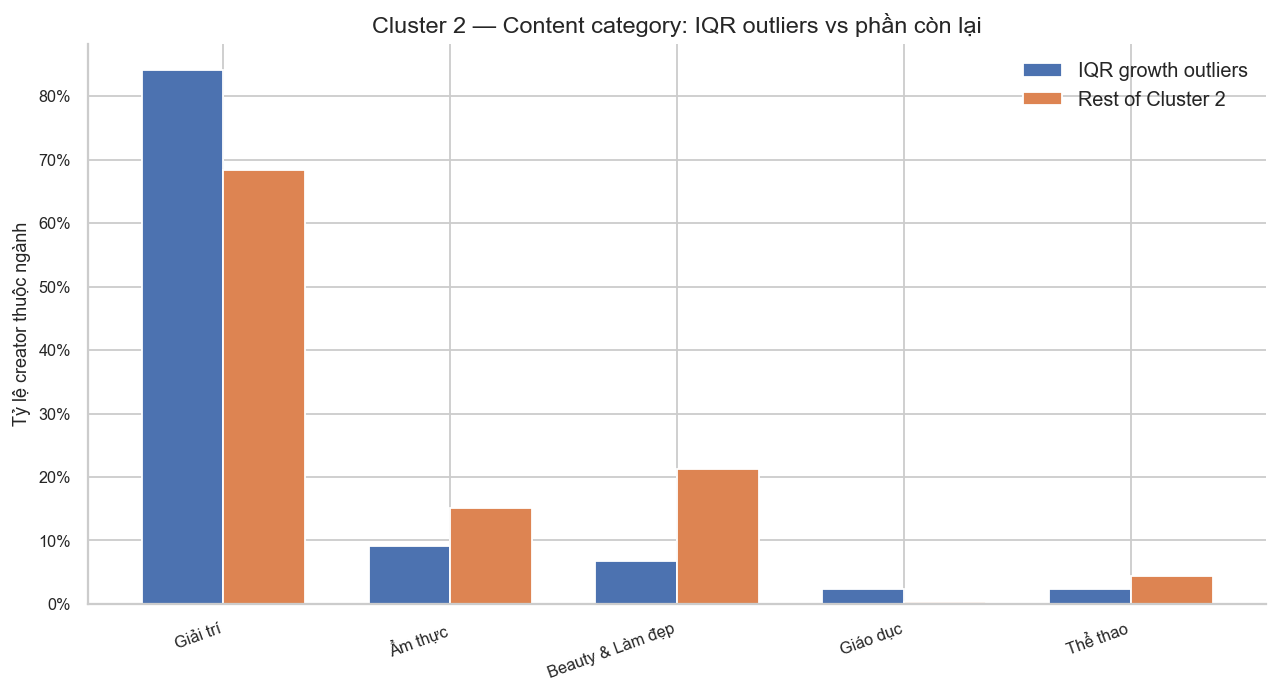

In [ ]:
# ================================================================
# CLUSTER 2 — CREATOR VƯỢT NGƯỠNG IQR CỦA followersGrowthRate
# Mục tiêu:
# - Tìm creator có followersGrowthRate cực cao theo quy tắc IQR
# - So sánh nhóm outlier với phần còn lại của Cluster 2
# - Xem họ thuộc content nào
# - Kiểm tra tăng trưởng đến từ viral đơn lẻ hay tăng đều
# ================================================================



# =========================
# 0. CONFIG
# =========================

cluster_col = 'cluster_kmeans'
target_cluster = 2
target_cluster_name = 'Breakout Segment'

df = df.copy()
c2 = df[df[cluster_col] == target_cluster].copy()

CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
content_cols = [c for c in CONTENT_COLS if c in c2.columns]

CONTENT_LABEL = {
    'Beauty':        'Beauty & Làm đẹp',
    'Education':     'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food':          'Ẩm thực',
    'Sports':        'Thể thao',
}

print("=" * 80)
print(f"CLUSTER {target_cluster} — {target_cluster_name}")
print("=" * 80)
print(f"Số creator trong Cluster 2: {len(c2):,}")


# =========================
# 1. TÍNH NGƯỠNG IQR
# =========================

growth = pd.to_numeric(c2['followersGrowthRate'], errors='coerce').dropna()

q1 = growth.quantile(0.25)
q2 = growth.quantile(0.50)
q3 = growth.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("\n" + "=" * 80)
print("IQR THRESHOLD — followersGrowthRate")
print("=" * 80)
print(f"Q1                    : {q1:.6f} ({q1:.2%})")
print(f"Median / Q2           : {q2:.6f} ({q2:.2%})")
print(f"Q3                    : {q3:.6f} ({q3:.2%})")
print(f"IQR = Q3 - Q1         : {iqr:.6f}")
print(f"Lower bound           : {lower_bound:.6f} ({lower_bound:.2%})")
print(f"Upper bound           : {upper_bound:.6f} ({upper_bound:.2%})")

# Nhóm vượt IQR
c2_iqr_outlier = c2[c2['followersGrowthRate'] > upper_bound].copy()
c2_non_outlier = c2[c2['followersGrowthRate'] <= upper_bound].copy()

print("\n" + "=" * 80)
print("NHÓM CREATOR VƯỢT NGƯỠNG IQR")
print("=" * 80)
print(f"Số creator vượt upper bound IQR : {len(c2_iqr_outlier):,}")
print(f"Tỷ lệ trong Cluster 2           : {len(c2_iqr_outlier) / len(c2):.2%}")


# =========================
# 2. TẠO BIẾN PHỤ ĐỂ PHÂN TÍCH
# =========================

def safe_divide(a, b, eps=1e-9):
    return a / (b + eps)


# viral_ratio = max_view_recent / median_view_recent
# Cao bất thường => có khả năng tăng trưởng do một video viral đơn lẻ
for data in [c2_iqr_outlier, c2_non_outlier]:
    if {'max_view_recent', 'median_view_recent'}.issubset(data.columns):
        data['viral_ratio'] = safe_divide(
            data['max_view_recent'],
            data['median_view_recent']
        )

    if {'median_view_recent', 'medianBenchMarkViews'}.issubset(data.columns):
        data['lift_median_views'] = safe_divide(
            data['median_view_recent'] - data['medianBenchMarkViews'],
            data['medianBenchMarkViews']
        )

    if {'avgSixSecondsViewsRate', 'avgSixSecondsViewsBenchMarkViews'}.issubset(data.columns):
        data['lift_avg6s_views'] = safe_divide(
            data['avgSixSecondsViewsRate'] - data['avgSixSecondsViewsBenchMarkViews'],
            data['avgSixSecondsViewsBenchMarkViews']
        )


# Gán content chính
def add_primary_content(data, content_cols):
    data = data.copy()

    if not content_cols:
        data['primary_content'] = 'Unknown'
        data['primary_content_label'] = 'Unknown'
        return data

    content_values = data[content_cols].fillna(0)

    data['primary_content'] = content_values.idxmax(axis=1)

    no_content_mask = content_values.sum(axis=1) == 0
    data.loc[no_content_mask, 'primary_content'] = 'Unknown'

    data['primary_content_label'] = (
        data['primary_content']
        .map(CONTENT_LABEL)
        .fillna(data['primary_content'])
    )

    return data


c2_iqr_outlier = add_primary_content(c2_iqr_outlier, content_cols)
c2_non_outlier = add_primary_content(c2_non_outlier, content_cols)


# =========================
# 3. DANH SÁCH CREATOR VƯỢT NGƯỠNG IQR
# =========================

display_cols = [
    'handleName',
    'primary_content_label',
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'medianViews',
    'median_view_recent',
    'max_view_recent',
    'viral_ratio',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'lift_median_views',
    'lift_avg6s_views',
    'commercialScore',
    'startingRate100k',
    'recommendRate100k'
]

display_cols = [c for c in display_cols if c in c2_iqr_outlier.columns]

iqr_outlier_table = (
    c2_iqr_outlier
    .sort_values('followersGrowthRate', ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DANH SÁCH CREATOR VƯỢT NGƯỠNG IQR — SẮP XẾP THEO followersGrowthRate")
print("=" * 80)
display(iqr_outlier_table[display_cols].round(4))


# =========================
# 4. SO SÁNH OUTLIER IQR VỚI PHẦN CÒN LẠI CỦA CLUSTER 2
# =========================

compare_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'medianViews',
    'median_view_recent',
    'max_view_recent',
    'viral_ratio',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'lift_median_views',
    'lift_avg6s_views',
    'commercialScore',
    'startingRate100k',
    'recommendRate100k'
]

compare_cols = [c for c in compare_cols if c in c2_iqr_outlier.columns]

summary_rows = []

for group_name, sub in {
    'IQR growth outliers': c2_iqr_outlier,
    'Rest of Cluster 2': c2_non_outlier
}.items():
    row = {
        'group': group_name,
        'n_creator': len(sub),
        'pct_cluster_2': len(sub) / len(c2)
    }

    for col in compare_cols:
        row[f'{col}_mean'] = sub[col].mean()
        row[f'{col}_median'] = sub[col].median()

    summary_rows.append(row)

iqr_compare_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("SO SÁNH IQR OUTLIERS VỚI PHẦN CÒN LẠI")
print("=" * 80)
display(iqr_compare_summary.round(4))


# =========================
# 5. CONTENT CATEGORY CỦA NHÓM IQR OUTLIER
# =========================

print("\n" + "=" * 80)
print("CONTENT CATEGORY CỦA NHÓM VƯỢT IQR")
print("=" * 80)

if content_cols:
    content_rate_outlier = (
        c2_iqr_outlier[content_cols]
        .fillna(0)
        .mean()
        .sort_values(ascending=False)
    )

    content_rate_rest = (
        c2_non_outlier[content_cols]
        .fillna(0)
        .mean()
        .reindex(content_rate_outlier.index)
    )

    content_compare = pd.DataFrame({
        'content_category': [CONTENT_LABEL.get(c, c) for c in content_rate_outlier.index],
        'iqr_outlier_pct': content_rate_outlier.values,
        'rest_cluster2_pct': content_rate_rest.values,
        'diff': content_rate_outlier.values - content_rate_rest.values
    })

    display(content_compare.round(4))

    x = np.arange(len(content_compare))
    width = 0.36

    plt.figure(figsize=(10, 5.5))

    plt.bar(
        x - width / 2,
        content_compare['iqr_outlier_pct'],
        width=width,
        label='IQR growth outliers'
    )

    plt.bar(
        x + width / 2,
        content_compare['rest_cluster2_pct'],
        width=width,
        label='Rest of Cluster 2'
    )

    plt.xticks(
        x,
        content_compare['content_category'],
        rotation=20,
        ha='right'
    )

    plt.title('Cluster 2 — Content category: IQR outliers vs phần còn lại', fontsize=13, fontweight='500')
    plt.ylabel('Tỷ lệ creator thuộc ngành')
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

else:
    print("Không có cột content one-hot để phân tích.")




TỶ LỆ CREATOR VƯỢT NGƯỠNG IQR TRONG CLUSTER 2
Số creator tăng trưởng cực cao : 44
Số creator còn lại             : 278
Tổng số creator Cluster 2      : 322
Tỷ lệ outlier                  : 13.66%


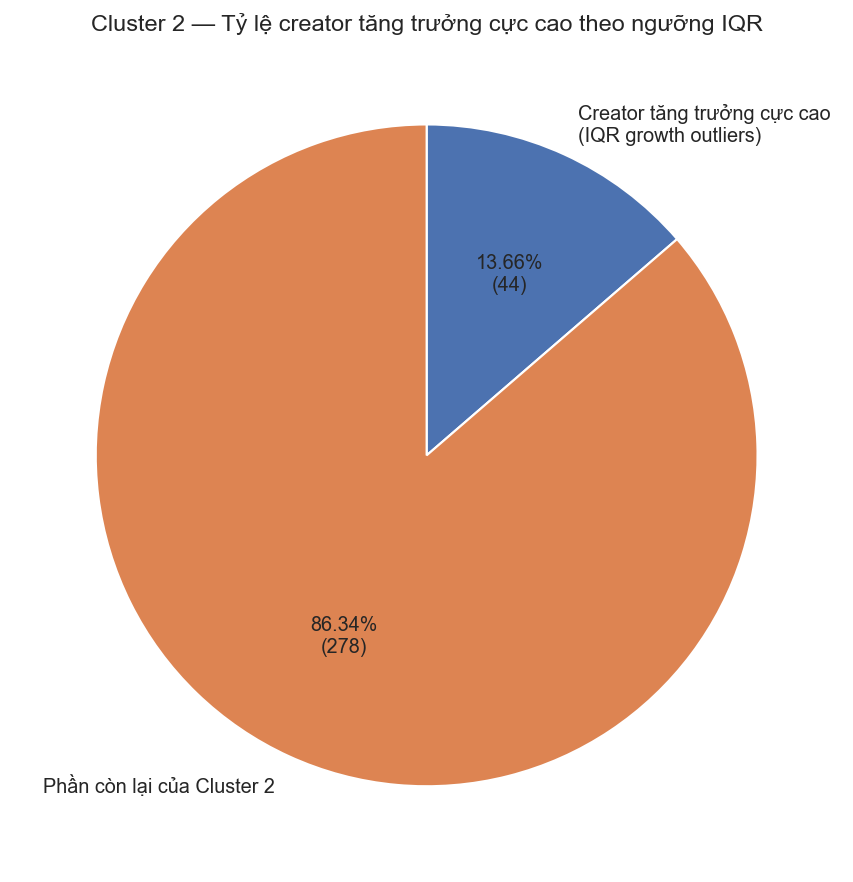

In [ ]:
# ================================================================
# PIE CHART — TỶ LỆ IQR OUTLIER VS PHẦN CÒN LẠI CỦA CLUSTER 2
# ================================================================

# Tạo dữ liệu cho biểu đồ tròn
pie_labels = [
    'Creator tăng trưởng cực cao\n(IQR growth outliers)',
    'Phần còn lại của Cluster 2'
]

pie_values = [
    len(c2_iqr_outlier),
    len(c2_non_outlier)
]

# Kiểm tra tổng số creator
total_c2 = sum(pie_values)

print("=" * 80)
print("TỶ LỆ CREATOR VƯỢT NGƯỠNG IQR TRONG CLUSTER 2")
print("=" * 80)
print(f"Số creator tăng trưởng cực cao : {len(c2_iqr_outlier):,}")
print(f"Số creator còn lại             : {len(c2_non_outlier):,}")
print(f"Tổng số creator Cluster 2      : {total_c2:,}")
print(f"Tỷ lệ outlier                  : {len(c2_iqr_outlier) / total_c2:.2%}")

# Vẽ biểu đồ tròn
plt.figure(figsize=(7, 7))

plt.pie(
    pie_values,
    labels=pie_labels,
    autopct=lambda pct: f'{pct:.2f}%\n({int(round(pct * total_c2 / 100)):,})',
    startangle=90,
    counterclock=False,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 11
    }
)

plt.title(
    'Cluster 2 — Tỷ lệ creator tăng trưởng cực cao theo ngưỡng IQR',
    fontsize=13,
    fontweight='500'
)

plt.tight_layout()
plt.show()

,content,content_label,outlier_pct,non_outlier_pct,diff_pct
0,Entertainment,Giải trí,0.8409,0.6835,0.1575
1,Food,Ẩm thực,0.0909,0.1511,-0.0602
2,Beauty,Beauty & Làm đẹp,0.0682,0.2122,-0.1440
3,Education,Giáo dục,0.0227,0.0036,0.0191
4,Sports,Thể thao,0.0227,0.0432,-0.0204


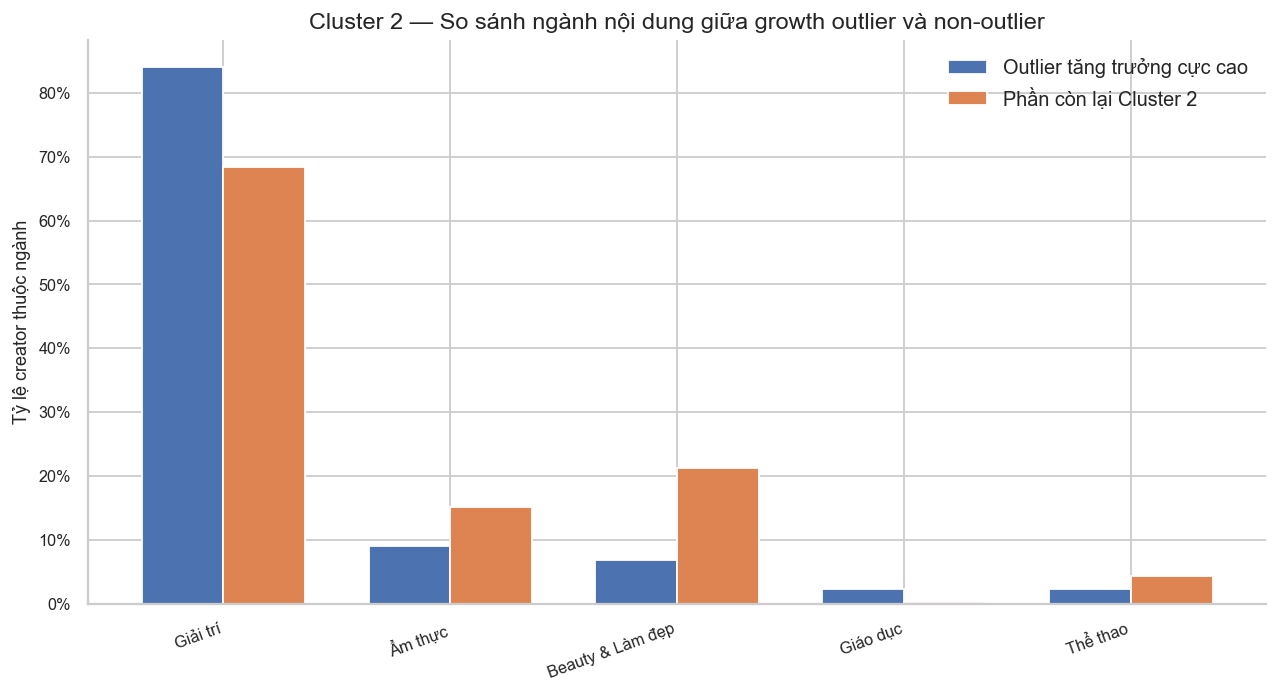

In [ ]:
# ================================================================
# INSIGHT — OUTLIER LÀM NGÀNH NÀO? SO VỚI NON-OUTLIER RA SAO?
# ================================================================


# Các cột ngành nội dung
CONTENT_COLS = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']

CONTENT_LABEL = {
    'Beauty':        'Beauty & Làm đẹp',
    'Education':     'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food':          'Ẩm thực',
    'Sports':        'Thể thao',
}

# Chỉ lấy những cột ngành thực sự tồn tại trong dữ liệu
content_cols = [c for c in CONTENT_COLS if c in c2.columns]

# Tính tỷ lệ creator thuộc từng ngành ở hai nhóm
outlier_rate = (
    c2_iqr_outlier[content_cols]
    .fillna(0)
    .mean()
)

non_outlier_rate = (
    c2_non_outlier[content_cols]
    .fillna(0)
    .mean()
)

# Tạo bảng so sánh
content_insight = pd.DataFrame({
    'content': content_cols,
    'content_label': [CONTENT_LABEL.get(c, c) for c in content_cols],
    'outlier_pct': outlier_rate.values,
    'non_outlier_pct': non_outlier_rate.values,
})

# Chênh lệch giữa outlier và non-outlier
content_insight['diff_pct'] = (
    content_insight['outlier_pct'] - content_insight['non_outlier_pct']
)

# Sắp xếp theo ngành có tỷ lệ cao nhất trong nhóm outlier
content_insight = content_insight.sort_values(
    'outlier_pct',
    ascending=False
).reset_index(drop=True)

display(content_insight.round(4))
# ================================================================
# BAR CHART — SO SÁNH TỶ LỆ NGÀNH: OUTLIER VS NON-OUTLIER
# ================================================================

x = np.arange(len(content_insight))
width = 0.36

plt.figure(figsize=(10, 5.5))

plt.bar(
    x - width / 2,
    content_insight['outlier_pct'],
    width=width,
    label='Outlier tăng trưởng cực cao'
)

plt.bar(
    x + width / 2,
    content_insight['non_outlier_pct'],
    width=width,
    label='Phần còn lại Cluster 2'
)

plt.xticks(
    x,
    content_insight['content_label'],
    rotation=20,
    ha='right'
)

plt.ylabel('Tỷ lệ creator thuộc ngành')
plt.title(
    'Cluster 2 — So sánh ngành nội dung giữa growth outlier và non-outlier',
    fontsize=13,
    fontweight='500'
)

plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


CLUSTER 2 — IQR OUTLIERS: PERFORMANCE & RECENT PERFORMANCE
iqr_group
Rest of Cluster 2      278
IQR growth outliers     44
Name: count, dtype: int64

Performance cols dùng được:
['followersGrowthRate', 'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate', 'medianViews', 'broadcastingScore', 'collaborationScore', 'commercialScore']

Performance recent cols dùng được:
['total_views_recent', 'total_hearts_recent', 'total_comments_recent', 'median_view_recent', 'max_view_recent', 'cov_view_recent', 'burstiness_recent', 'recency_days_recent']

Benchmark cols dùng được:
['avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews', 'engagementRateBenchMark']

BẢNG TÓM TẮT HIỆU SUẤT — IQR OUTLIERS VS REST


,iqr_group,n_creator,followersGrowthRate_mean,followersGrowthRate_median,avgSixSecondsViewsRate_mean,avgSixSecondsViewsRate_median,videoCompleteRate_mean,videoCompleteRate_median,engagementRate_mean,engagementRate_median,...,recency_days_recent_mean,recency_days_recent_median,viral_ratio_mean,viral_ratio_median,lift_median_views_mean,lift_median_views_median,lift_avg6s_views_mean,lift_avg6s_views_median,lift_engagement_mean,lift_engagement_median
0,IQR growth outliers,44,964.8294,0.2871,0.4406,0.3949,0.1583,0.1386,0.0671,0.0596,...,3.9579,1.5117,29.8982,10.2114,44.5168,6.8812,0.0391,-0.0910,0.4813,0.3487
1,Rest of Cluster 2,278,0.0197,0.0045,0.3813,0.4092,0.1209,0.1109,0.0563,0.0478,...,6.8964,2.5063,41.7724,8.1753,6.9046,1.6432,-0.1089,-0.0775,0.3425,0.1405


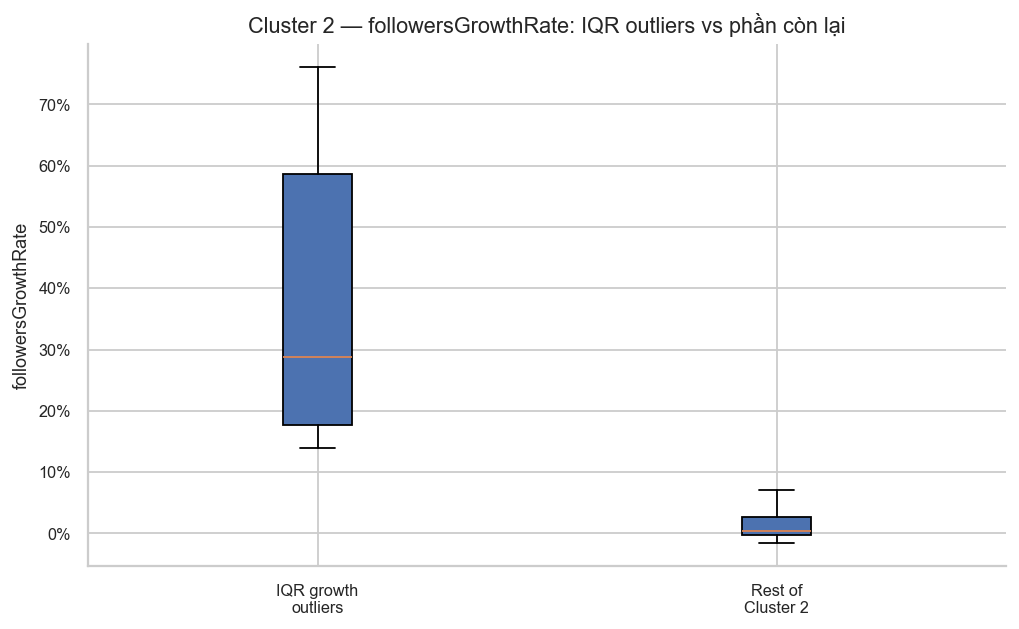

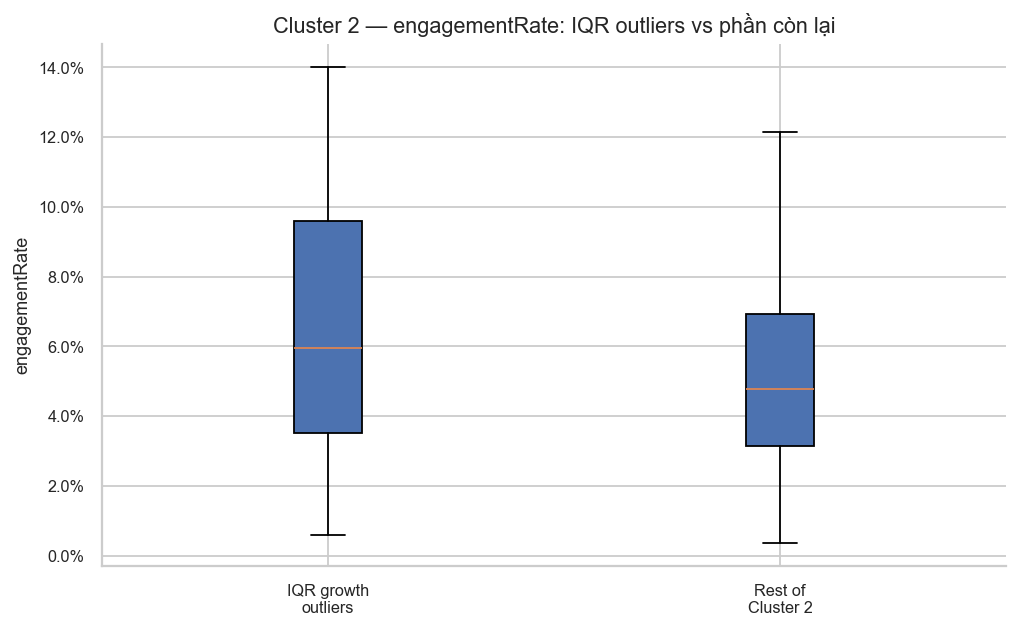

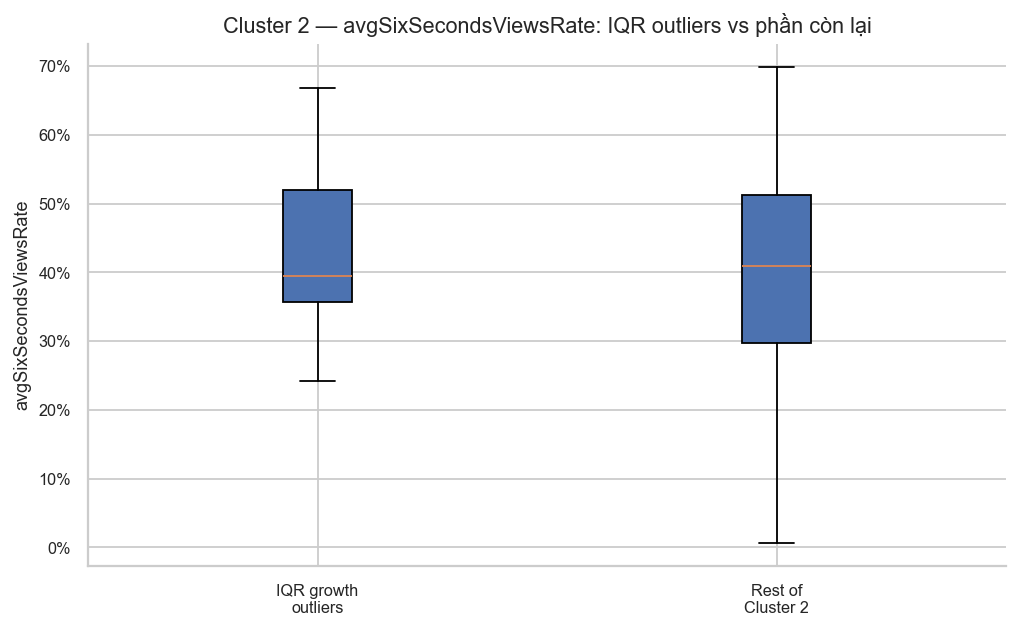

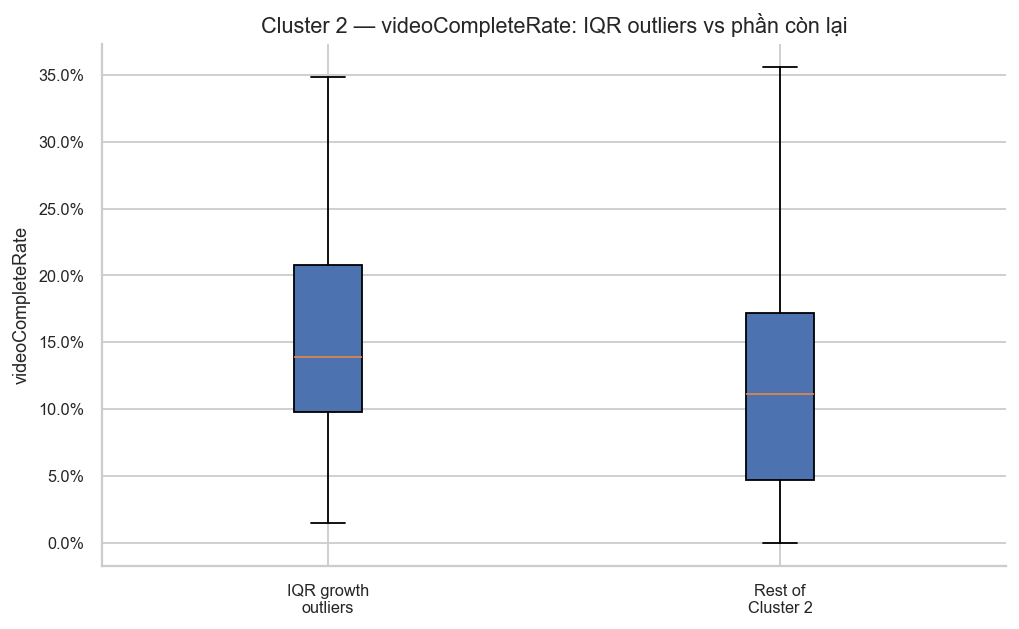

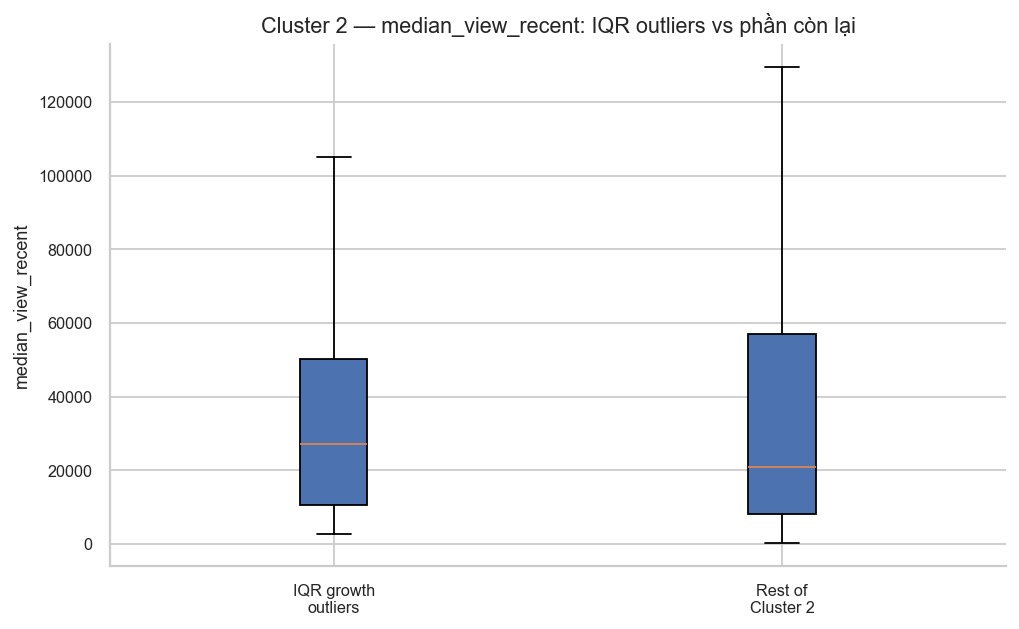

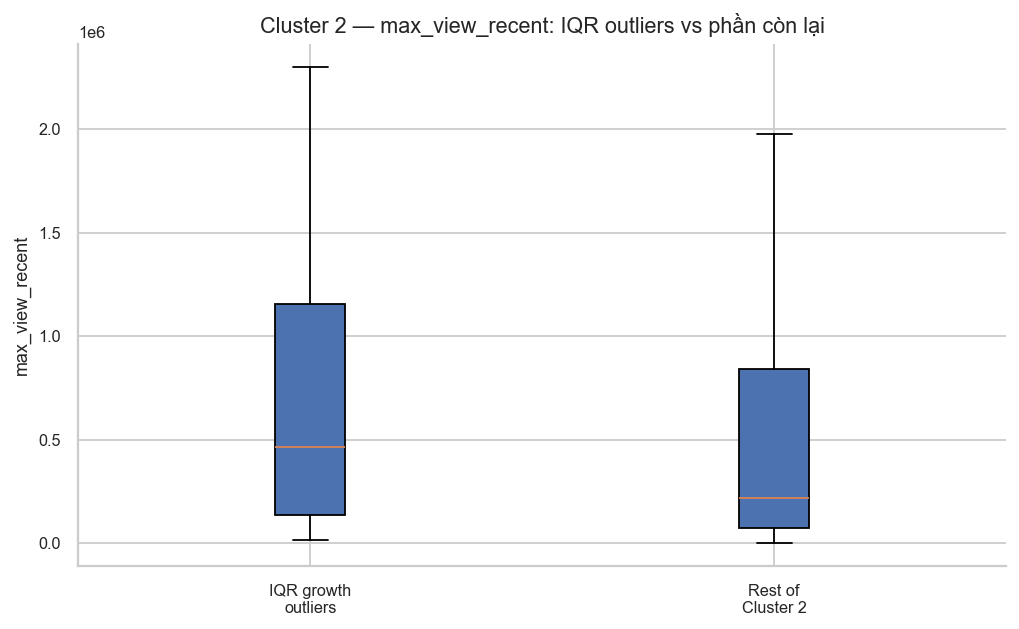

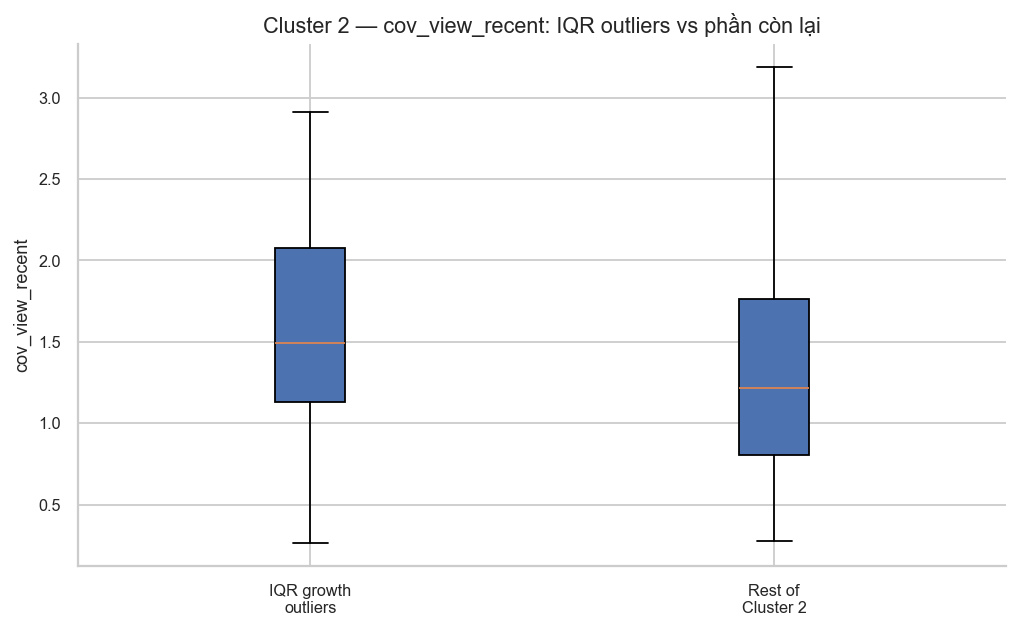

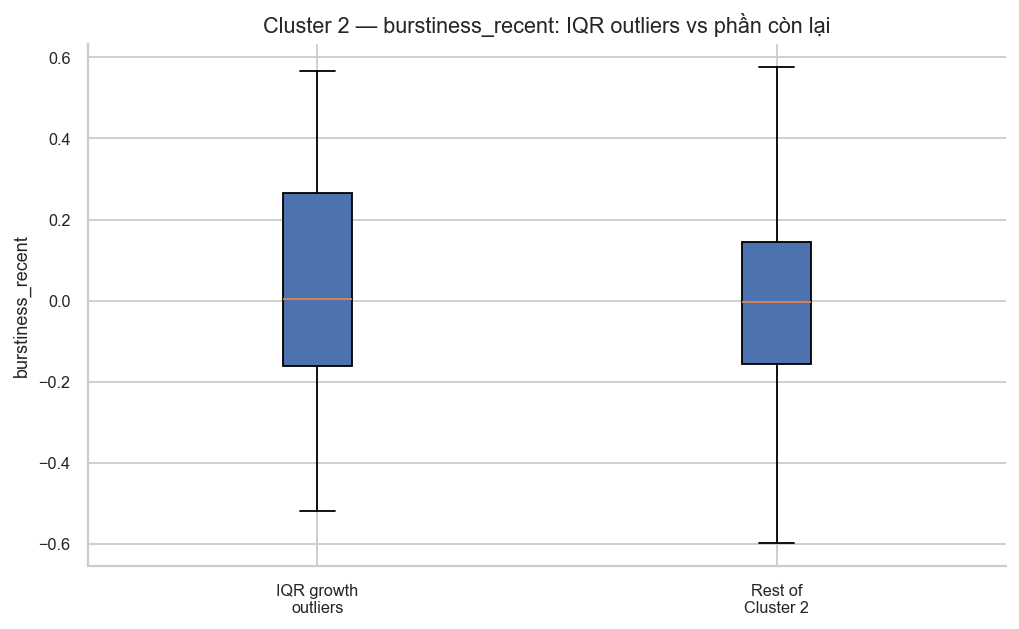

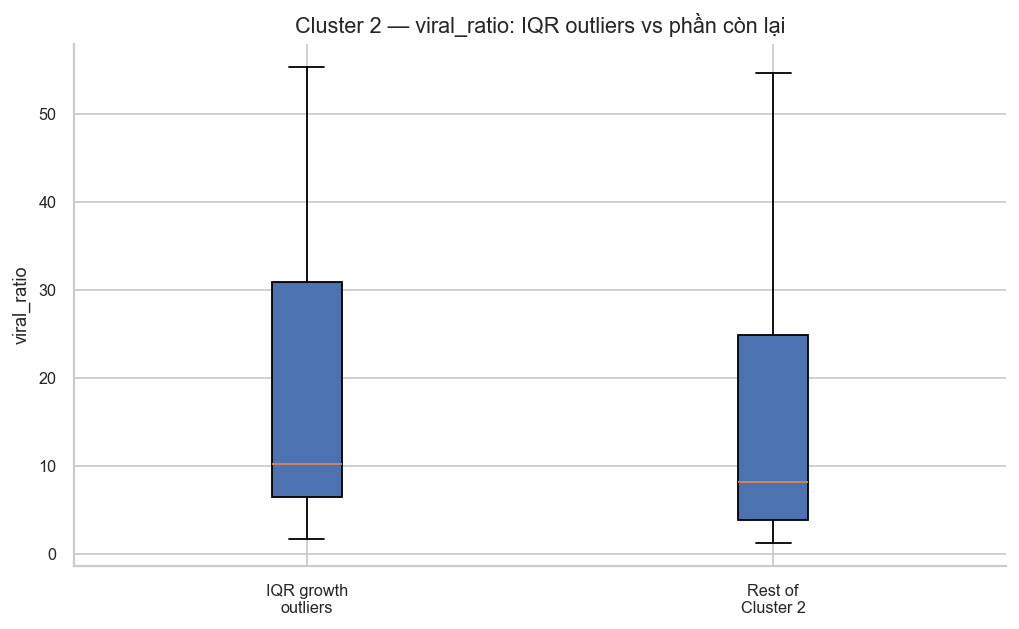

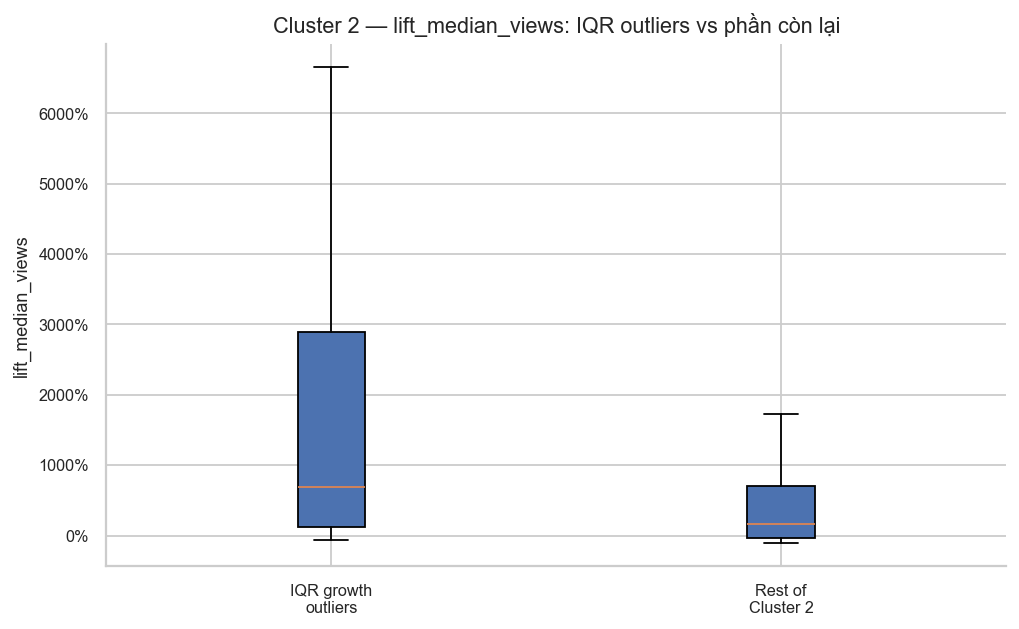

In [ ]:
# ================================================================
# CLUSTER 2 — IQR OUTLIERS: TRỰC QUAN HIỆU SUẤT & HIỆU SUẤT RECENT
# Chạy cell này sau cell tìm c2_iqr_outlier và c2_non_outlier
# Mục tiêu:
# - So sánh performance tổng thể giữa IQR outliers và phần còn lại
# - So sánh performance recent từ 15 video gần nhất
# - Kiểm tra nhóm outlier mạnh ở tăng trưởng thật, view gần đây, hay chỉ spike
# ================================================================


# ================================================================
# 0. KIỂM TRA BIẾN TỪ CELL TRƯỚC
# ================================================================

required_objects = ['c2_iqr_outlier', 'c2_non_outlier']

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Chưa có biến `{obj}`. Hãy chạy cell phân tích IQR outlier trước cell này."
        )

# Gộp 2 nhóm để trực quan
perf_compare_df = pd.concat([
    c2_iqr_outlier.assign(iqr_group='IQR growth outliers'),
    c2_non_outlier.assign(iqr_group='Rest of Cluster 2')
], axis=0).copy()

print("=" * 80)
print("CLUSTER 2 — IQR OUTLIERS: PERFORMANCE & RECENT PERFORMANCE")
print("=" * 80)
print(perf_compare_df['iqr_group'].value_counts())


# ================================================================
# 1. ĐỊNH NGHĨA CỘT
# ================================================================

performance_cols = [
    'followersGrowthRate',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'engagementRate',
    'medianViews',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore'
]

performance_recent_cols = [
    'total_views_recent',
    'total_hearts_recent',
    'total_comments_recent',
    'median_view_recent',
    'max_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'recency_days_recent'
]

benchmark_cols = [
    'avgSixSecondsViewsBenchMarkViews',
    'medianBenchMarkViews',
    'engagementRateBenchMark'
]

performance_cols = [c for c in performance_cols if c in perf_compare_df.columns]
performance_recent_cols = [c for c in performance_recent_cols if c in perf_compare_df.columns]
benchmark_cols = [c for c in benchmark_cols if c in perf_compare_df.columns]

print("\nPerformance cols dùng được:")
print(performance_cols)

print("\nPerformance recent cols dùng được:")
print(performance_recent_cols)

print("\nBenchmark cols dùng được:")
print(benchmark_cols)


# ================================================================
# 2. TẠO THÊM BIẾN LIFT / VIRAL RATIO NẾU CHƯA CÓ
# ================================================================

def safe_divide(a, b, eps=1e-9):
    return a / (b + eps)

if {'max_view_recent', 'median_view_recent'}.issubset(perf_compare_df.columns):
    perf_compare_df['viral_ratio'] = safe_divide(
        perf_compare_df['max_view_recent'],
        perf_compare_df['median_view_recent']
    )

if {'median_view_recent', 'medianBenchMarkViews'}.issubset(perf_compare_df.columns):
    perf_compare_df['lift_median_views'] = safe_divide(
        perf_compare_df['median_view_recent'] - perf_compare_df['medianBenchMarkViews'],
        perf_compare_df['medianBenchMarkViews']
    )

if {'avgSixSecondsViewsRate', 'avgSixSecondsViewsBenchMarkViews'}.issubset(perf_compare_df.columns):
    perf_compare_df['lift_avg6s_views'] = safe_divide(
        perf_compare_df['avgSixSecondsViewsRate'] - perf_compare_df['avgSixSecondsViewsBenchMarkViews'],
        perf_compare_df['avgSixSecondsViewsBenchMarkViews']
    )

if {'engagementRate', 'engagementRateBenchMark'}.issubset(perf_compare_df.columns):
    perf_compare_df['lift_engagement'] = safe_divide(
        perf_compare_df['engagementRate'] - perf_compare_df['engagementRateBenchMark'],
        perf_compare_df['engagementRateBenchMark']
    )

derived_cols = [
    c for c in [
        'viral_ratio',
        'lift_median_views',
        'lift_avg6s_views',
        'lift_engagement'
    ]
    if c in perf_compare_df.columns
]


# ================================================================
# 3. BẢNG SUMMARY: MEAN & MEDIAN THEO NHÓM
# ================================================================

summary_cols = performance_cols + performance_recent_cols + derived_cols

summary_rows = []

for group_name, sub in perf_compare_df.groupby('iqr_group'):
    row = {
        'iqr_group': group_name,
        'n_creator': len(sub)
    }

    for col in summary_cols:
        row[f'{col}_mean'] = pd.to_numeric(sub[col], errors='coerce').mean()
        row[f'{col}_median'] = pd.to_numeric(sub[col], errors='coerce').median()

    summary_rows.append(row)

perf_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("BẢNG TÓM TẮT HIỆU SUẤT — IQR OUTLIERS VS REST")
print("=" * 80)
display(perf_summary.round(4))


# # ================================================================
# # 4. BAR CHART: MEDIAN PERFORMANCE TỔNG THỂ
# # ================================================================

# median_perf = (
#     perf_compare_df
#     .groupby('iqr_group')[performance_cols]
#     .median(numeric_only=True)
#     .T
# )

# if not median_perf.empty:
#     ax = median_perf.plot(
#         kind='bar',
#         figsize=(13, 5.5),
#         width=0.75
#     )

#     plt.title(
#         'Cluster 2 — Median performance: IQR growth outliers vs phần còn lại',
#         fontsize=13,
#         fontweight='500'
#     )
#     plt.xlabel('Performance metrics')
#     plt.ylabel('Median value')
#     plt.xticks(rotation=25, ha='right')
#     plt.legend(title='', frameon=False)
#     plt.tight_layout()
#     plt.show()


# # ================================================================
# # 5. BAR CHART: MEDIAN PERFORMANCE RECENT
# # ================================================================

# median_recent = (
#     perf_compare_df
#     .groupby('iqr_group')[performance_recent_cols]
#     .median(numeric_only=True)
#     .T
# )

# if not median_recent.empty:
#     ax = median_recent.plot(
#         kind='bar',
#         figsize=(13, 5.5),
#         width=0.75
#     )

#     plt.title(
#         'Cluster 2 — Median recent performance: IQR growth outliers vs phần còn lại',
#         fontsize=13,
#         fontweight='500'
#     )
#     plt.xlabel('Recent performance metrics')
#     plt.ylabel('Median value')
#     plt.xticks(rotation=25, ha='right')
#     plt.legend(title='', frameon=False)
#     plt.tight_layout()
#     plt.show()


# ================================================================
# 6. BOX PLOT: CÁC CHỈ SỐ QUAN TRỌNG
# ================================================================

box_cols = [
    'followersGrowthRate',
    'engagementRate',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'median_view_recent',
    'max_view_recent',
    'cov_view_recent',
    'burstiness_recent',
    'viral_ratio',
    'lift_median_views'
]

box_cols = [c for c in box_cols if c in perf_compare_df.columns]

for col in box_cols:
    plt.figure(figsize=(8, 5))

    data_to_plot = [
        perf_compare_df.loc[
            perf_compare_df['iqr_group'] == 'IQR growth outliers',
            col
        ].replace([np.inf, -np.inf], np.nan).dropna(),

        perf_compare_df.loc[
            perf_compare_df['iqr_group'] == 'Rest of Cluster 2',
            col
        ].replace([np.inf, -np.inf], np.nan).dropna()
    ]

    plt.boxplot(
        data_to_plot,
        labels=['IQR growth\noutliers', 'Rest of\nCluster 2'],
        showfliers=False,
        patch_artist=True
    )

    plt.title(f'Cluster 2 — {col}: IQR outliers vs phần còn lại', fontsize=12, fontweight='500')
    plt.ylabel(col)

    if col in ['followersGrowthRate', 'engagementRate', 'avgSixSecondsViewsRate',
               'videoCompleteRate', 'lift_median_views', 'lift_avg6s_views',
               'lift_engagement']:
        plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    plt.tight_layout()
    plt.show()




CLUSTER 3 — High-Engagement Micro-Niche
Số creator trong Cluster 3: 13
Tỷ lệ trong toàn bộ dữ liệu: 0.26%

MEDIAN PROFILE THEO CỤM


,cluster_kmeans,cluster_name,n_creator,pct_creator,followerCnt,followersGrowthRate,engagementRate,broadcastingScore,medianViews,median_view_recent,commercialScore,collaborationScore
0,0,Commercial Mature Leaders,788,0.1548,231061.5,0.0000,0.0297,87.5,41724.5,43961.0,91.2,84.4
1,1,Mainstream Creator Base,3966,0.7793,150237.0,0.0046,0.0462,88.2,36908.0,36293.5,60.0,75.2
2,2,Breakout Segment,322,0.0633,238740.5,0.0102,0.0500,88.9,23255.0,21904.0,60.0,76.8
3,3,High-Engagement Micro-Niche,13,0.0026,97263.0,0.0137,0.0698,91.2,17322.0,19262.0,60.0,75.2


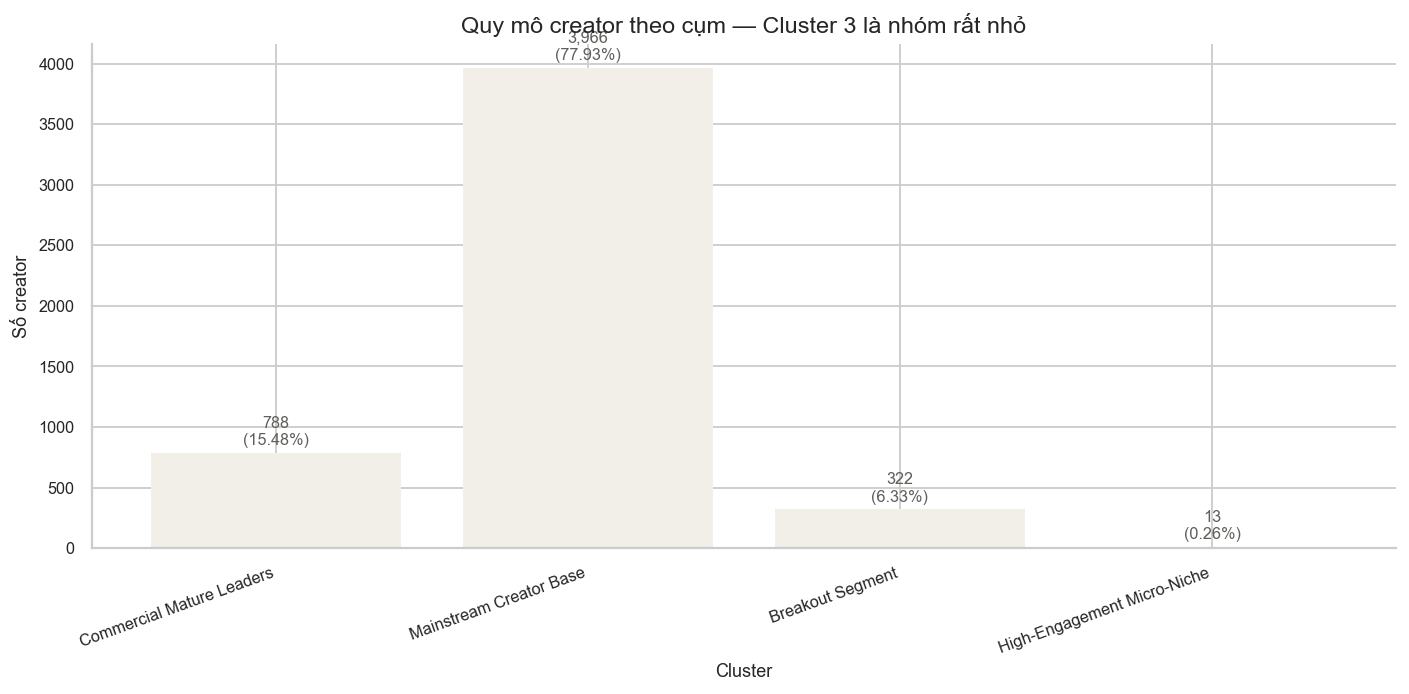

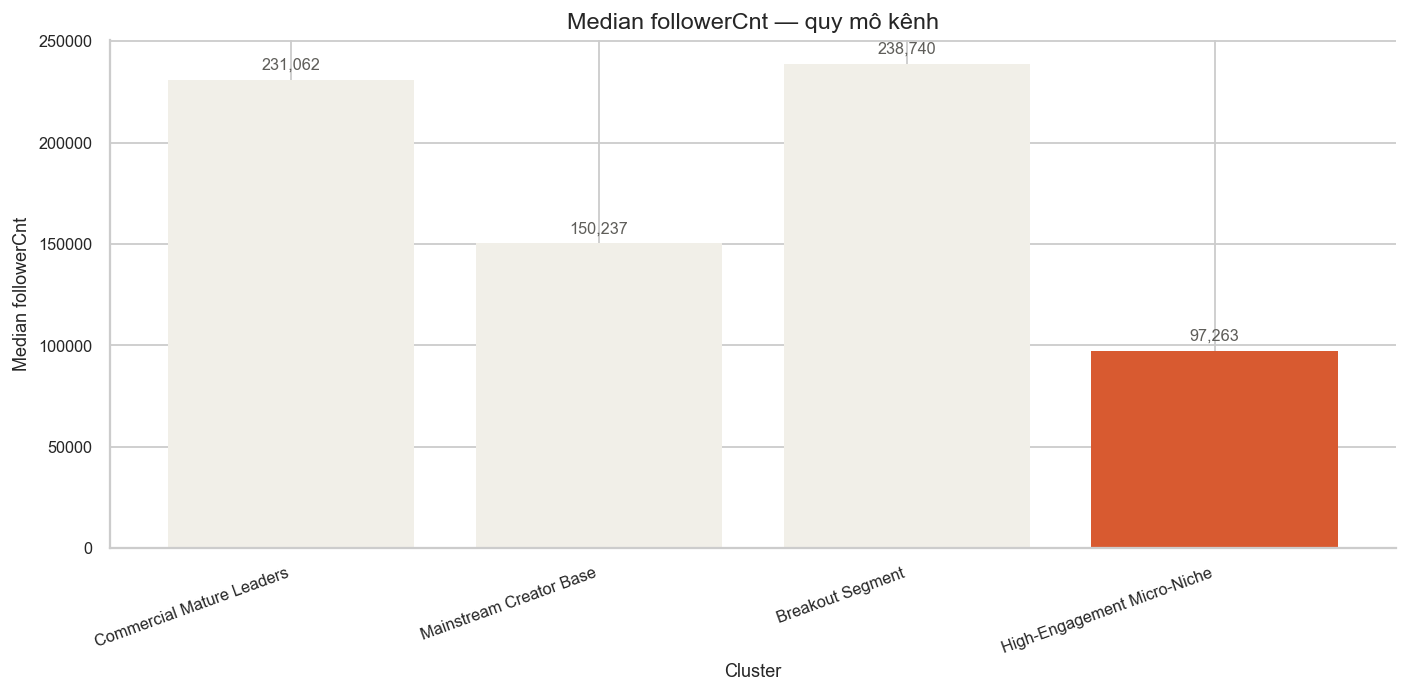

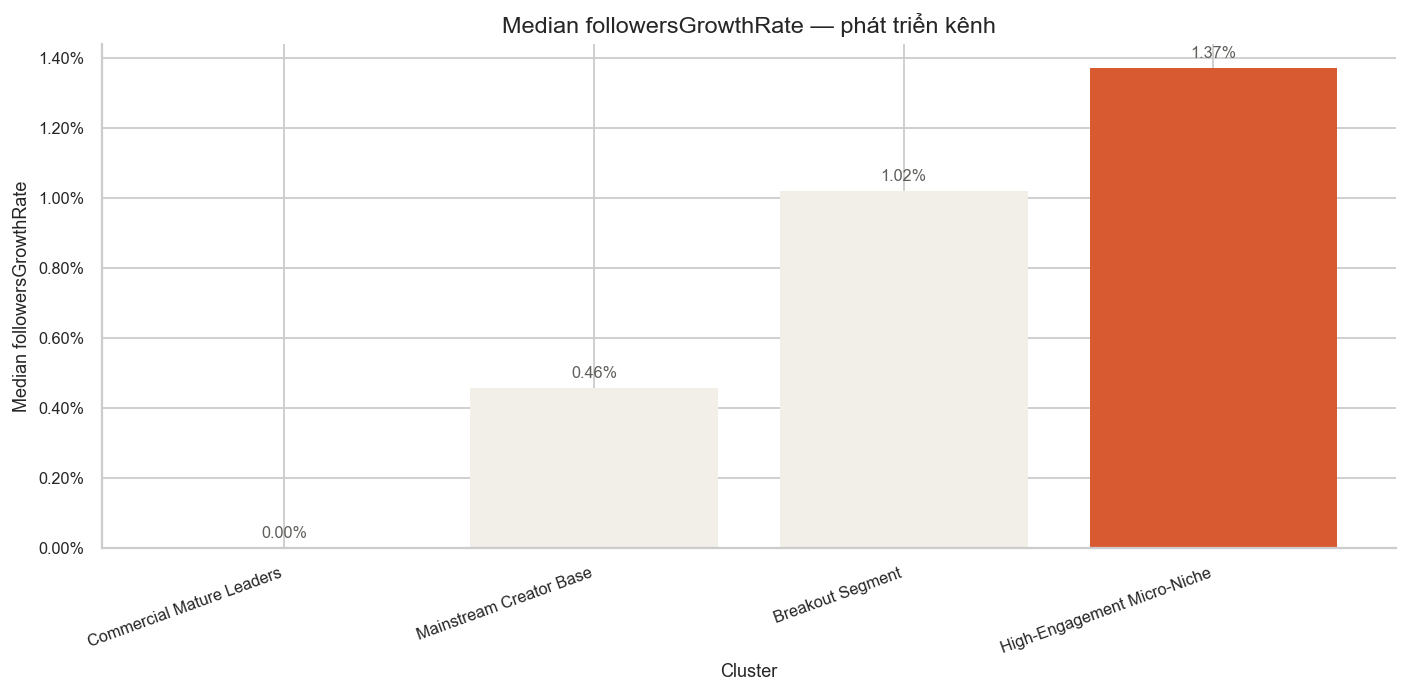

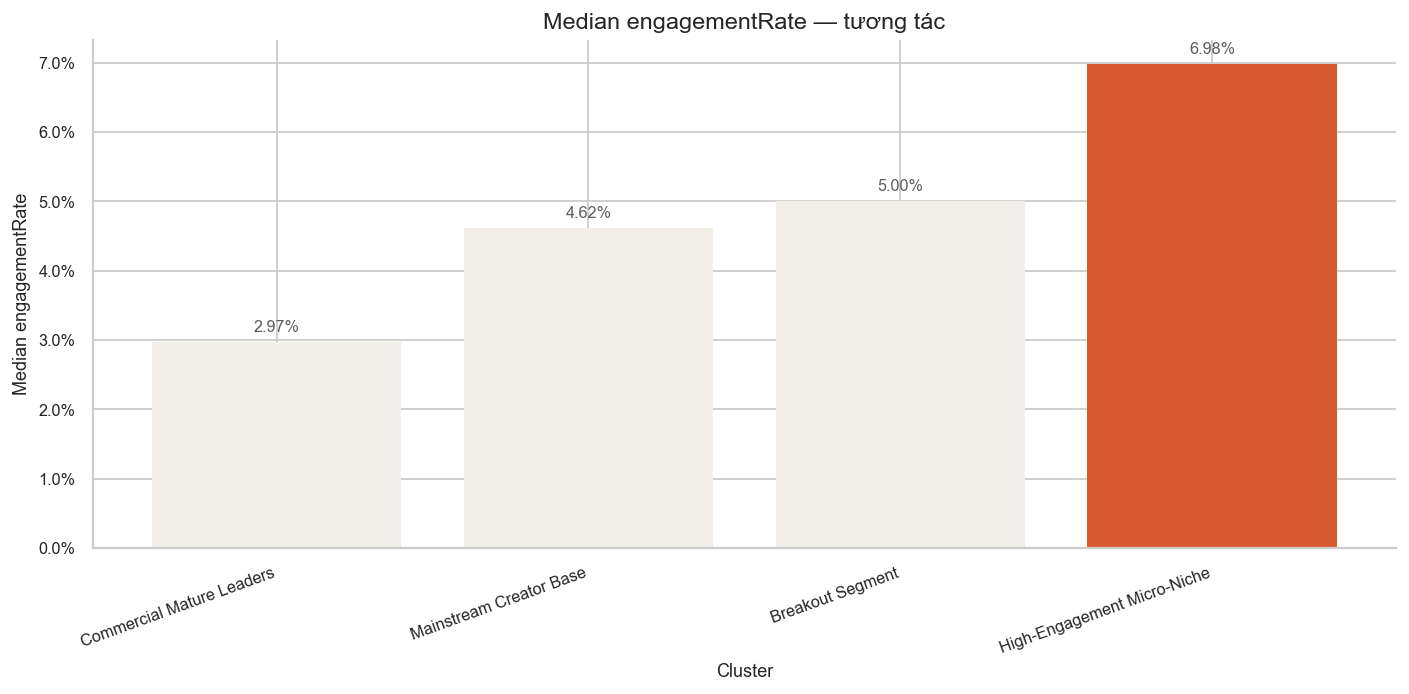

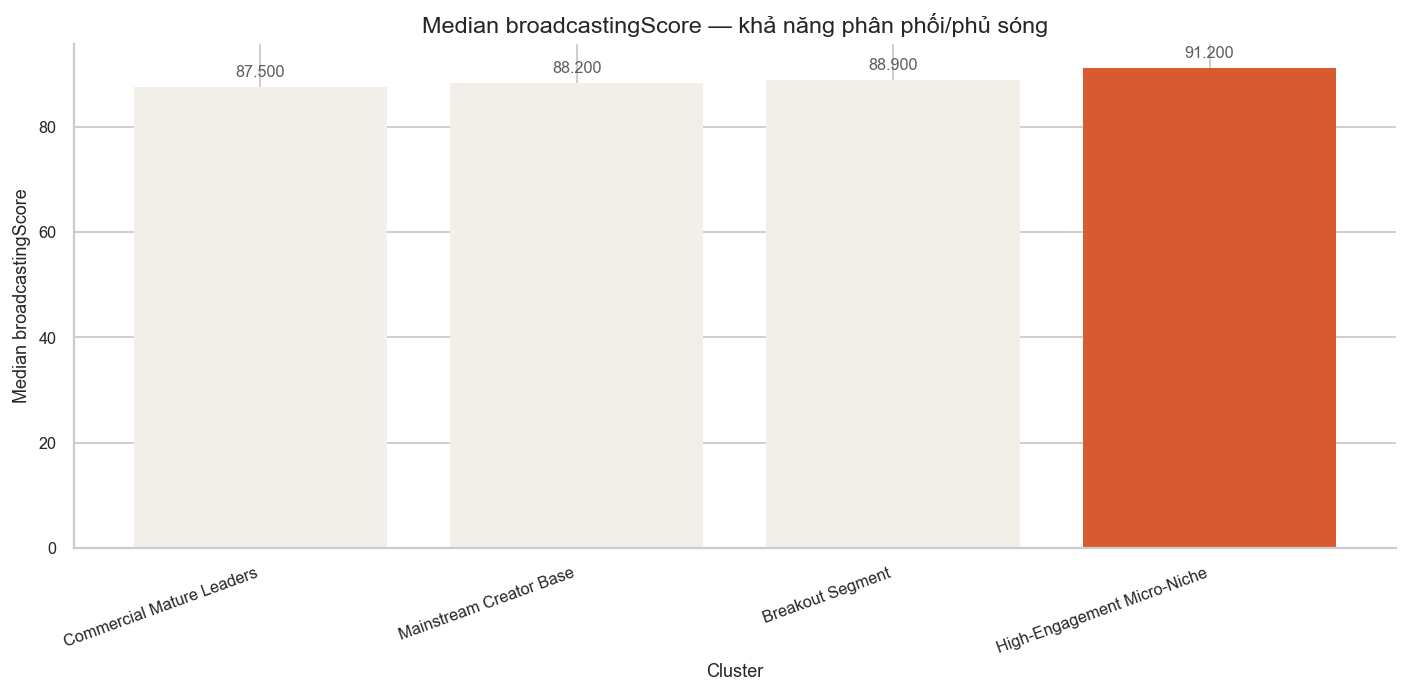

In [ ]:
# ================================================================
# CLUSTER 3 — HIGH-ENGAGEMENT MICRO-NICHE: DEEP DIVE
# Mục tiêu:
# - Quy mô nhỏ so với các cụm khác
# - Growth tốt khi so bằng median
# - Engagement tốt khi so bằng median
# - BroadcastingScore tốt
# - Làm rõ luận điểm: nhỏ nhưng có chất lượng tương tác và phân phối tốt
# ================================================================



# ================================================================
# 0. CONFIG
# ================================================================

cluster_col = 'cluster_kmeans'
target_cluster = 3
target_cluster_name = 'High-Engagement Micro-Niche'

df = df.copy()

cluster_name_map = {
    0: 'Commercial Mature Leaders',
    1: 'Mainstream Creator Base',
    2: 'Breakout Segment',
    3: 'High-Engagement Micro-Niche'
}

df['cluster_name'] = df[cluster_col].map(cluster_name_map).fillna(df[cluster_col].astype(str))

c3 = df[df[cluster_col] == target_cluster].copy()

print("=" * 80)
print(f"CLUSTER {target_cluster} — {target_cluster_name}")
print("=" * 80)
print(f"Số creator trong Cluster 3: {len(c3):,}")
print(f"Tỷ lệ trong toàn bộ dữ liệu: {len(c3) / len(df):.2%}")

CLR = {
    'purple':       '#534AB7',
    'purple_mid':   '#7F77DD',
    'purple_light': '#EEEDFE',
    'coral':        '#D85A30',
    'coral_light':  '#FAECE7',
    'amber':        '#BA7517',
    'amber_light':  '#FAEEDA',
    'teal':         '#1D9E75',
    'teal_light':   '#E1F5EE',
    'blue':         '#185FA5',
    'blue_light':   '#E6F1FB',
    'green':        '#3B6D11',
    'green_light':  '#EAF3DE',
    'gray':         '#B4B2A9',
    'gray_dark':    '#5F5E5A',
    'gray_light':   '#F1EFE8',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})


# ================================================================
# 1. TÓM TẮT MEDIAN THEO CỤM
# ================================================================

focus_cols = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore',
    'medianViews',
    'median_view_recent',
    'commercialScore',
    'collaborationScore'
]

focus_cols = [c for c in focus_cols if c in df.columns]

cluster_median_profile = (
    df.groupby([cluster_col, 'cluster_name'])[focus_cols]
      .median()
      .reset_index()
      .sort_values(cluster_col)
)

cluster_mean_profile = (
    df.groupby([cluster_col, 'cluster_name'])[focus_cols]
      .mean()
      .reset_index()
      .sort_values(cluster_col)
)

cluster_size = (
    df.groupby([cluster_col, 'cluster_name'])
      .size()
      .reset_index(name='n_creator')
      .sort_values(cluster_col)
)

cluster_size['pct_creator'] = cluster_size['n_creator'] / len(df)

cluster_profile = cluster_size.merge(
    cluster_median_profile,
    on=[cluster_col, 'cluster_name'],
    how='left'
)

print("\n" + "=" * 80)
print("MEDIAN PROFILE THEO CỤM")
print("=" * 80)
display(cluster_profile.round(4))


# ================================================================
# 2. BAR CHART — QUY MÔ CỤM
# ================================================================

plt.figure(figsize=(11, 5.5))

colors = [
    CLR['gray_light'] if cl != target_cluster else CLR['coral']
    for cl in cluster_size[cluster_col]
]

bars = plt.bar(
    cluster_size['cluster_name'],
    cluster_size['n_creator'],
    color=colors,
    edgecolor='none'
)

plt.title(
    'Quy mô creator theo cụm — Cluster 3 là nhóm rất nhỏ',
    fontsize=13,
    fontweight='500'
)

plt.xlabel('Cluster')
plt.ylabel('Số creator')
plt.xticks(rotation=20, ha='right')

for bar, pct in zip(bars, cluster_size['pct_creator']):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + cluster_size['n_creator'].max() * 0.01,
        f'{int(h):,}\n({pct:.2%})',
        ha='center',
        va='bottom',
        fontsize=9,
        color=CLR['gray_dark']
    )

plt.tight_layout()
plt.show()


# ================================================================
# 3. SO SÁNH MEDIAN: FOLLOWER SIZE, GROWTH, ENGAGEMENT, BROADCASTING
# ================================================================

compare_metrics = [
    'followerCnt',
    'followersGrowthRate',
    'engagementRate',
    'broadcastingScore'
]

compare_metrics = [c for c in compare_metrics if c in df.columns]

metric_title = {
    'followerCnt': 'Median followerCnt — quy mô kênh',
    'followersGrowthRate': 'Median followersGrowthRate — phát triển kênh',
    'engagementRate': 'Median engagementRate — tương tác',
    'broadcastingScore': 'Median broadcastingScore — khả năng phân phối/phủ sóng'
}

metric_ylabel = {
    'followerCnt': 'Median followerCnt',
    'followersGrowthRate': 'Median followersGrowthRate',
    'engagementRate': 'Median engagementRate',
    'broadcastingScore': 'Median broadcastingScore'
}

for metric in compare_metrics:
    tmp = (
        df.groupby([cluster_col, 'cluster_name'])[metric]
          .median()
          .reset_index()
          .sort_values(cluster_col)
    )

    plt.figure(figsize=(11, 5.5))

    colors = [
        CLR['gray_light'] if cl != target_cluster else CLR['coral']
        for cl in tmp[cluster_col]
    ]

    bars = plt.bar(
        tmp['cluster_name'],
        tmp[metric],
        color=colors,
        edgecolor='none'
    )

    plt.title(
        metric_title.get(metric, f'Median {metric} theo cụm'),
        fontsize=13,
        fontweight='500'
    )

    plt.xlabel('Cluster')
    plt.ylabel(metric_ylabel.get(metric, metric))
    plt.xticks(rotation=20, ha='right')

    if metric in ['followersGrowthRate', 'engagementRate']:
        plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    for bar in bars:
        value = bar.get_height()

        if metric in ['followersGrowthRate', 'engagementRate']:
            label = f'{value:.2%}'
        elif metric == 'followerCnt':
            label = f'{value:,.0f}'
        else:
            label = f'{value:.3f}'

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + tmp[metric].max() * 0.015,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
            color=CLR['gray_dark']
        )

    plt.tight_layout()
    plt.show()


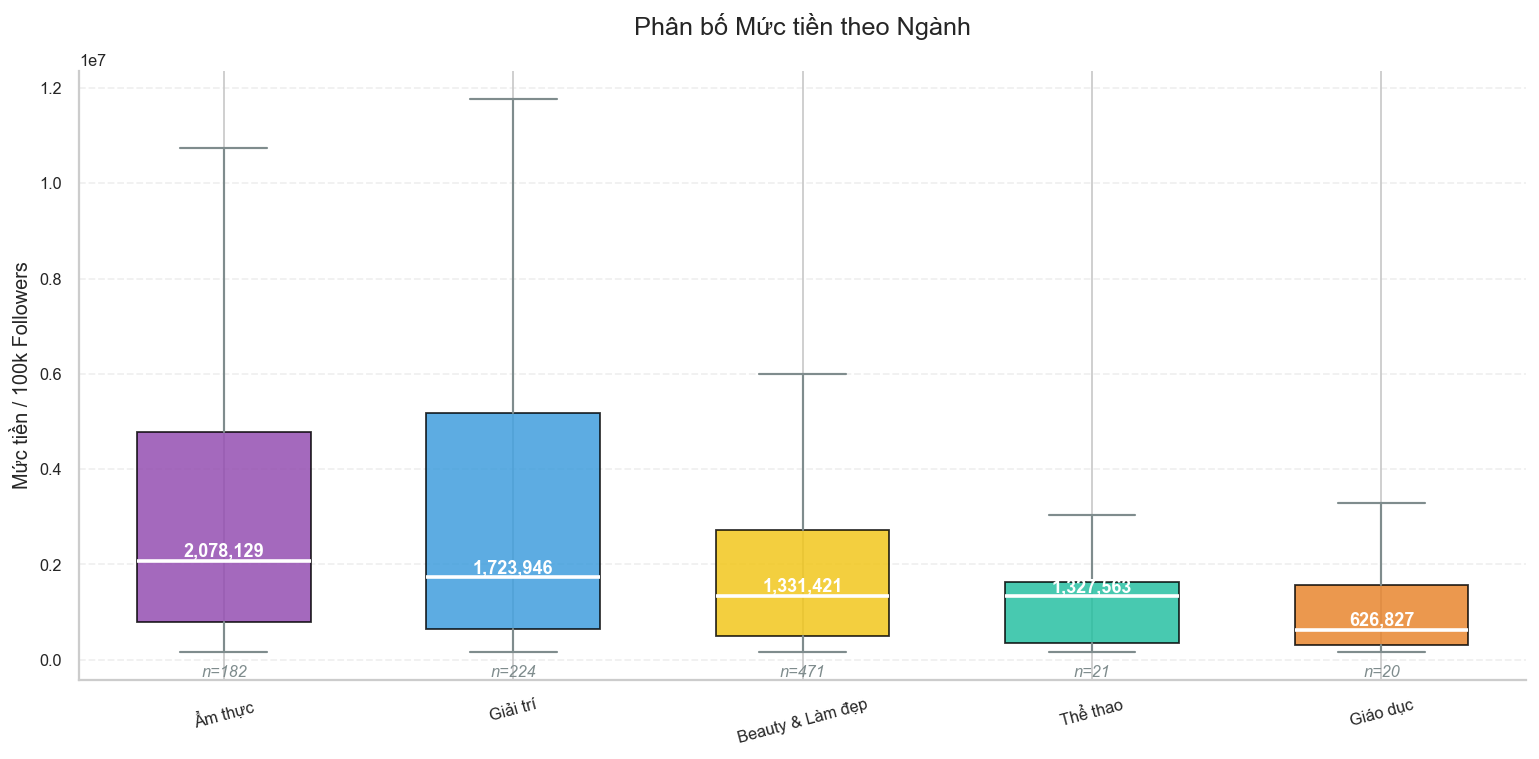

In [ ]:


# 1. Tiền xử lý dữ liệu (giữ nguyên logic chuẩn hóa của bạn)
c0_recommend = c0[c0['recommendRate100k'] > 0].copy()
c0_recommend['recommendRate100k'] = c0_recommend['recommendRate100k'] / 100000

CONTENT_COLS  = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
CONTENT_LABEL = {
    'Beauty': 'Beauty & Làm đẹp',
    'Education': 'Giáo dục',
    'Entertainment': 'Giải trí',
    'Food': 'Ẩm thực',
    'Sports': 'Thể thao',
}

# 2. Gom dữ liệu theo ngành (xử lý đa ngành)
data_boxes = []
box_labels = []
box_n = []

for col in CONTENT_COLS:
    if col in c0_recommend.columns:
        mask = c0_recommend[col].fillna(0) == 1
        subset = c0_recommend.loc[mask, 'recommendRate100k'].dropna().values
        if len(subset) > 0:
            data_boxes.append(subset)
            box_labels.append(CONTENT_LABEL.get(col, col))
            box_n.append(len(subset))

# 3. Sắp xếp theo Median giảm dần
order = sorted(range(len(data_boxes)), key=lambda i: np.median(data_boxes[i]), reverse=True)
data_boxes = [data_boxes[i] for i in order]
box_labels = [box_labels[i] for i in order]
box_n = [box_n[i] for i in order]

# Định nghĩa màu sắc (đảm bảo CLR đã được bạn định nghĩa trước đó)
# Nếu chưa có CLR, bạn có thể thay bằng các mã màu hex trực tiếp
colors = ['#8E44AD', '#3498DB', '#F1C40F', '#1ABC9C', '#E67E22'] 

# 4. Vẽ biểu đồ Boxplot
plt.figure(figsize=(12, 6))

bp = plt.boxplot(
    data_boxes,
    labels=box_labels,
    patch_artist=True,
    showfliers=False,  # Ẩn outlier để biểu đồ tập trung vào các mức giá phổ biến
    widths=0.6,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#7F8C8D', linewidth=1.2),
    capprops=dict(color='#7F8C8D', linewidth=1.2)
)

# Áp dụng màu sắc cho từng box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# 5. Hiển thị giá trị Median và số lượng mẫu (n) lên biểu đồ
ax = plt.gca()
for i, (data, n) in enumerate(zip(data_boxes, box_n)):
    med = np.median(data)
    # Hiển thị số tiền trung vị ngay trên đường median
    plt.text(i + 1, med, f'{med:,.0f}', ha='center', va='bottom', 
             fontweight='bold', color='white', fontsize=10)
    # Hiển thị cỡ mẫu n ở phía dưới
    plt.text(i + 1, ax.get_ylim()[0], f'n={n}', ha='center', va='bottom', 
             color='#7F8C8D', fontsize=9, style='italic')

# Định dạng trục và tiêu đề
plt.title('Phân bố Mức tiền theo Ngành', fontsize=14, pad=20)
plt.ylabel('Mức tiền / 100k Followers', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()